# Phyloseq analysis
- repeat 2.2Phyloseq.ipynb at order level
- reran bracken at O level- see 2.0Taxa-Kraken script

In [1]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [2]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload Data

In [3]:
LEVEL="O"
setwd(paste0("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/",LEVEL))

### Taxonomy 

In [4]:
LEVEL="O"
taxa = read.csv(paste0('otu_id_',LEVEL,'.csv'),header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,135623,Vibrionales,O
2,135619,Oceanospirillales,O
3,91347,Enterobacterales,O
4,135622,Alteromonadales,O
5,72274,Pseudomonadales,O
6,2887326,Moraxellales,O


In [5]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","order")

In [6]:
head(taxa)

,otuid,order
,<int>,<chr>
1,135623,Vibrionales
2,135619,Oceanospirillales
3,91347,Enterobacterales
4,135622,Alteromonadales
5,72274,Pseudomonadales
6,2887326,Moraxellales


In [7]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,order
,<chr>
135623,Vibrionales
135619,Oceanospirillales
91347,Enterobacterales
135622,Alteromonadales
72274,Pseudomonadales
2887326,Moraxellales


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:380, 1] "Vibrionales" "Oceanospirillales" "Enterobacterales" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:380] "135623" "135619" "91347" "135622" ...
  ..$ : chr "order"


#### OTU Raw

In [9]:
#read in raw otu table
otu_raw = read.csv(paste0("otu_table_",LEVEL,".csv"),header=TRUE)
# remove prefix and suffixes from sampleIDs
 
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), paste0(".kreport2_",LEVEL,".bracken_num"), "")
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), "X", "")

In [10]:
head(otu_raw)

,taxonomy_id,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,135623,40618,23213,11748,1618,1987,4350,4381,6956,4567,⋯,5665,4116,5487,4738,14100,5276,18601,6408,4401,13434
2,135619,29438,13499,11080,1249,6152,7729,4657,9118,5881,⋯,24896,11212,23303,14841,57532,24023,52042,10399,2556,7146
3,91347,29381,21114,17783,7758,7647,27023,14894,8183,4092,⋯,18801,11129,21519,14431,45413,22577,59189,88577,33020,31388
4,135622,13874,13302,4593,2348,2197,6677,29125,3505,1829,⋯,8307,3713,17986,10842,18431,9599,40612,1635,566,3221
5,72274,8297,5661,9718,3293,4225,20114,5157,3851,3112,⋯,5600,4447,20559,8302,15291,10057,18282,135287,32196,262682
6,2887326,7419,5779,3023,1814,6579,5502,3750,1822,944,⋯,6430,2891,6211,3744,13094,5914,16292,1363,353,27039


In [11]:
# rename first col as otu
names(otu_raw)[1] <- "otu"

# make the index the otus
row.names(otu_raw) <- otu_raw$otu
otu_raw$otu <- NULL

# sort by most abundant OTUs
otu_raw_sorted <- otu_raw[order(rowSums(otu_raw), decreasing = TRUE), ]

# Convert to matrix
otus_raw=as.matrix(otu_raw_sorted)
head(otus_raw)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
356,16666,9958,300189,53187,40995,77925,9067,107368,66403,2935,⋯,20577,36895,693870,33698,43957,715477,22490,14588675,3954714,584922
204455,16032,4011,12064,1275,608,40669,3794,5279,957,610,⋯,1733,1079,8767,1922,4223,4656,4879,74444,18175,36842
85009,1408,1132,13892,1378,7103,7430,1099,1027,1728,337,⋯,774,3024,124196,1128,1853,12186,3591,54151,35470,6744718
85011,10724,7534,12840,4624,1933,37108,8161,4587,2630,3943,⋯,7475,6154,12517,8244,16652,11795,19406,153562,34765,29200
80840,10156,7453,19561,4718,2762,32517,6255,5581,2082,2722,⋯,7183,4915,17442,6802,16092,15886,18561,321483,79420,149169
1385,51070,35021,22914,14105,6667,23399,16241,12171,5952,12362,⋯,42233,19697,45662,26056,98228,39716,125456,10408,4086,330579


In [12]:
# look what most abundant is 
indices<-c("374", "1912216", "1883","445219","286")
taxa[indices,]
# cutibacterium is human skin microbe but the rest seem ok

[1] NA NA NA NA NA

### Metadata

In [13]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/O"

In [14]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [15]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [16]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [17]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [18]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony_filtered<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony_filtered<-colony_filtered %>%
    filter(colony_id %in% colony_list)

In [19]:
# merge sample and colony data 
sample_colony=merge(metadata, colony_filtered, by="colony_id")

In [20]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [21]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [22]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [23]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

# reset all PASTs to resistant
sample_colony<-sample_colony %>%
    mutate(RS = if_else(Species == "PAST", "Resistant",RS))

In [24]:
table(sample_colony$RS)


  Resistant Susceptible 
        125          92 

In [25]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [26]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [27]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [28]:
# classify phyloseq objects 
OTU=otu_table((otus_raw), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

In [29]:
# Create raw phyloseq object
sctld_raw<-phyloseq(OTU, SAMP, TAX)
sctld_raw

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 380 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 380 taxa by 1 taxonomic ranks ]

In [30]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [31]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [32]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [33]:
# and remove human skin microbes - cutibacterium acnes
keep <- as.vector(tax_table(sctld_raw2)[, "order"] != "Cutibacterium")
sctld_raw2 <- prune_taxa(keep, sctld_raw2)
sctld_raw <- prune_taxa(keep, sctld_raw)

### Diversity

In [34]:
sctld_raw2.ord <- ordinate(sctld_raw2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1158948 
Run 1 stress 0.1214856 
Run 2 stress 0.1158954 
... Procrustes: rmse 0.0002648924  max resid 0.003024555 
... Similar to previous best
Run 3 stress 0.1175491 
Run 4 stress 0.1158948 
... New best solution
... Procrustes: rmse 2.09207e-05  max resid 0.000180762 
... Similar to previous best
Run 5 stress 0.1158948 
... Procrustes: rmse 1.286192e-05  max resid 8.833308e-05 
... Similar to previous best
Run 6 stress 0.1199027 
Run 7 stress 0.1158974 
... Procrustes: rmse 0.0002256928  max resid 0.003177657 
... Similar to previous best
Run 8 stress 0.1158948 
... New best solution
... Procrustes: rmse 8.963864e-06  max resid 9.280987e-05 
... Similar to previous best
Run 9 stress 0.1175458 
Run 10 stress 0.1196722 
Run 11 stress 0.1182958 
Run 12 stress 0.1182982 
Run 13 stress 0.1158948 
... Procrustes: rmse 5.848181e-06  max resid 5.517442e-05 
... Similar to previous best
Run 14 stress 0.1182968 
Run 15 

In [35]:
library(paletteer)

In [36]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [37]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [38]:
# names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(metadata$Species)

In [39]:
# coral_colors
custom_list

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

In [40]:
options(repr.plot.width=15, repr.plot.height=10)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


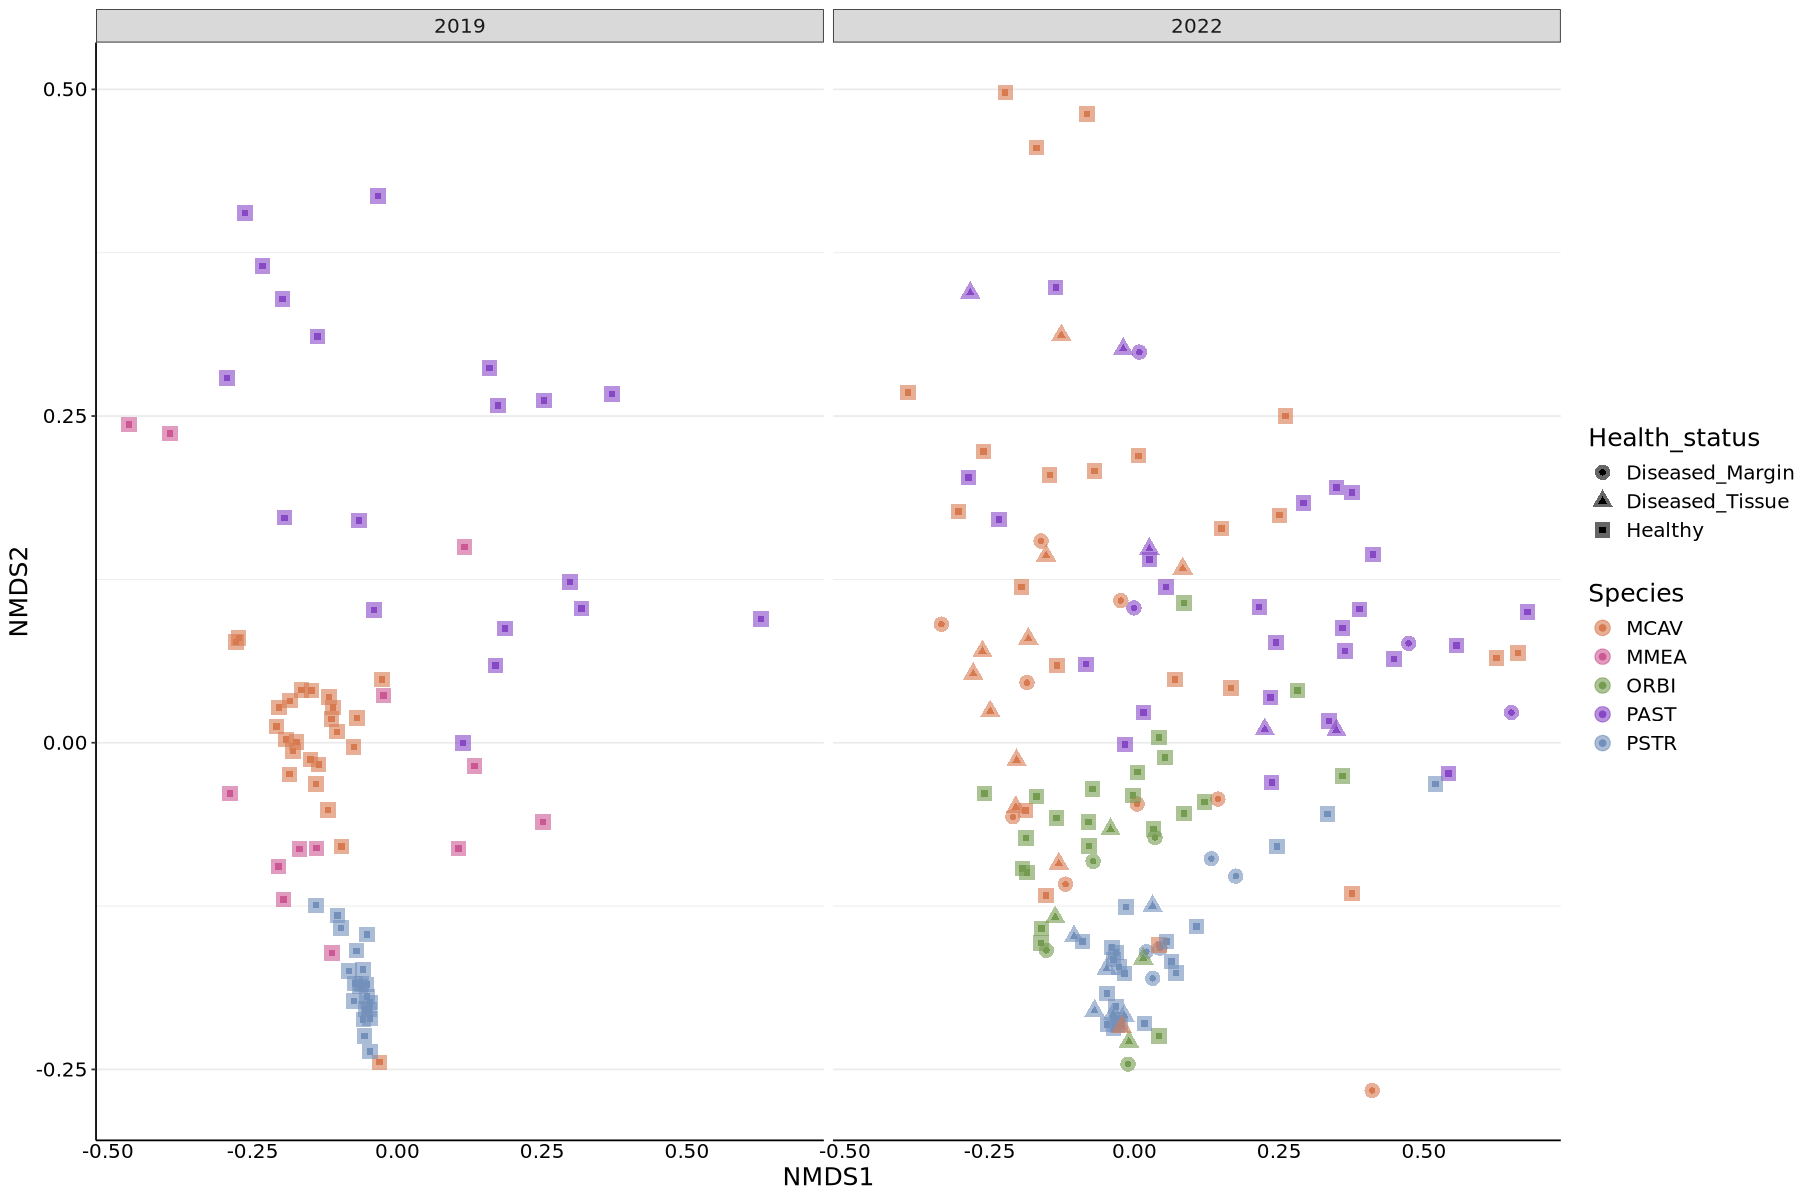

In [41]:
# facet by year
sctld_raw_plot <- plot_ordination(sctld_raw2, sctld_raw2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [42]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.11803 
Run 1 stress 0.1197951 
Run 2 stress 0.1191159 
Run 3 stress 0.1193031 
Run 4 stress 0.1180851 
... Procrustes: rmse 0.002340722  max resid 0.01399063 
Run 5 stress 0.1206105 
Run 6 stress 0.119796 
Run 7 stress 0.1183112 
... Procrustes: rmse 0.01168215  max resid 0.05010029 
Run 8 stress 0.11803 
... New best solution
... Procrustes: rmse 5.607349e-06  max resid 3.367555e-05 
... Similar to previous best
Run 9 stress 0.1962448 
Run 10 stress 0.1183112 
... Procrustes: rmse 0.01168515  max resid 0.05010873 
Run 11 stress 0.1738995 
Run 12 stress 0.1180957 
... Procrustes: rmse 0.001837681  max resid 0.01370319 
Run 13 stress 0.1573181 
Run 14 stress 0.1183113 
... Procrustes: rmse 0.01168228  max resid 0.05009876 
Run 15 stress 0.2060941 
Run 16 stress 0.1182973 
... Procrustes: rmse 0.01106939  max resid 0.04938659 
Run 17 stress 0.1192123 
Run 18 stress 0.1182901 
... Procrustes: rmse 0.01115325  max r

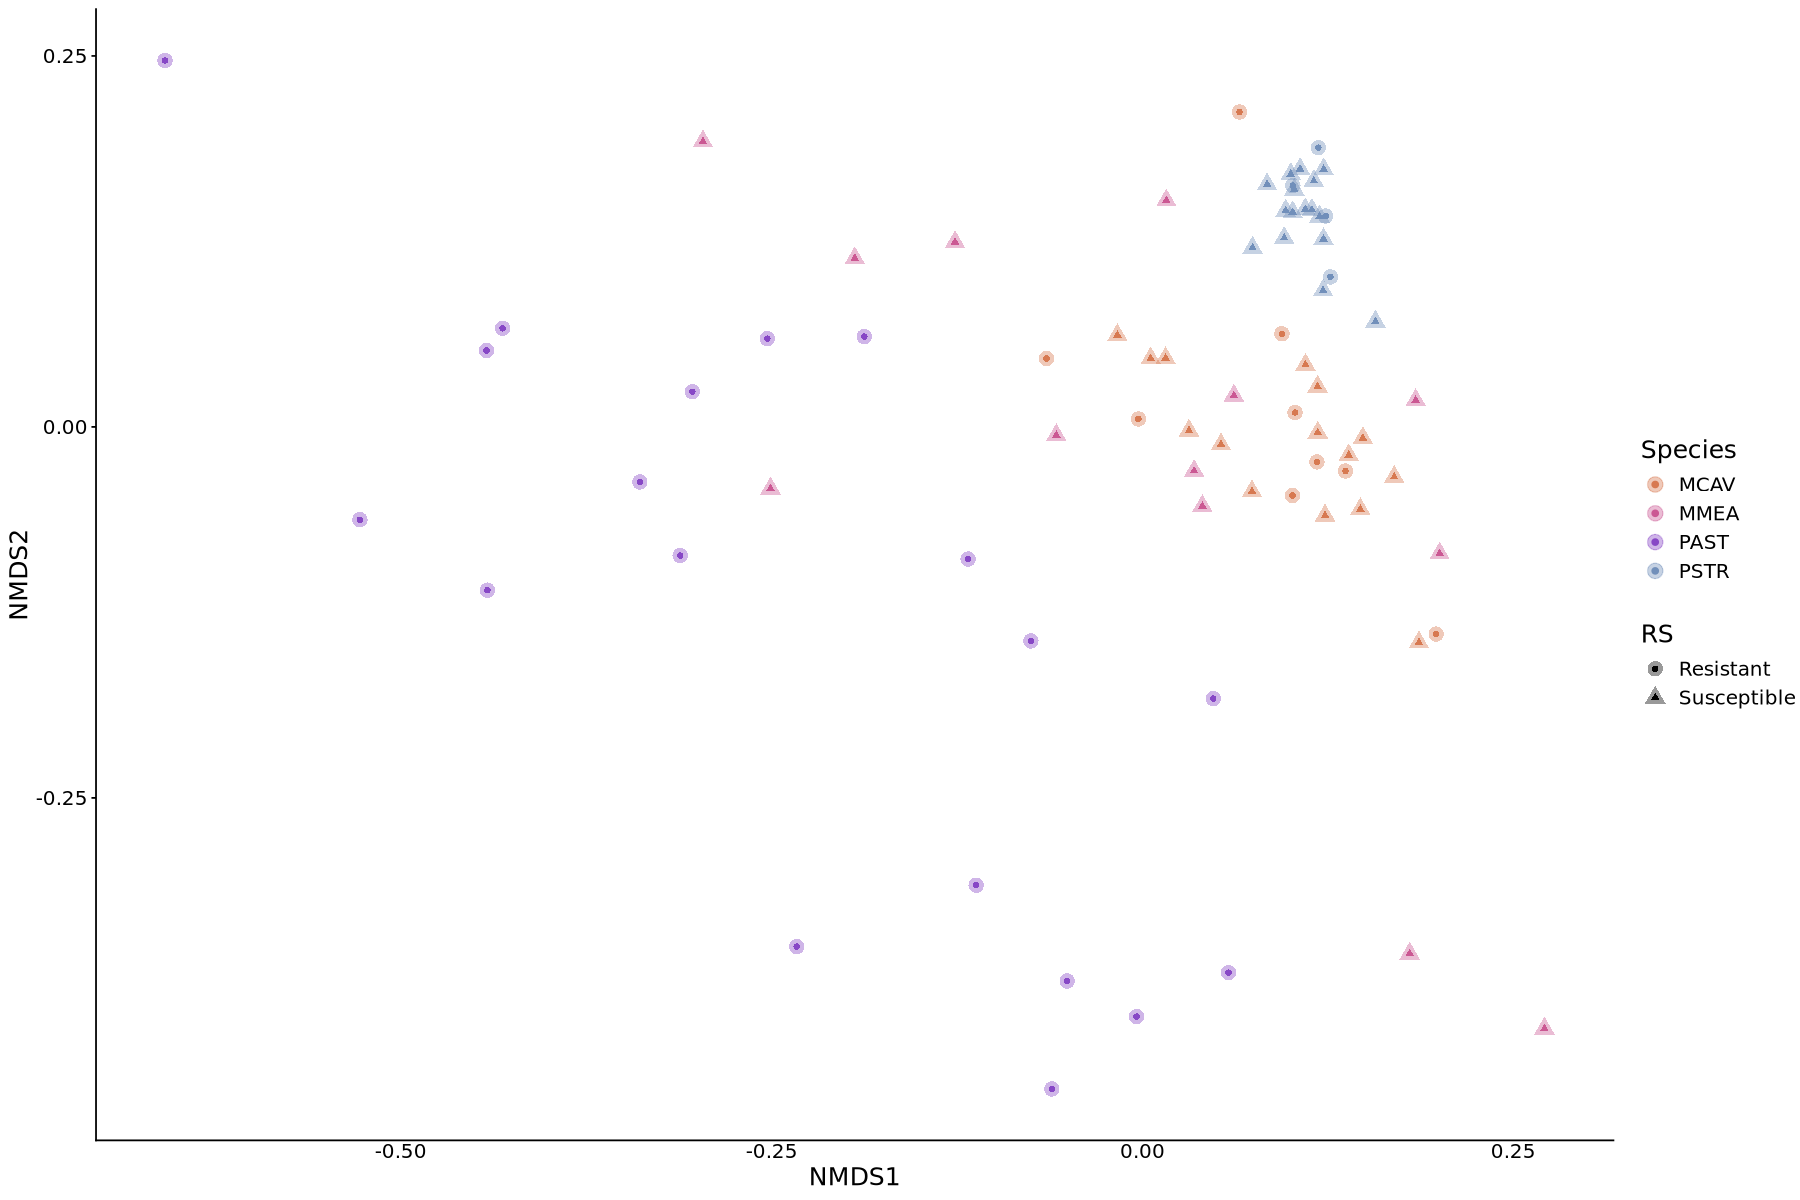

In [43]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [44]:
# ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [45]:
RS.ord
# Stress: 0.108


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.11803 
Stress type 1, weak ties
Best solution was repeated 1 time in 20 tries
The best solution was from try 8 (random start)
Scaling: centring, PC rotation, halfchange scaling 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


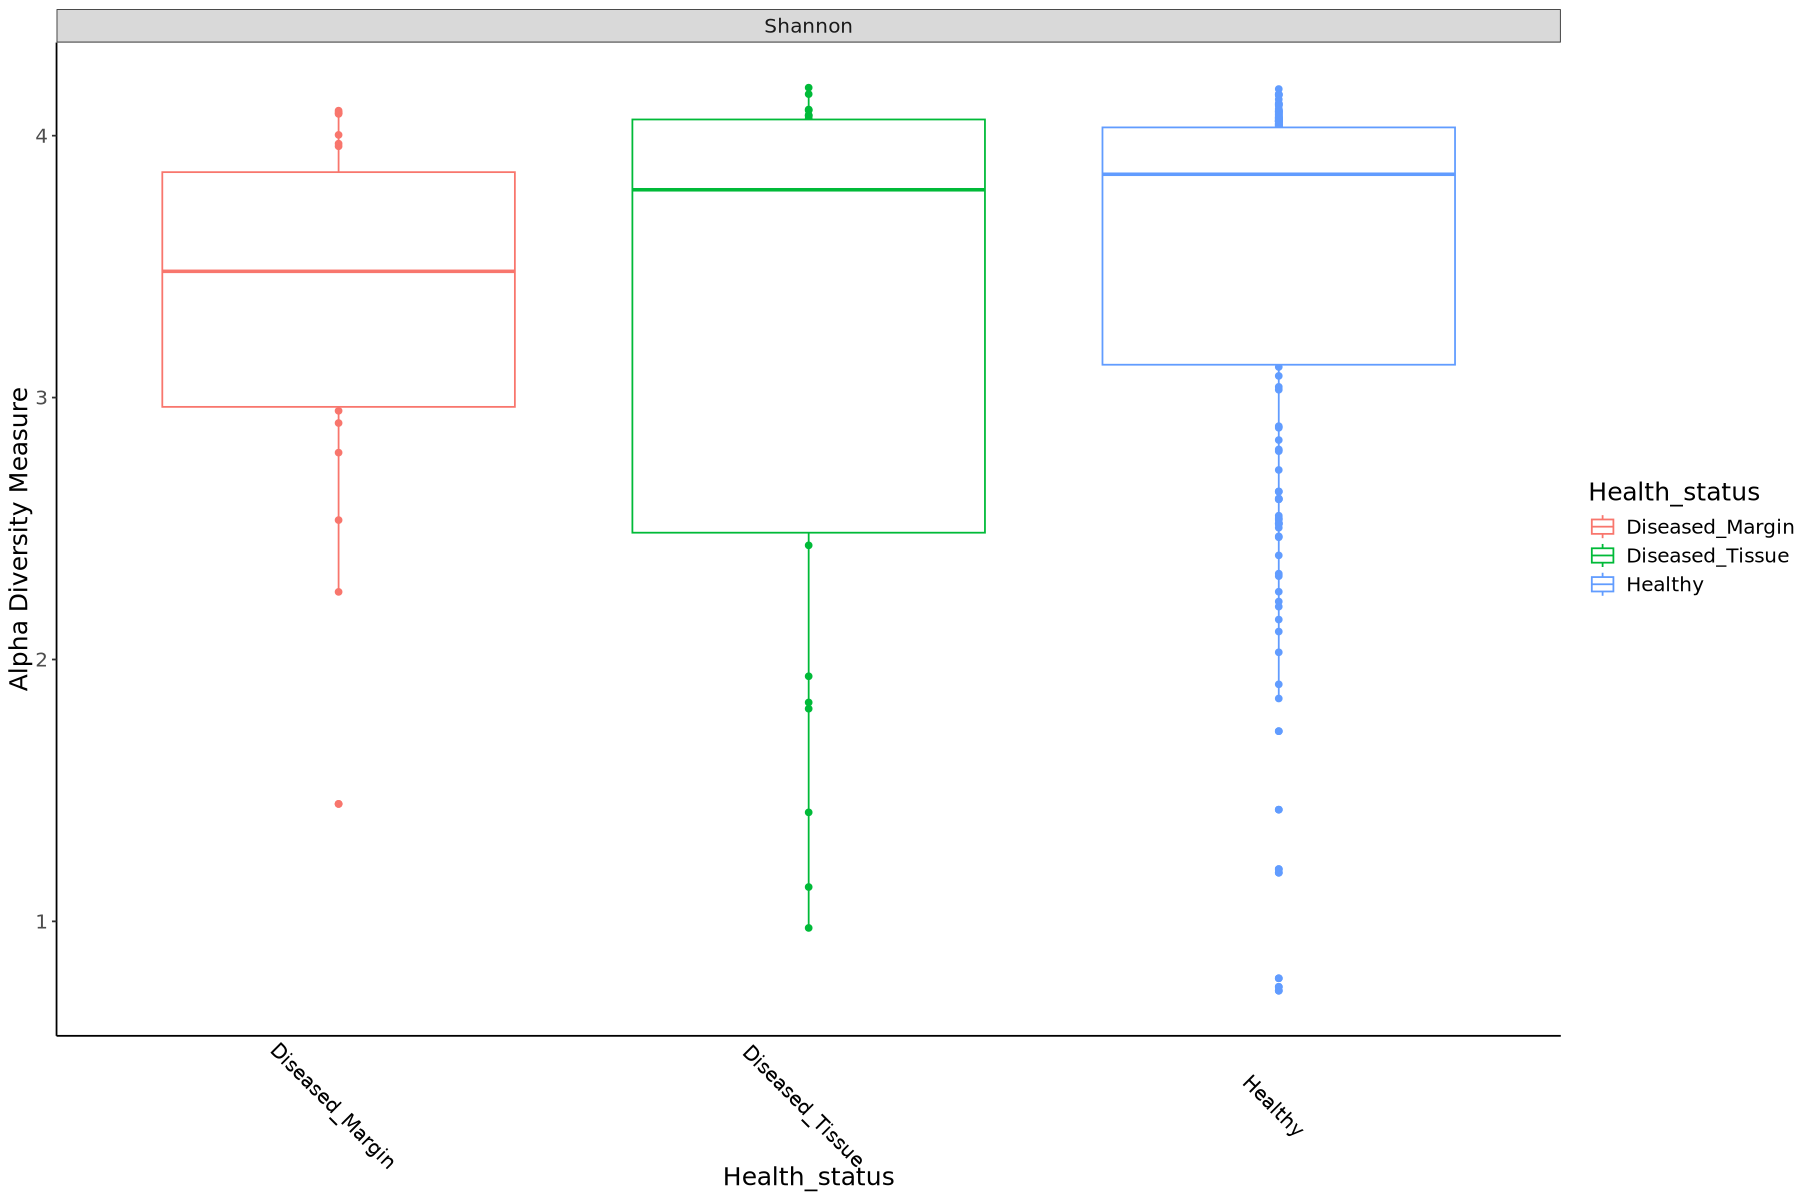

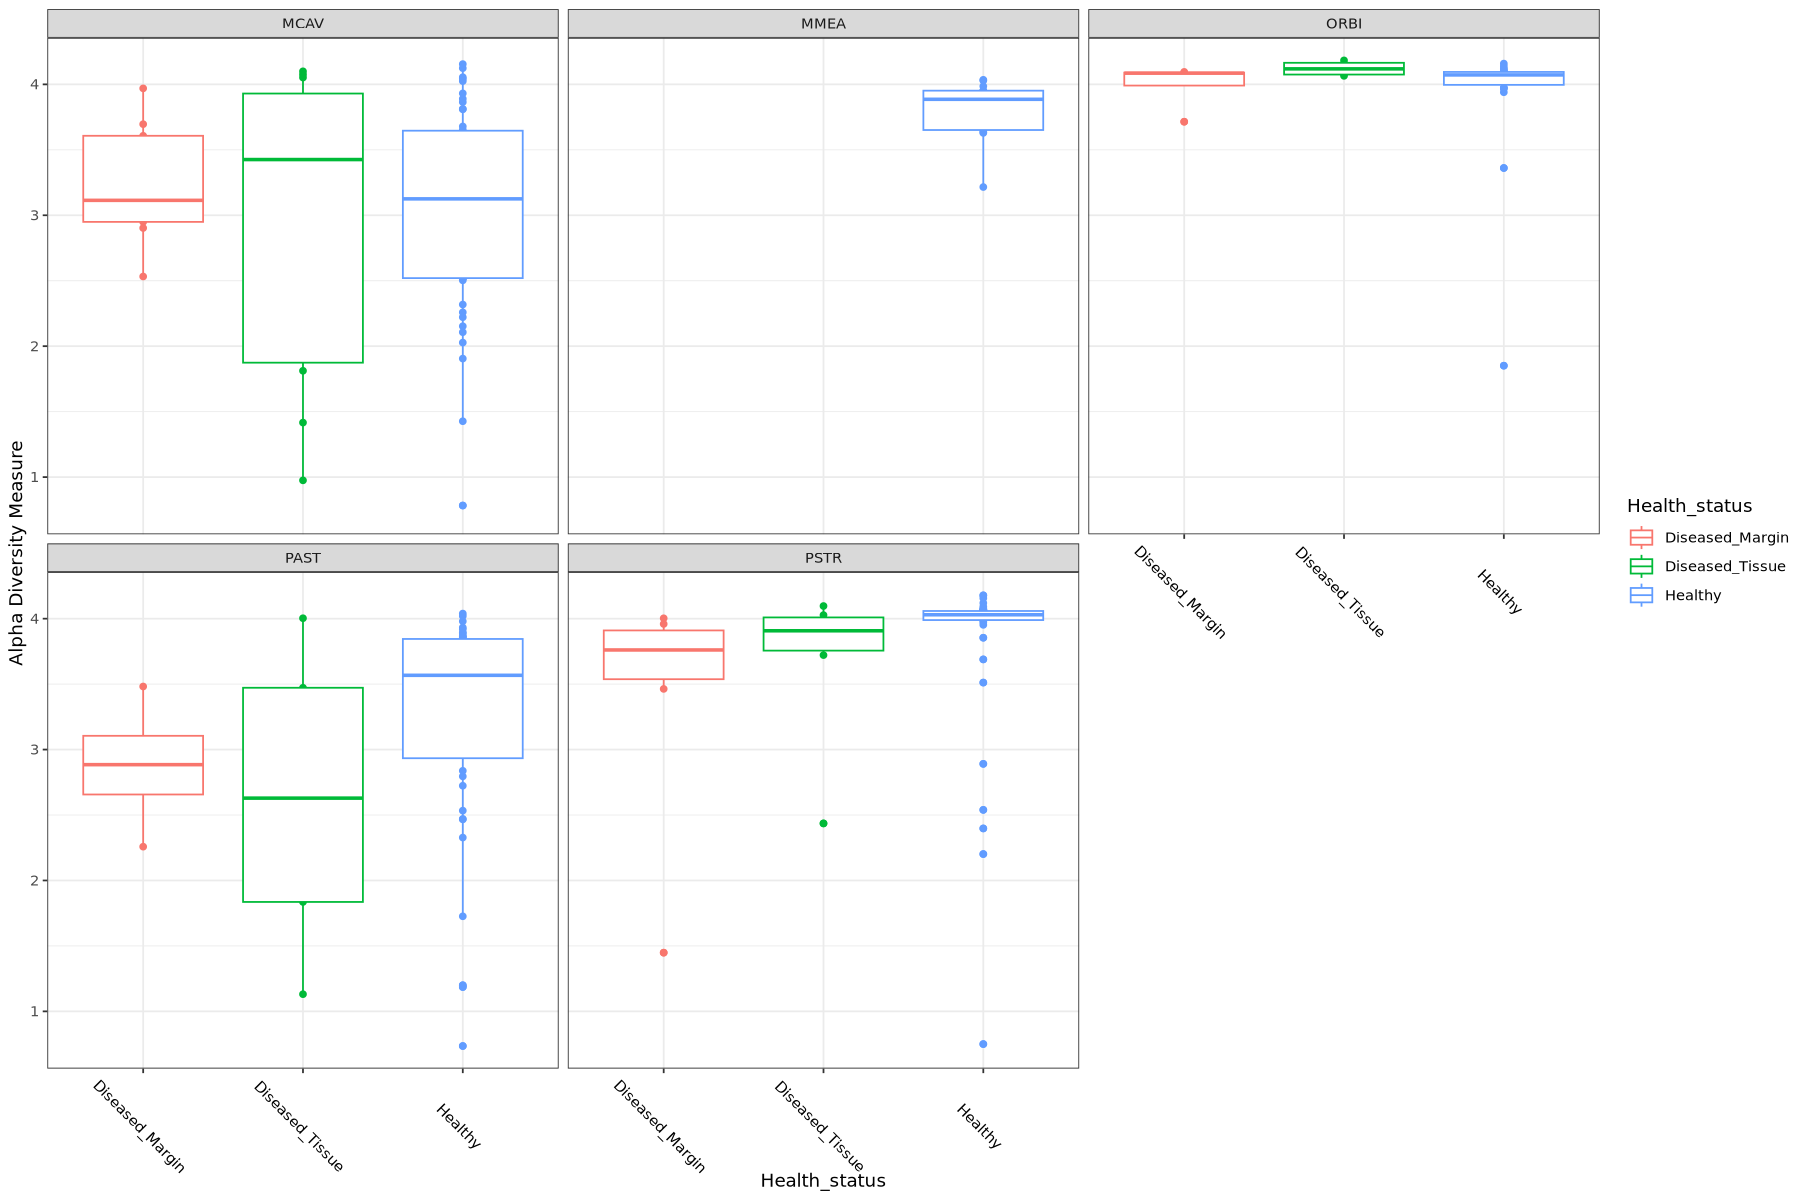

In [46]:
rich_status <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [47]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


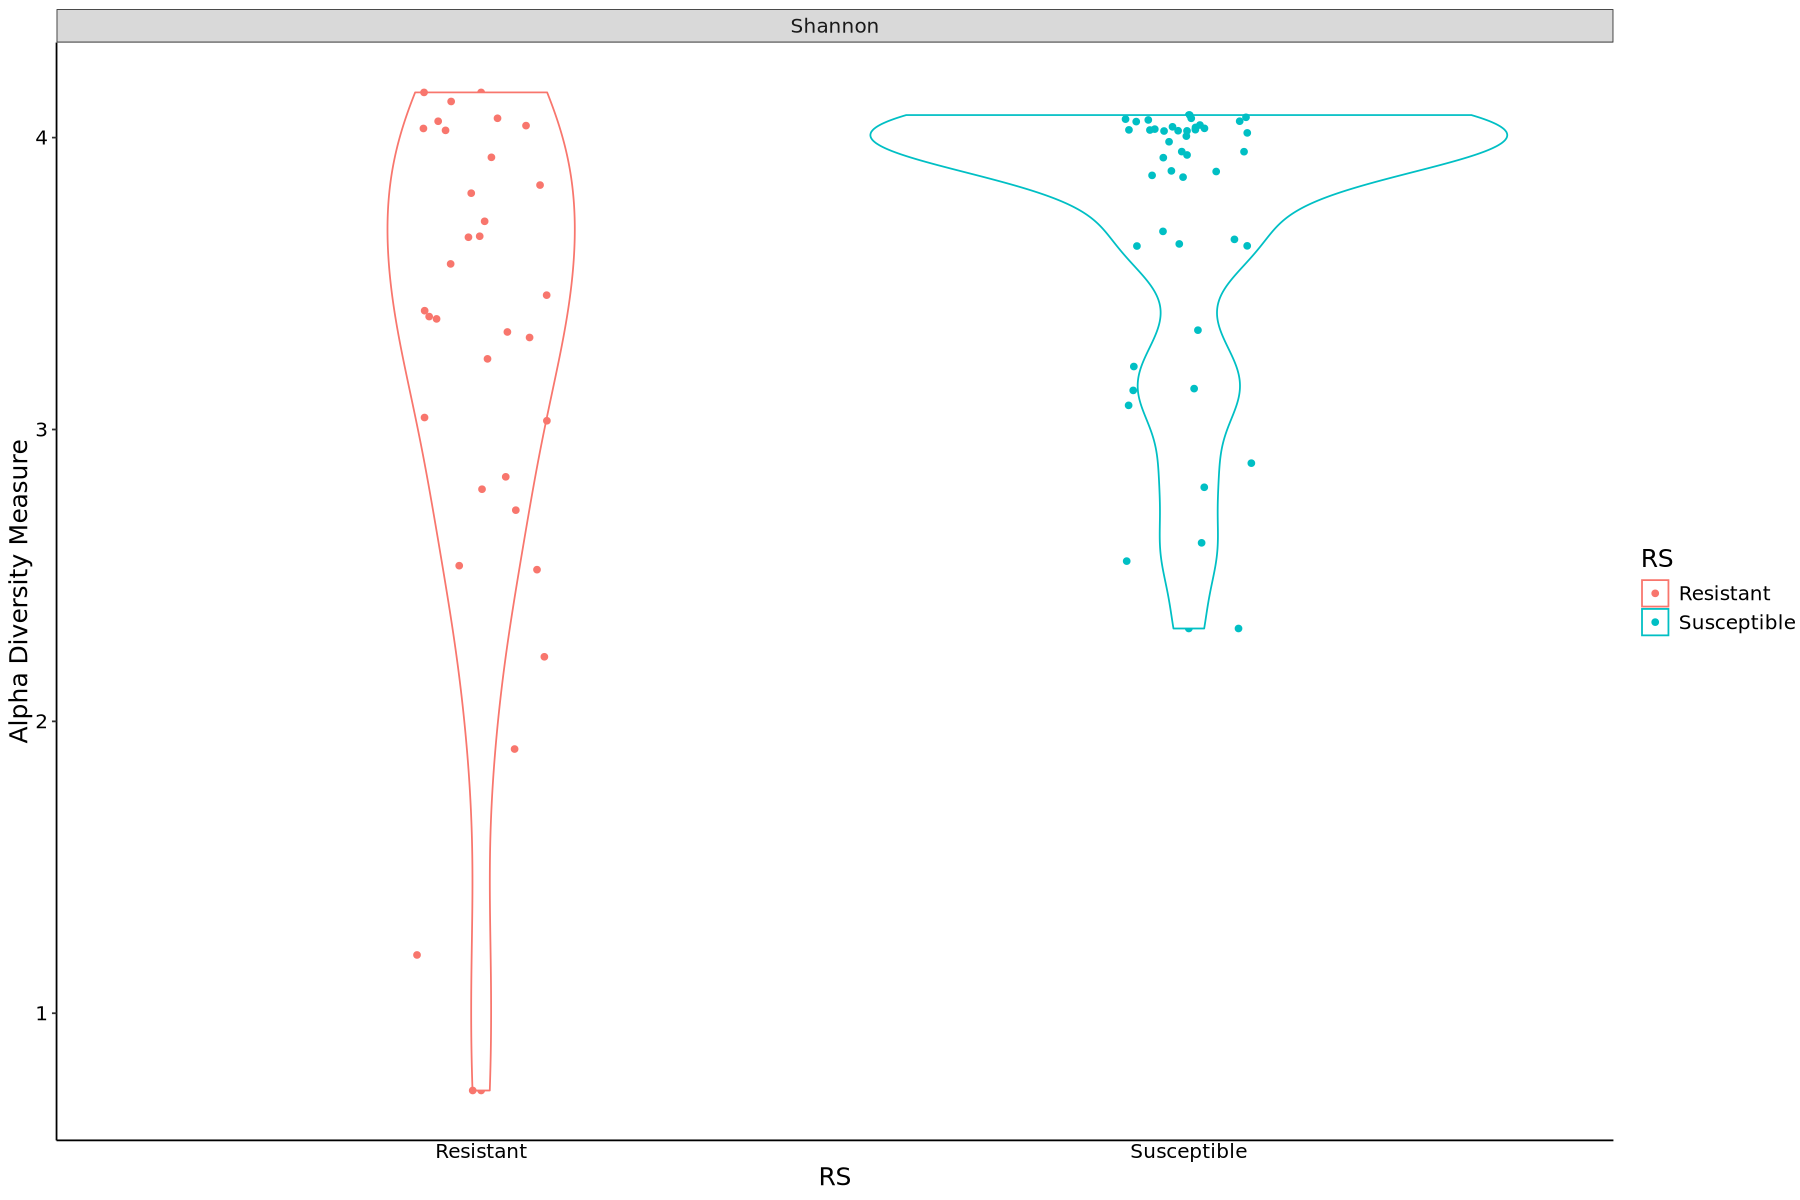

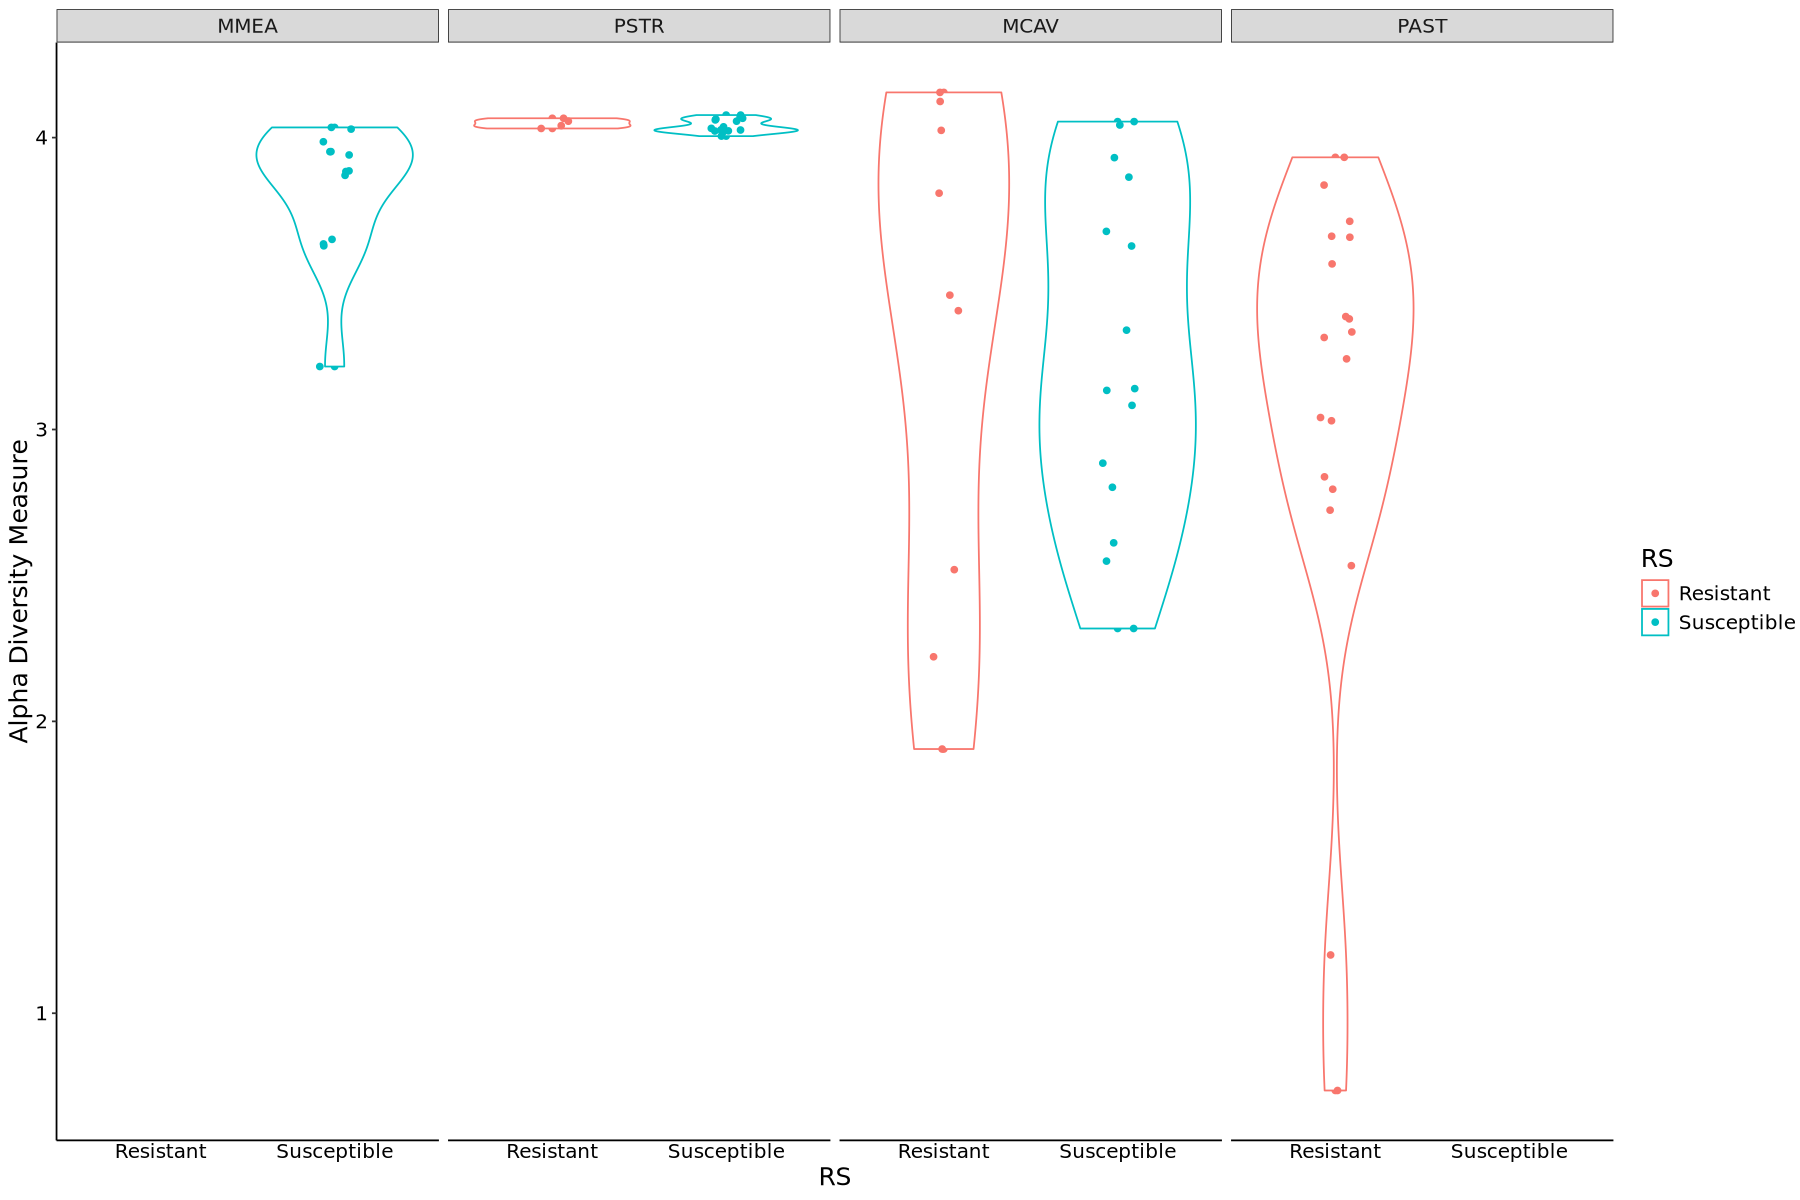

In [48]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [49]:
# most susceptible species are more diverse

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


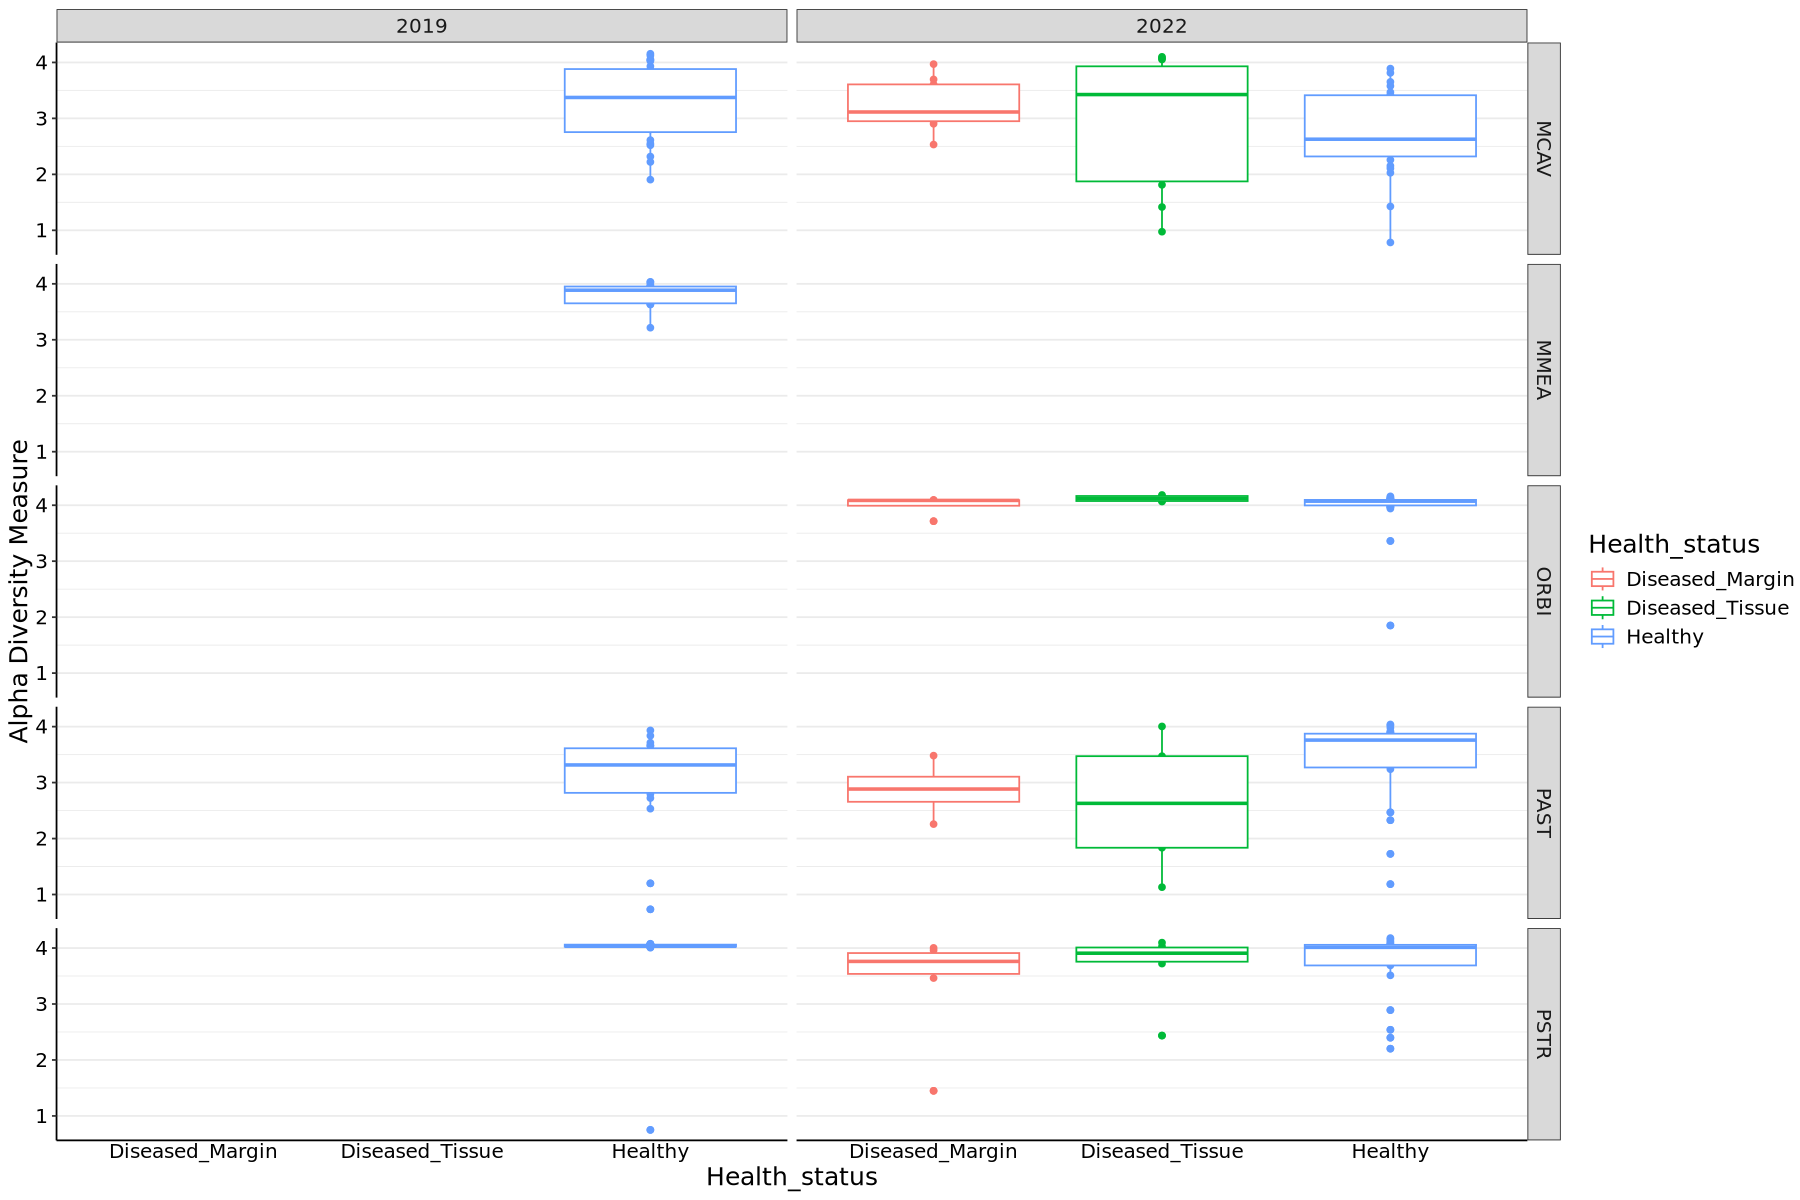

In [50]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

In [51]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [52]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.260 0.03026  8.2478  0.001 ***
Species           4    7.180 0.17242 11.7480  0.001 ***
year              1    1.468 0.03525  9.6059  0.001 ***
RS:Species        2    0.199 0.00477  0.6503  0.777    
RS:year           1    0.089 0.00214  0.5838  0.723    
Species:year      2    0.615 0.01476  2.0112  0.030 *  
RS:Species:year   1    0.120 0.00288  0.7859  0.558    
Residual        201   30.711 0.73751                   
Total           213   41.641 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [53]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.646 0.01552  2.1475  0.021 *  
RS                      1    1.685 0.04046 11.1969  0.001 ***
Species                 4    7.044 0.16916 11.7040  0.001 ***
year                    1    1.030 0.02474  6.8471  0.001 ***
Health_status:RS        2    0.276 0.00662  0.9157  0.499    
Health_status:Species   4    0.554 0.01331  0.9208  0.515    
RS:Species              2    0.221 0.00530  0.7338  0.688    
RS:year                 1    0.157 0.00378  1.0452  0.392    
Species:year            2    0.535 0.01284  1.7765  0.058 .  
RS:Species:year         1    0.455 0.01092  3.0233  0.016 *  
Residual              193   29.039 0.69736                   
Total   

In [54]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.646 0.01552  2.1454  0.024 *  
RS                               1    1.685 0.04046 11.1861  0.001 ***
Species                          4    7.044 0.16916 11.6927  0.001 ***
year                             1    1.030 0.02474  6.8405  0.001 ***
Transect                         3    0.964 0.02316  2.1346  0.012 *  
Health_status:RS                 2    0.282 0.00678  0.9373  0.491    
Health_status:Species            4    0.504 0.01211  0.8369  0.672    
RS:Species                       2    0.209 0.00503  0.6955  0.759    
RS:year                          1    0.110 0.00265  0.7336  0.622    
Species:year                   

In [55]:
# location is more important than health status?

In [56]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2   0.5554 0.01949  1.6690  0.078 .  
Species                          3   5.4251 0.19041 10.8690  0.001 ***
Transect                         3   1.0797 0.03789  2.1631  0.006 ** 
Health_status:Species            6   0.8506 0.02986  0.8521  0.731    
Health_status:Transect           6   0.8626 0.03027  0.8641  0.681    
Species:Transect                 8   1.8650 0.06546  1.4011  0.067 .  
Health_status:Species:Transect  10   1.3821 0.04851  0.8307  0.796    
Residual                        99  16.4716 0.57811                   
Total                          137  28.4921 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [57]:
# species is more important than health status - same as from prelim results

In [58]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.5235 0.06317 1.4362  0.162  
RS                      1   0.4651 0.05613 2.5523  0.039 *
Transect                3   0.7839 0.09459 1.4338  0.133  
Health_status:Transect  4   0.8648 0.10436 1.1863  0.258  
Residual               31   5.6496 0.68175                
Total                  41   8.2868 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [59]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2  0.22688 0.07607 1.1403  0.312  
RS                      1  0.07605 0.02550 0.7645  0.481  
Transect                3  0.55942 0.18757 1.8745  0.080 .
Health_status:Transect  4  0.24340 0.08161 0.6117  0.772  
RS:Transect             1  0.08611 0.02887 0.8656  0.437  
Residual               18  1.79063 0.60038                
Total                  29  2.98249 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [60]:
# maybe we do need to separate out orbi species...

In [61]:
# 2019 only 

In [62]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                    Df SumOfSqs      R2      F Pr(>F)    
RS                   1   0.6274 0.05369 5.2089  0.001 ***
Species              3   2.8109 0.24055 7.7785  0.001 ***
Transect             2   0.1614 0.01381 0.6699  0.748    
RS:Species           1   0.0564 0.00483 0.4681  0.823    
RS:Transect          2   0.1442 0.01234 0.5986  0.833    
Species:Transect     6   0.6846 0.05859 0.9473  0.526    
RS:Species:Transect  1   0.0936 0.00801 0.7767  0.554    
Residual            59   7.1067 0.60818                  
Total               75  11.6852 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [63]:
# within species, how much does RS explain difference

In [64]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)
RS           1  0.11638 0.04367 1.0546  0.370
Transect     2  0.21701 0.08144 0.9832  0.427
RS:Transect  2  0.34487 0.12942 1.5625  0.159
Residual    18  1.98647 0.74547              
Total       23  2.66473 1.00000              


### Taxa Bar Plots

In [65]:
# subset taxa and normalzie out of 100 - order level
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [66]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [67]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(sctld_raw_100)[, "order"])
names(g_colors) <- top100_names
head(g_colors)

Hyphomicrobiales     Rhodobacterales Propionibacteriales    Kitasatosporales 
          "#b73962"           "#e994a6"           "#be6b7c"           "#944557" 
    Burkholderiales          Bacillales 
          "#ea2c68"           "#e65e74"

In [68]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [69]:
sctld_raw
25486 # taxa at species level from pstr and mcav prelim...
15891 # taxa at species level 
3655 # taxa at order level 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 380 taxa and 216 samples ]
sample_data() Sample Data:       [ 216 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 380 taxa by 1 taxonomic ranks ]

[1] 25486

[1] 15891

[1] 3655

#### All Spp

In [70]:
# try just each spp R vs S in 2019
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:100]), RS_ps)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

sctld_50_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:50]), RS_ps)
sctld_50_2019_norm <- transform_sample_counts(sctld_50_2019, function(x) x / sum(x))

sctld_30_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:30]), RS_ps)
sctld_30_2019_norm <- transform_sample_counts(sctld_30_2019, function(x) x / sum(x))
                                              
sctld_10_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:10]), RS_ps)
sctld_10_2019_norm <- transform_sample_counts(sctld_10_2019, function(x) x / sum(x))

In [71]:
options(repr.plot.height = 15, repr.plot.width = 18)

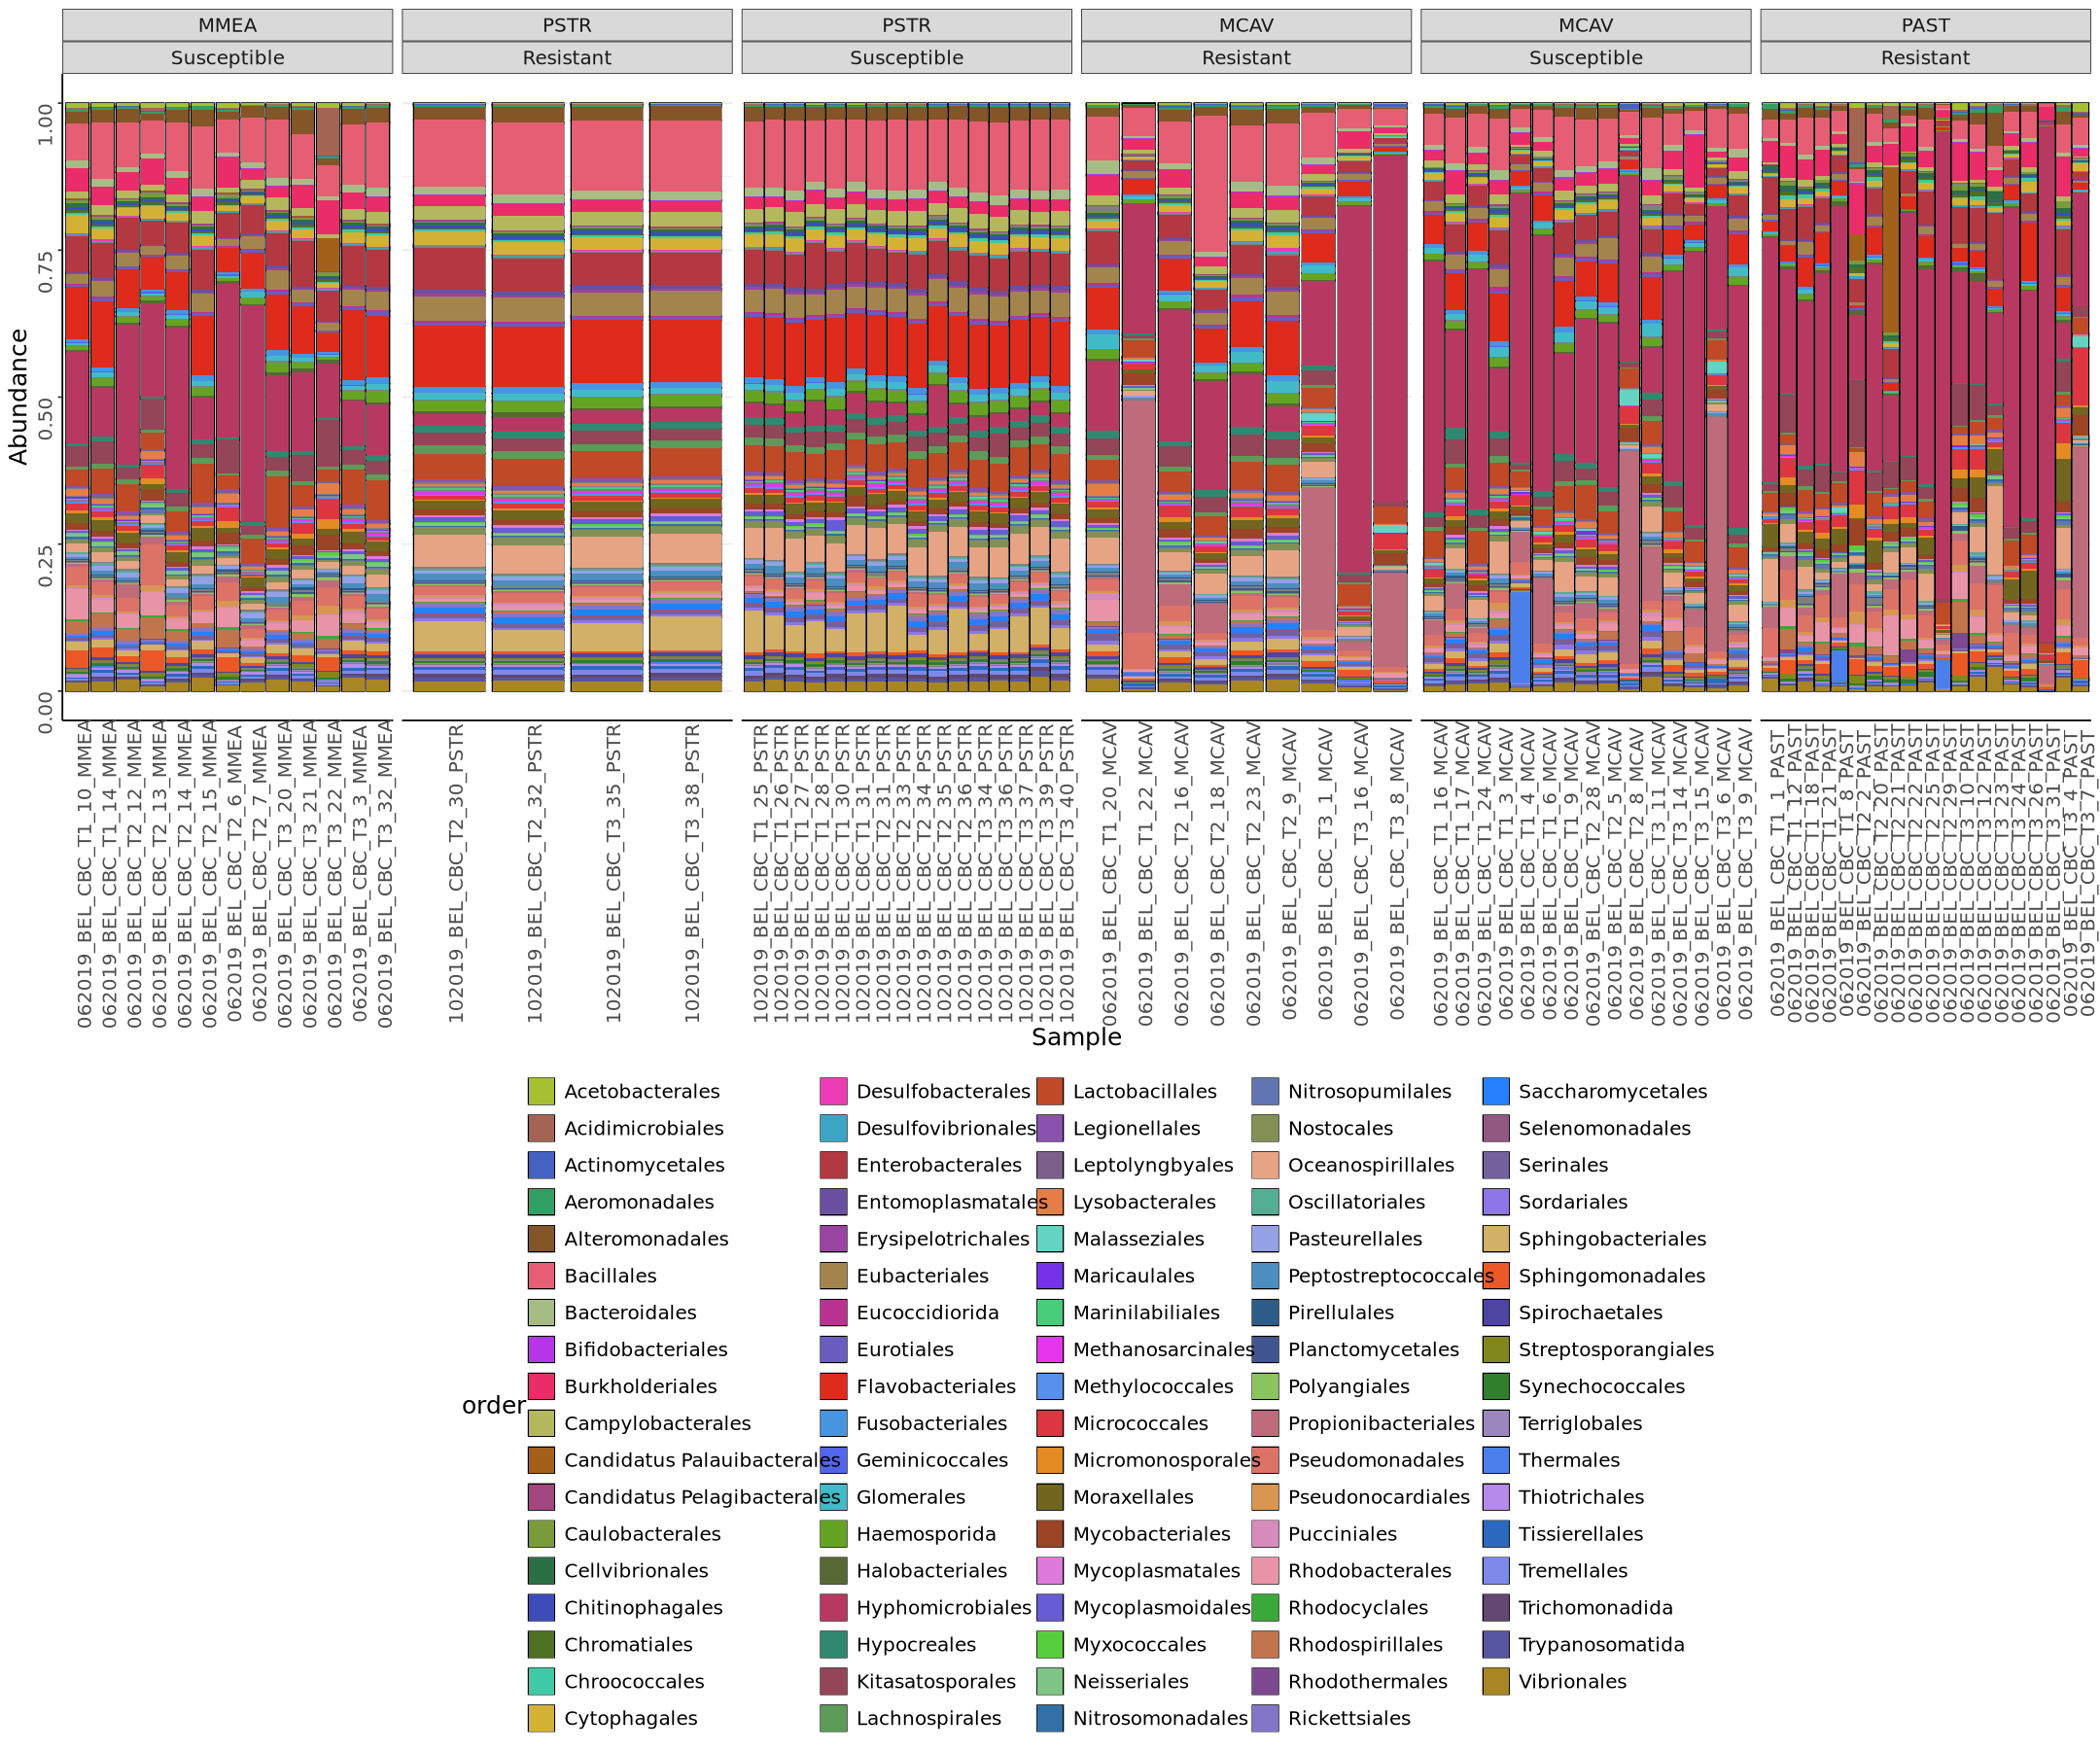

In [72]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='order')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (order)

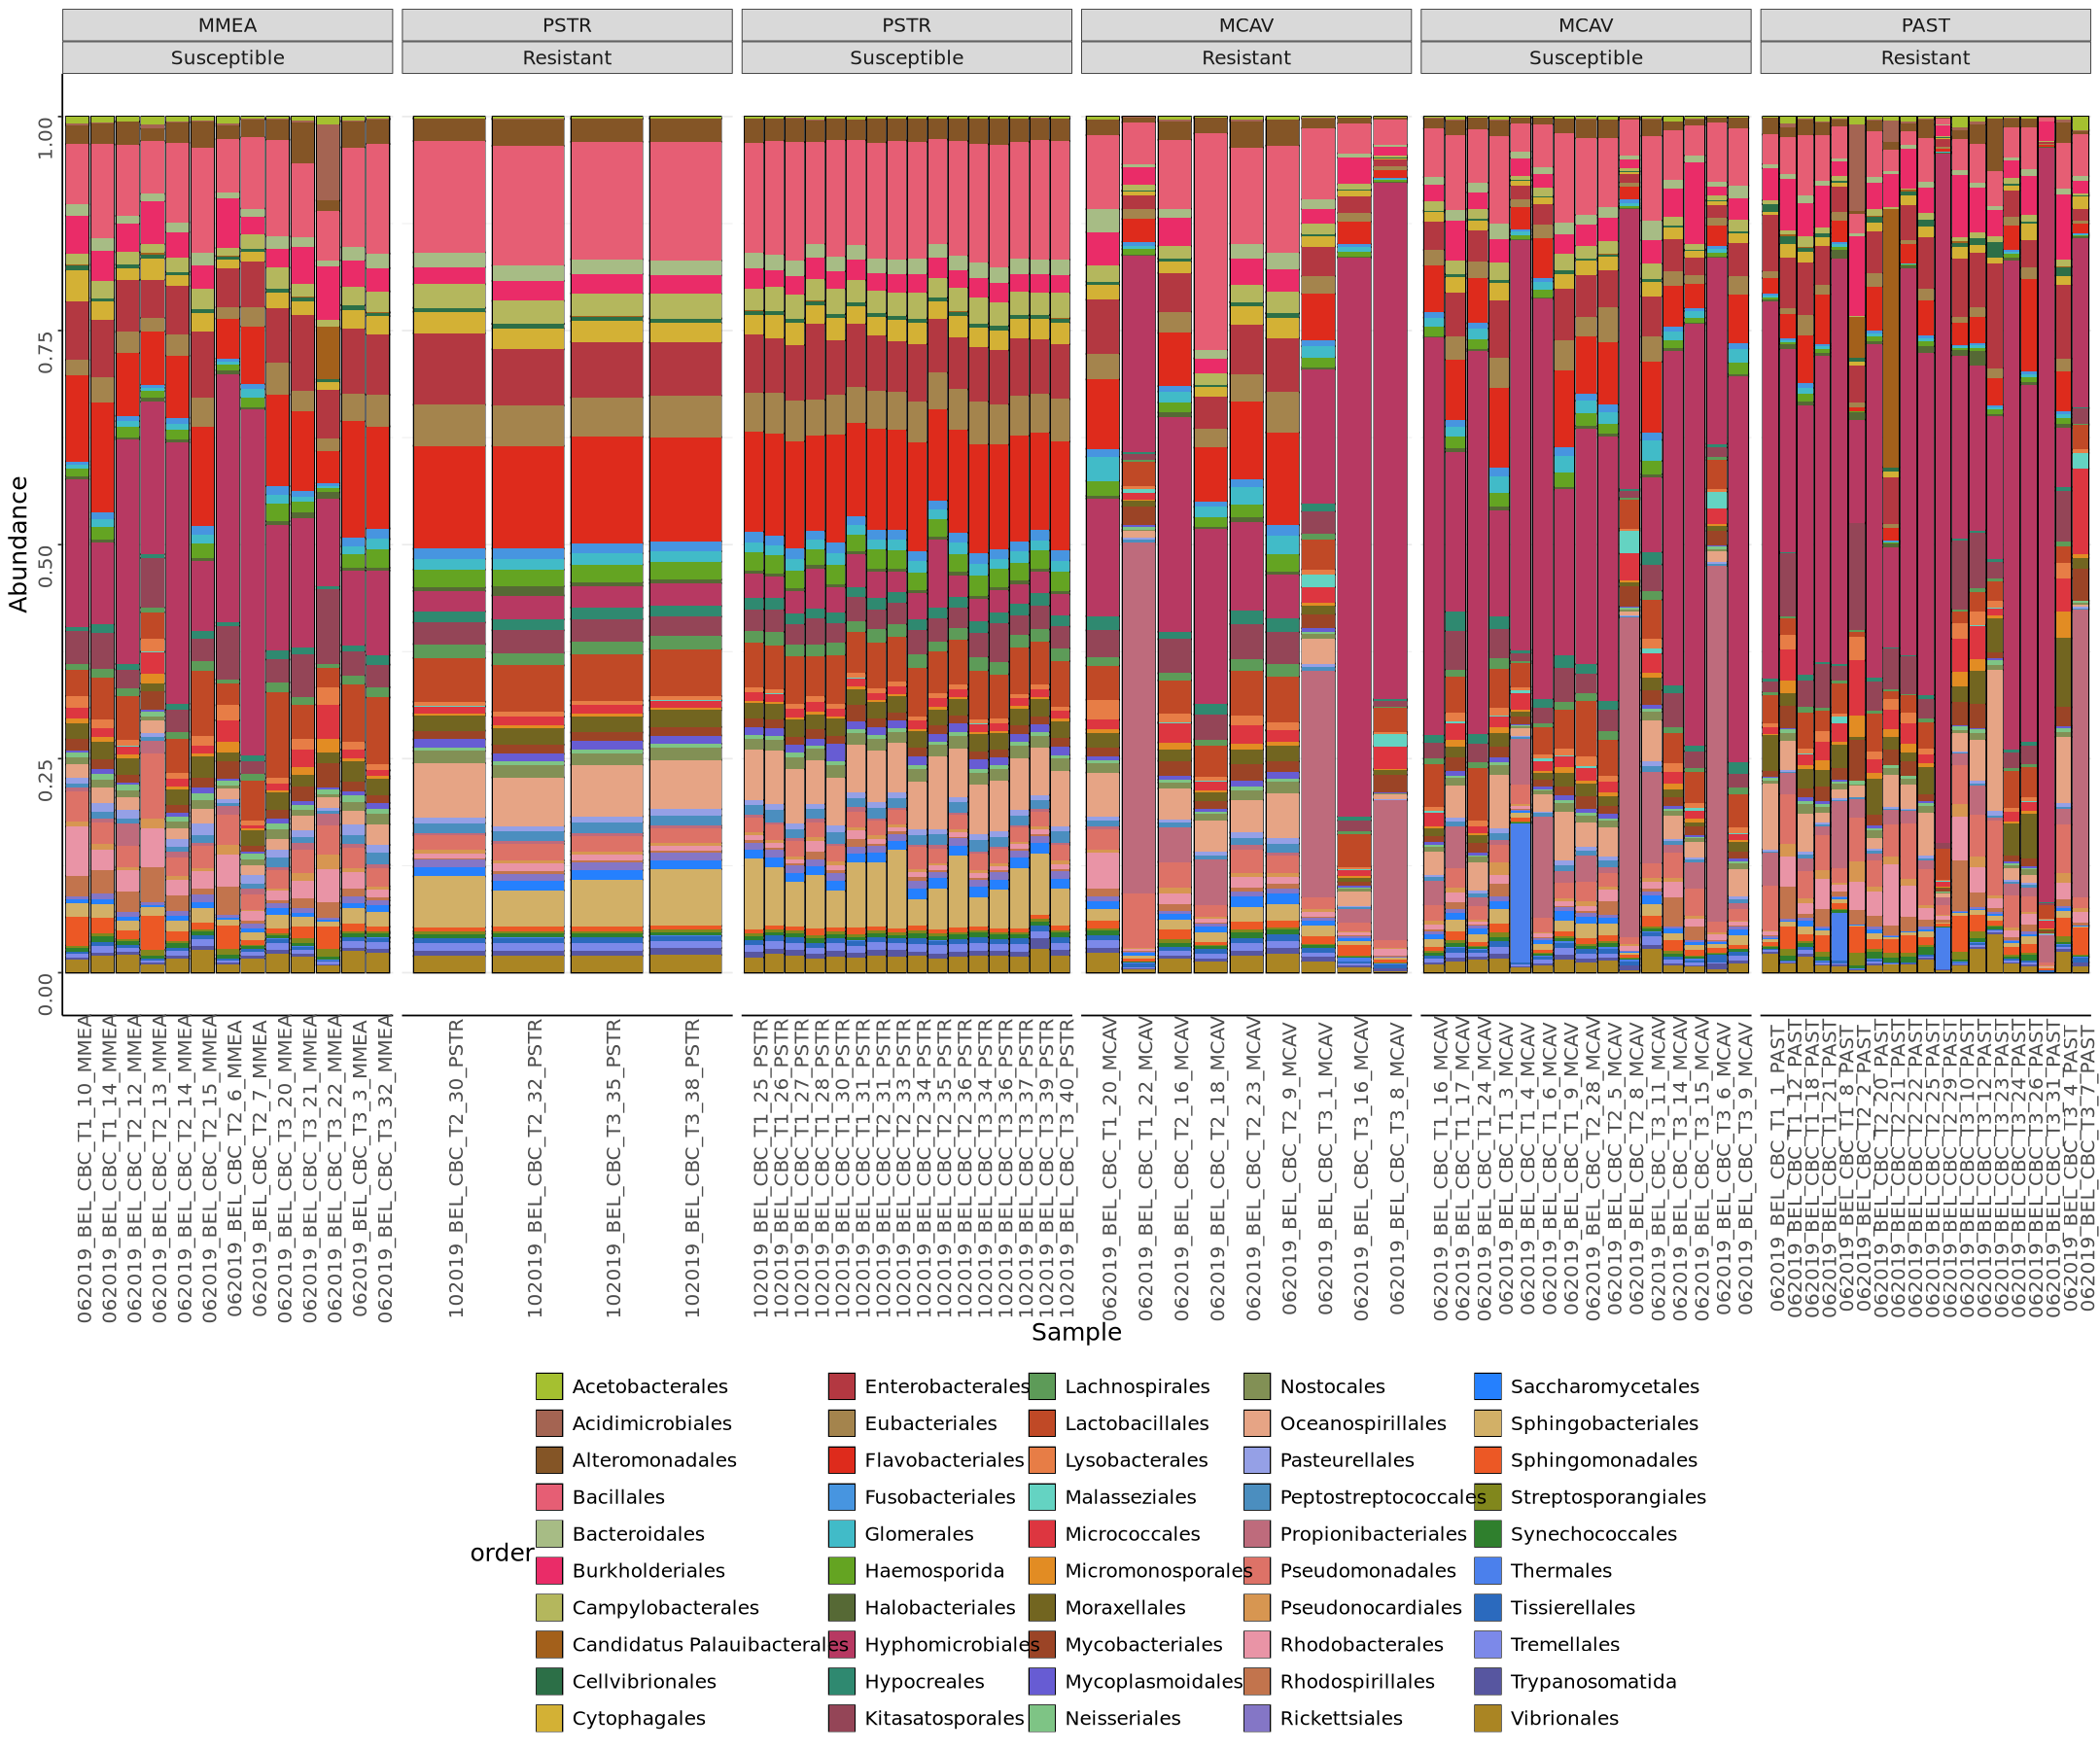

In [73]:
plot_bar(sctld_50_2019_norm,x = "Sample",fill='order')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 50 genera 2019 only 

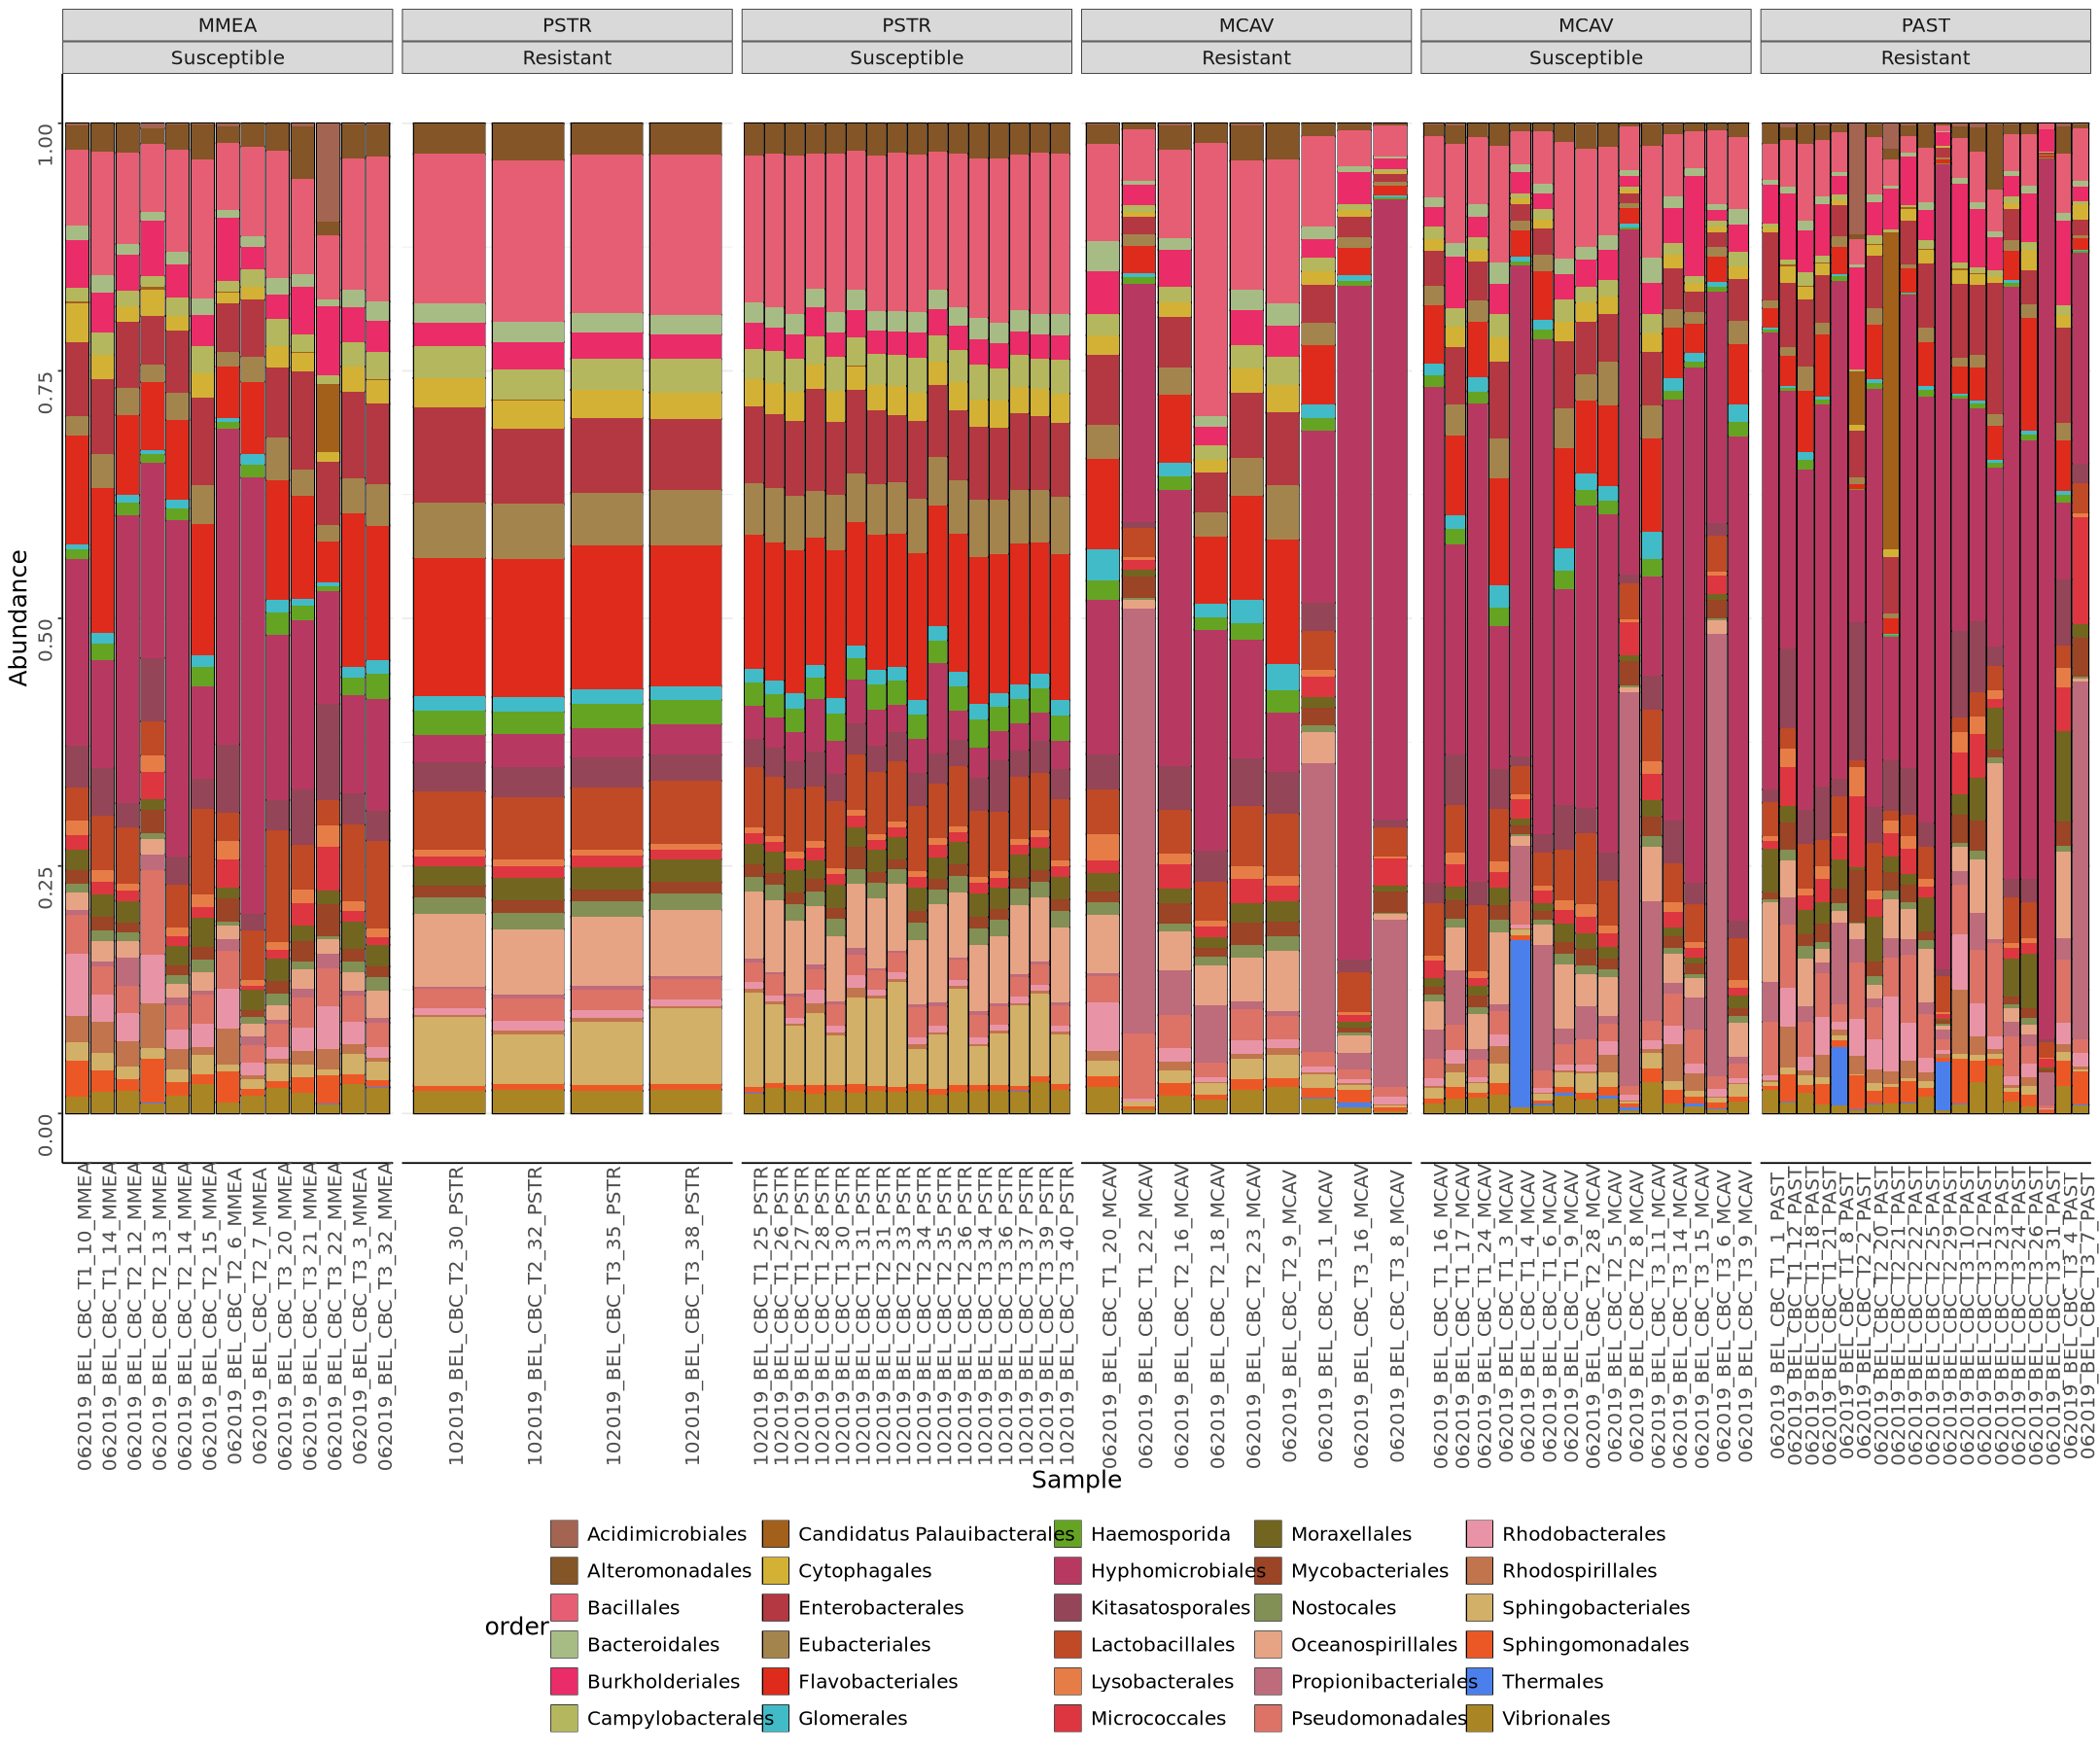

In [74]:
plot_bar(sctld_30_2019_norm,x = "Sample",fill='order')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 30 genera 2019 only 

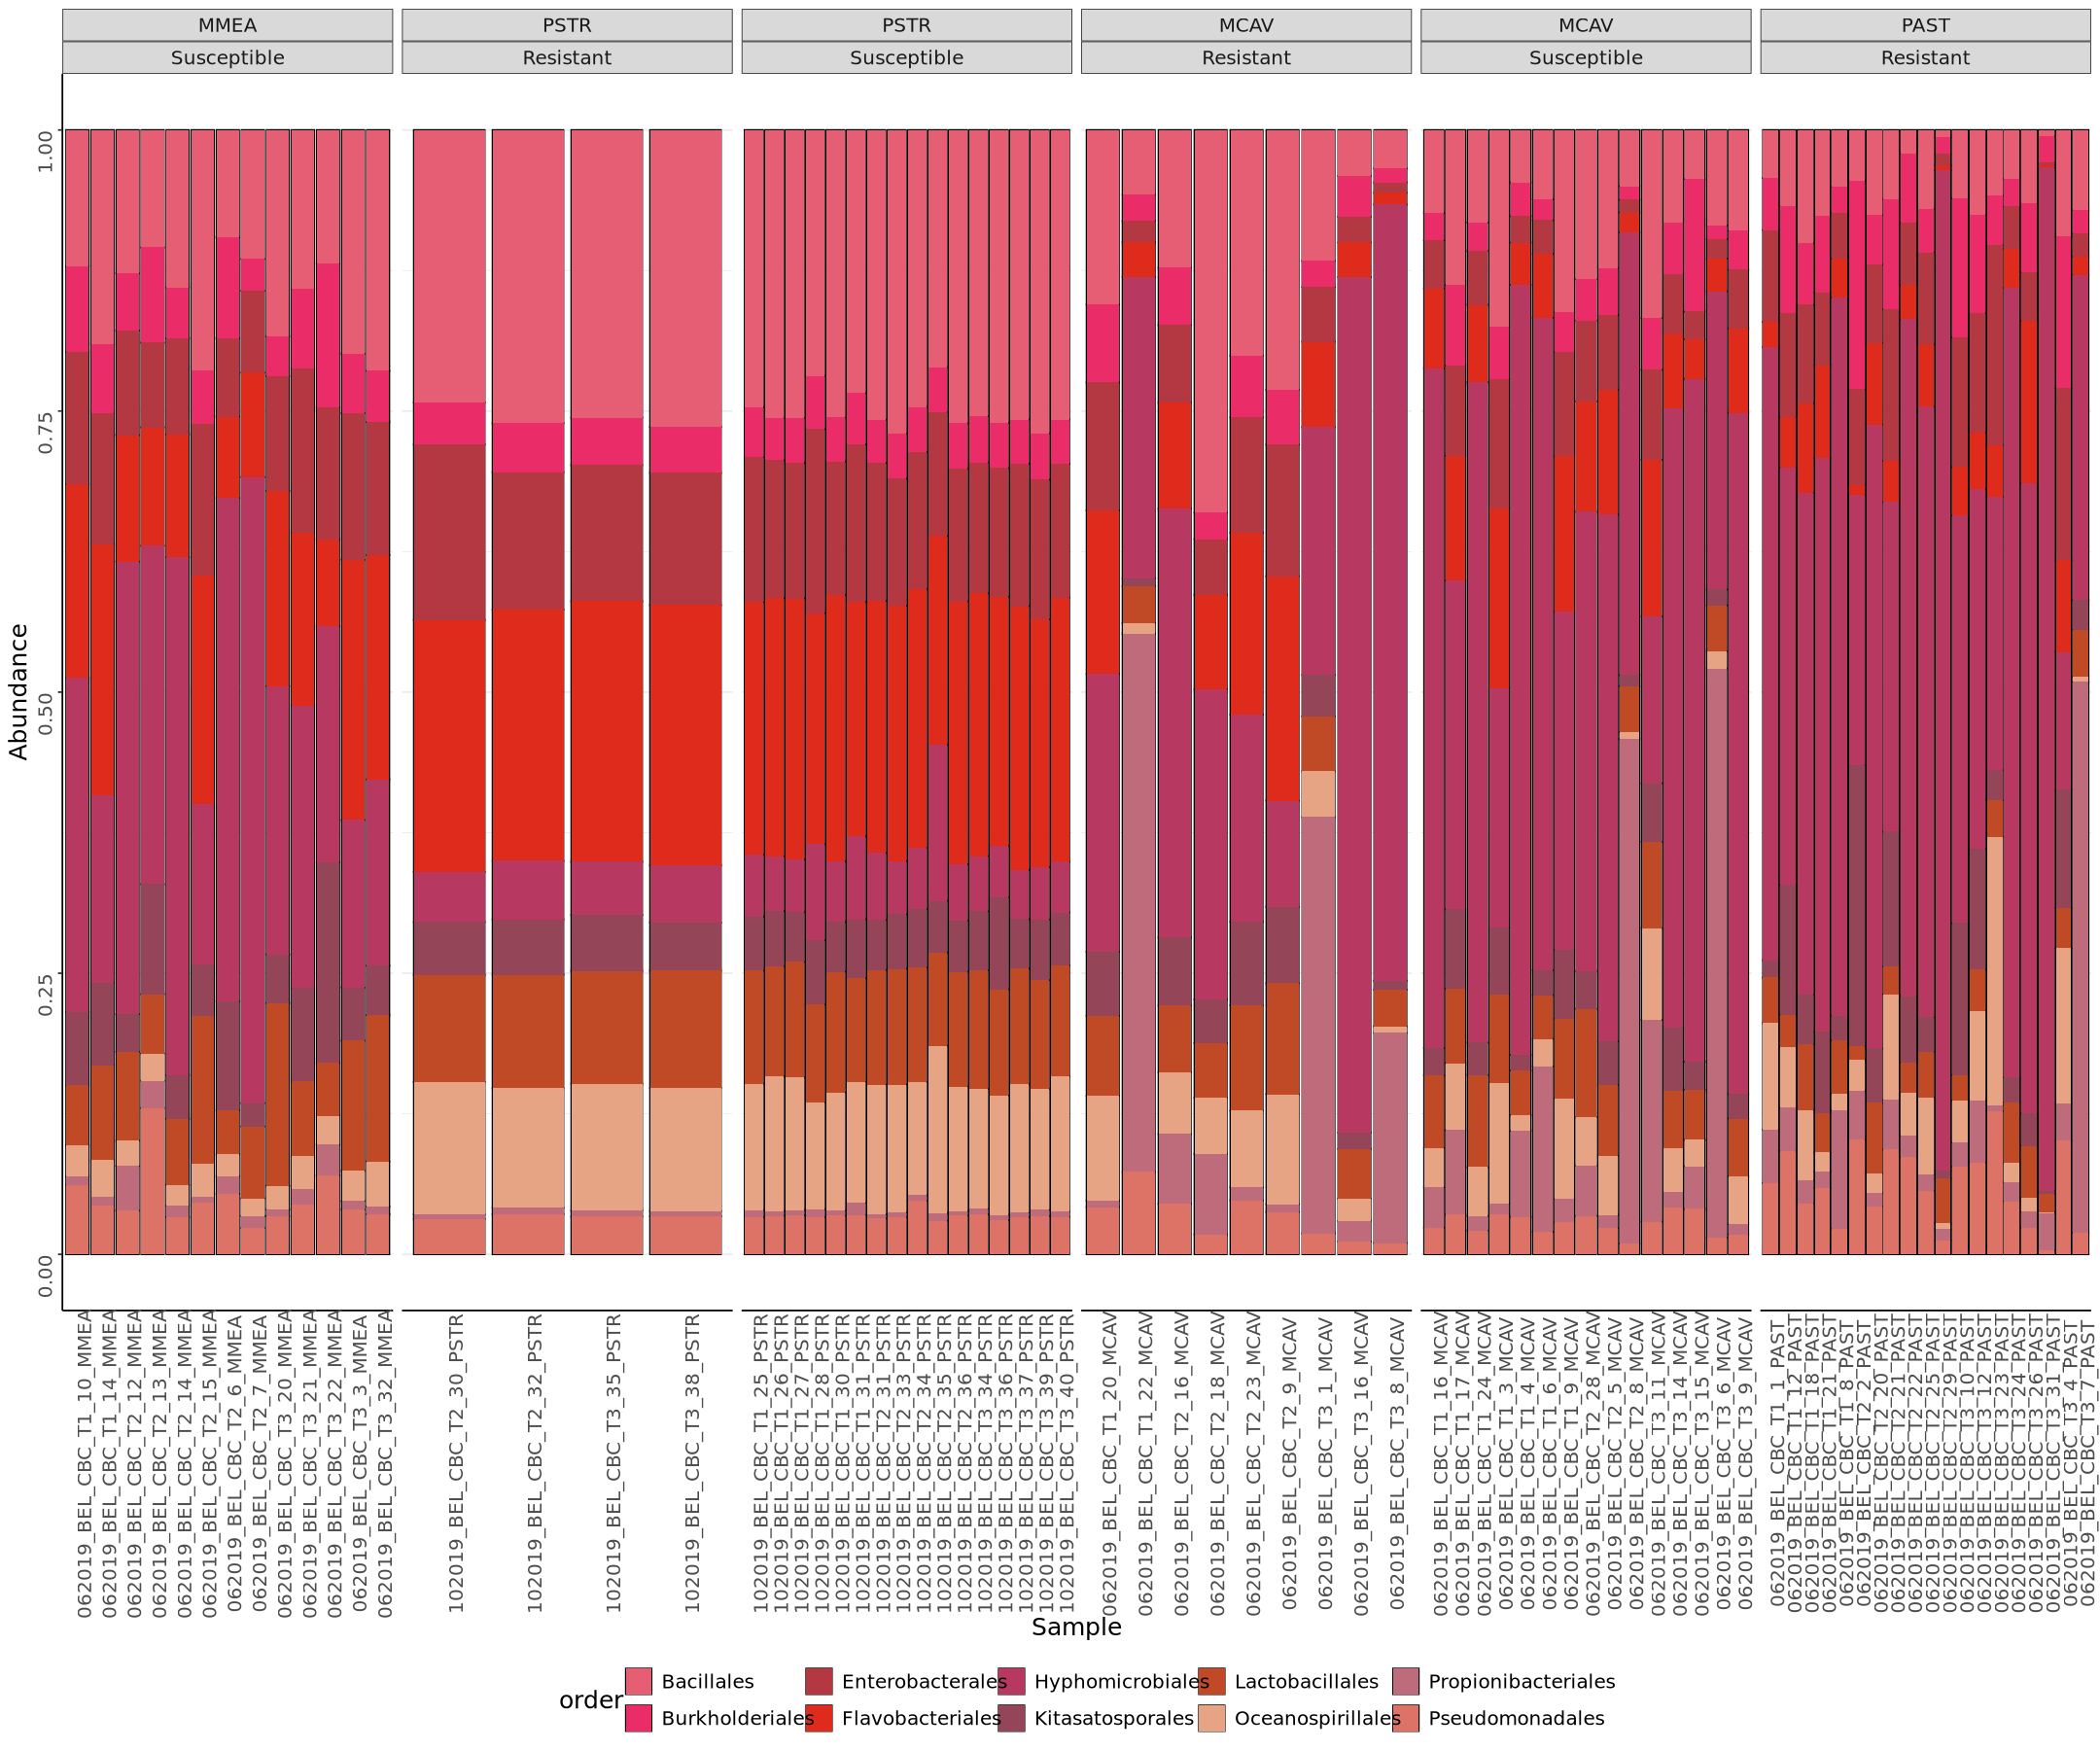

In [75]:
plot_bar(sctld_10_2019_norm,x = "Sample",fill='order')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 genera 2019 only 

In [76]:
# plot each spp individually...

#### MCAV --------------------------------------------------------------------------------

In [77]:
library(ggh4x)


Attaching package: ‘ggh4x’


The following object is masked from ‘package:cowplot’:

    save_plot




In [78]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [79]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

# top 100 order
mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

# top 50 order
mcav_50 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:50]), subset_mcav)
mcav_50_norm <- transform_sample_counts(mcav_50, function(x) x / sum(x))

# top 30 order
mcav_30 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:30]), subset_mcav)
mcav_30_norm <- transform_sample_counts(mcav_30, function(x) x / sum(x))

# top 10 order
mcav_10 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:10]), subset_mcav)
mcav_10_norm <- transform_sample_counts(mcav_10, function(x) x / sum(x))

In [80]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [81]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [82]:
# reorder colonies
mcav_g_S<-subset_samples(subset_mcav, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

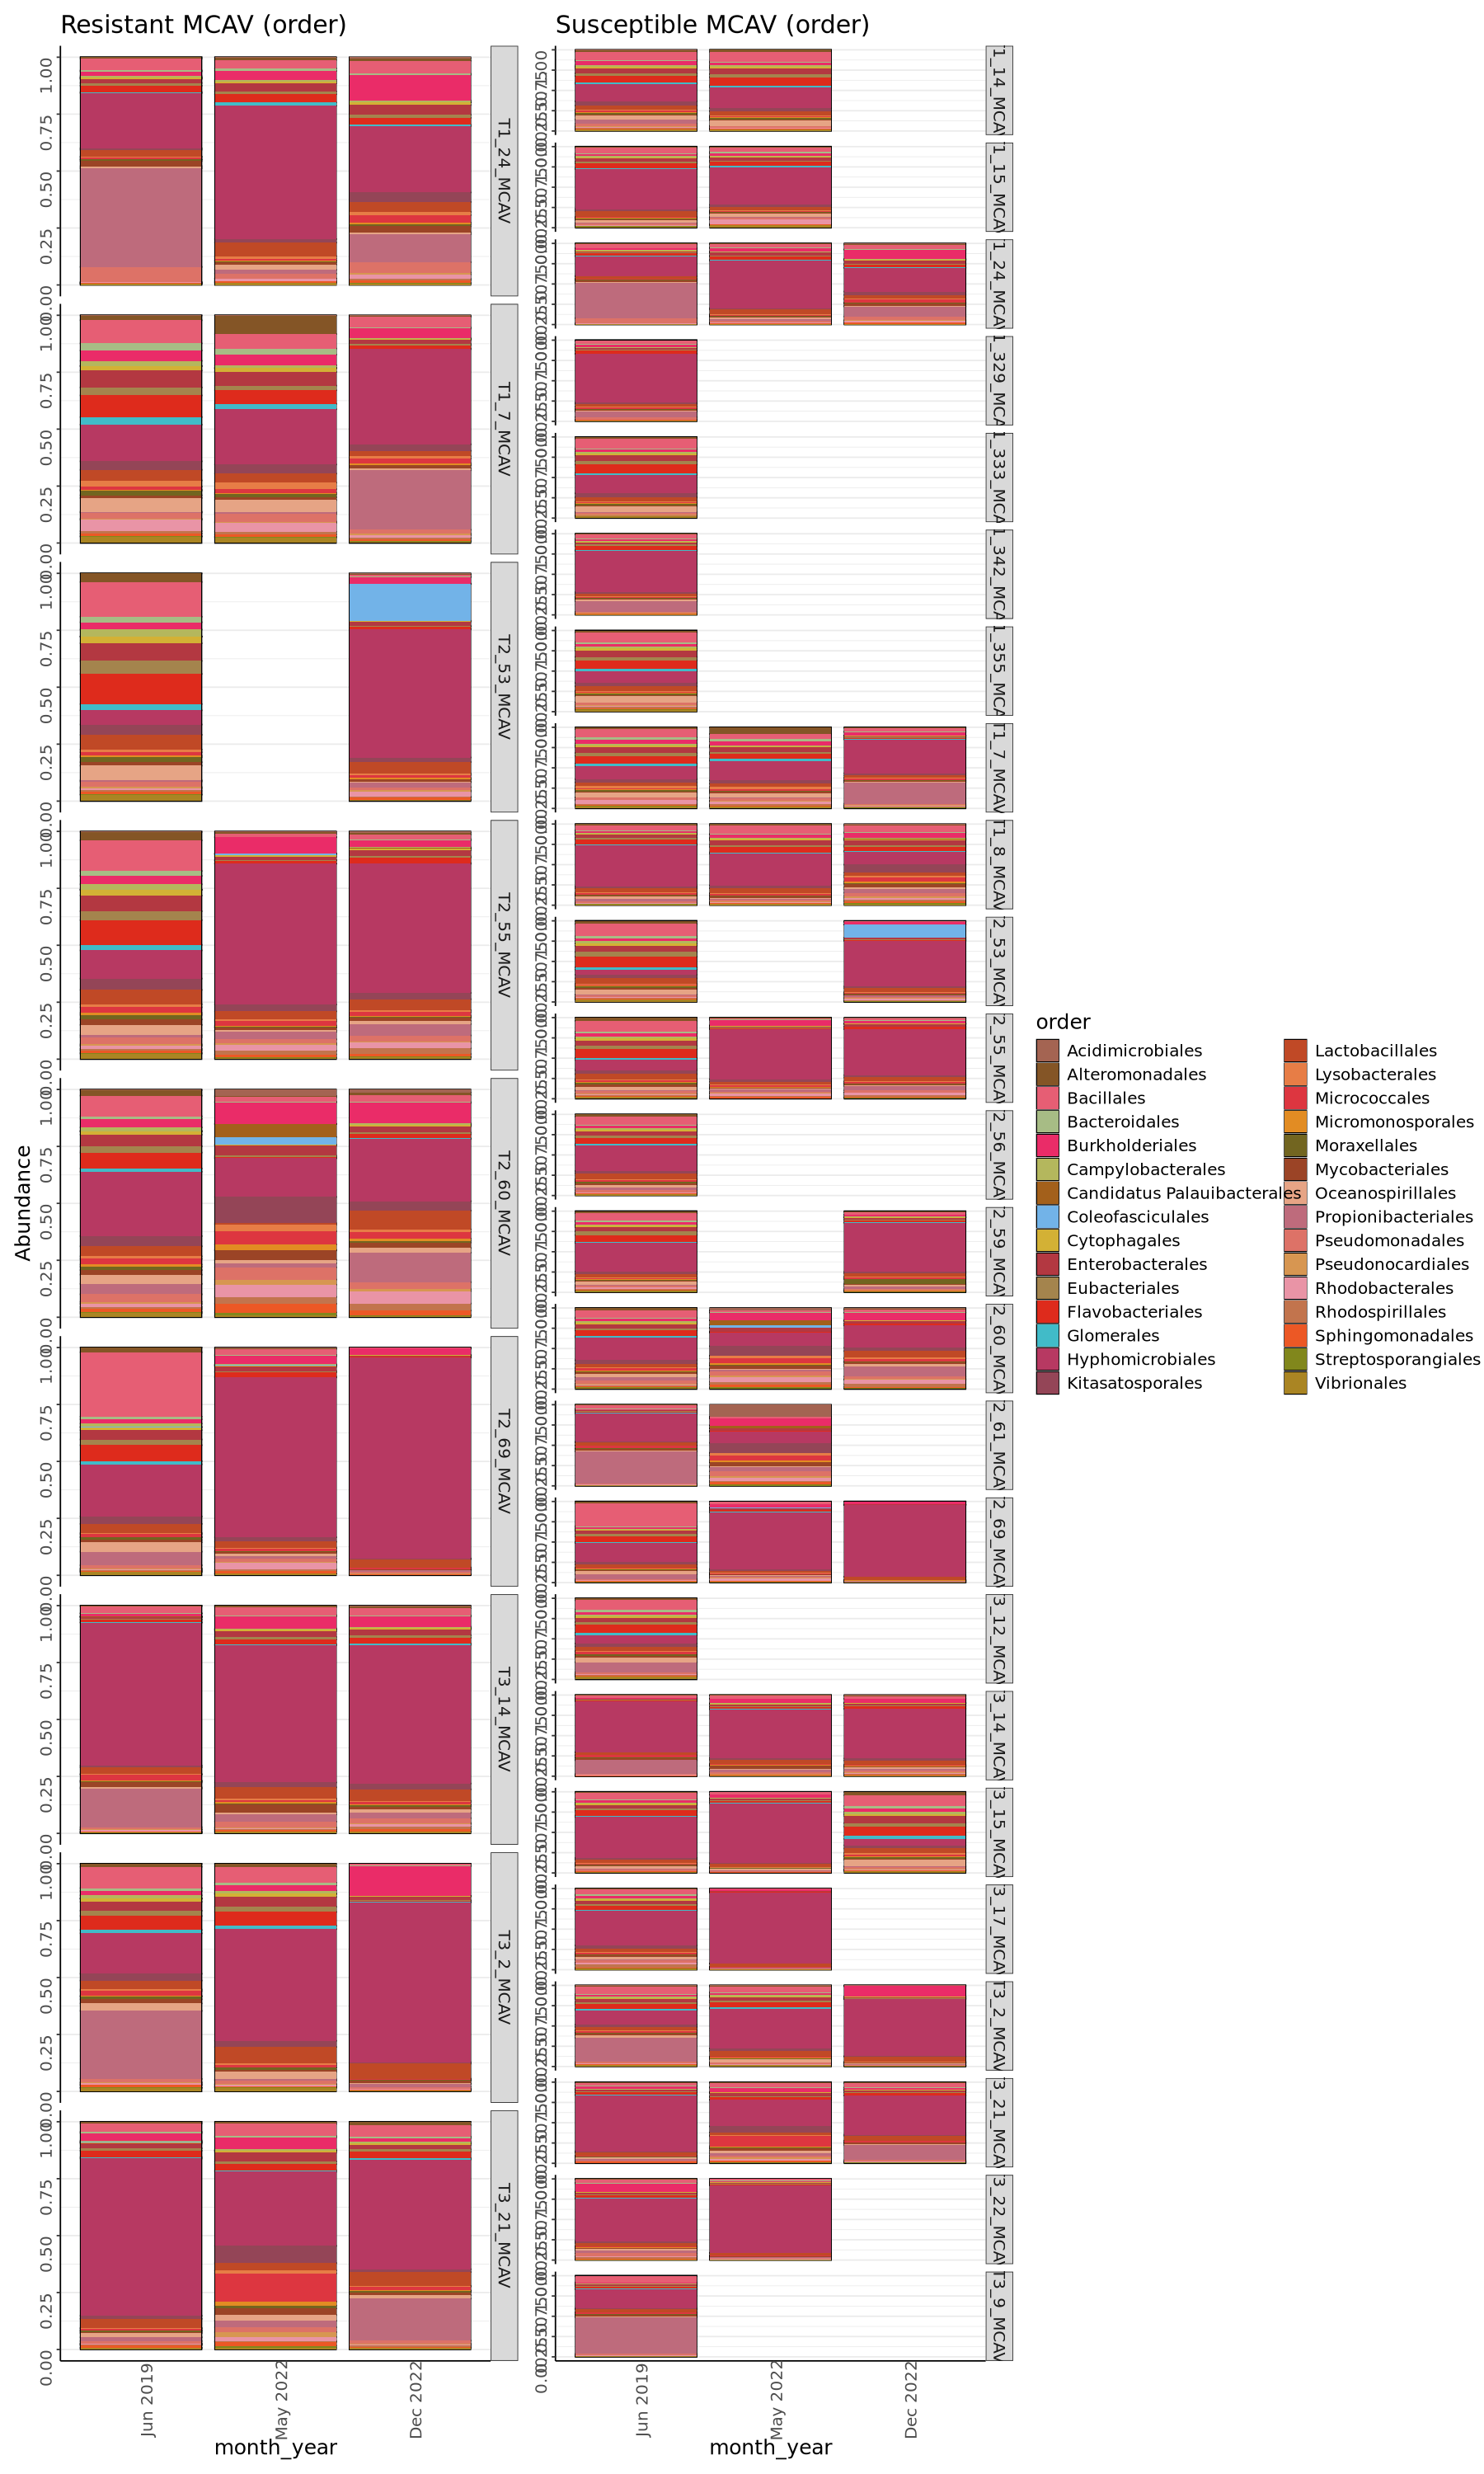

In [83]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_30_norm, RS == "Resistant"),x = "month_year", fill = "order")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant MCAV (order)")

p_S <- plot_bar(mcav_30_norm,x = "month_year", fill = "order") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MCAV (order)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "MCAV colonies") &
  theme(legend.position = "right")

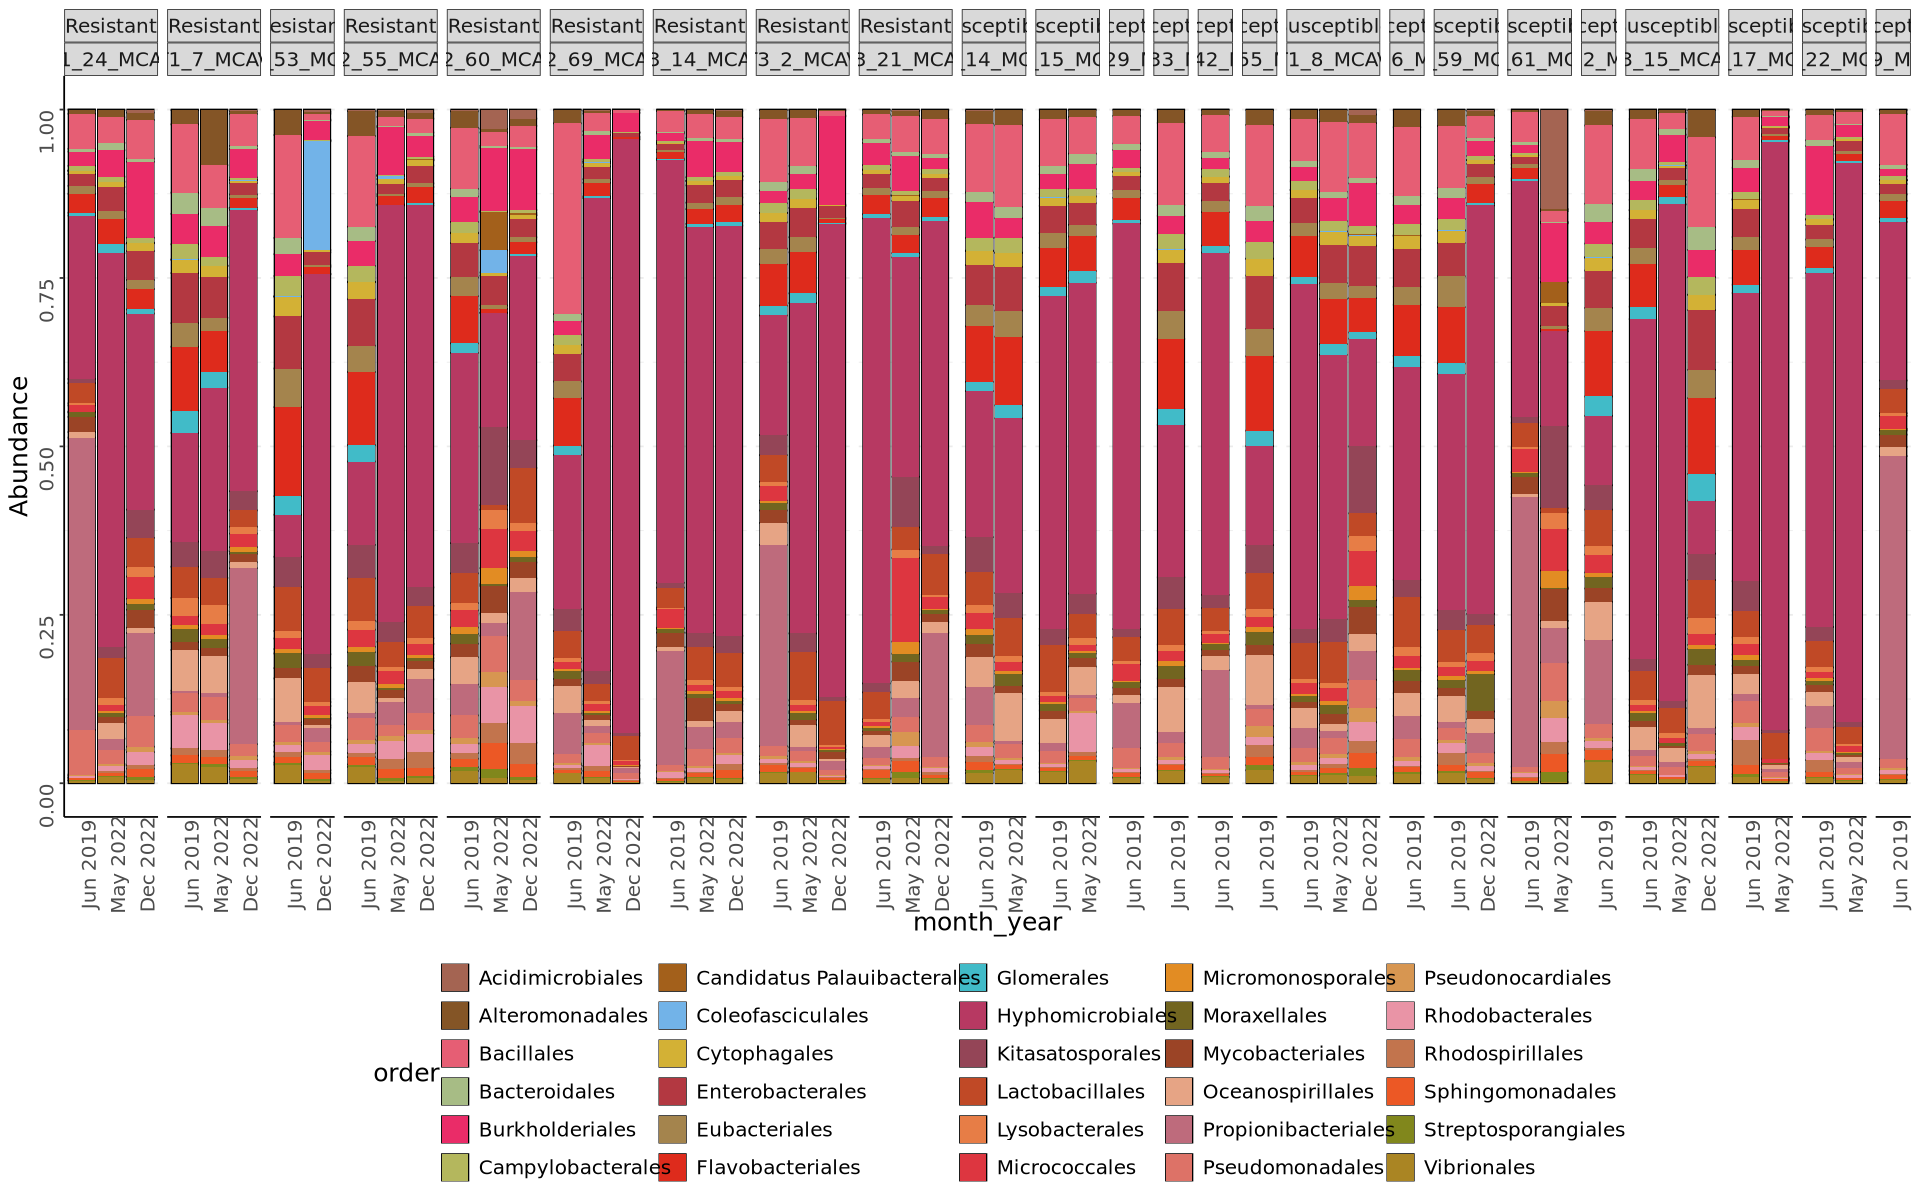

In [84]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 order - R vs S. individuals over time 

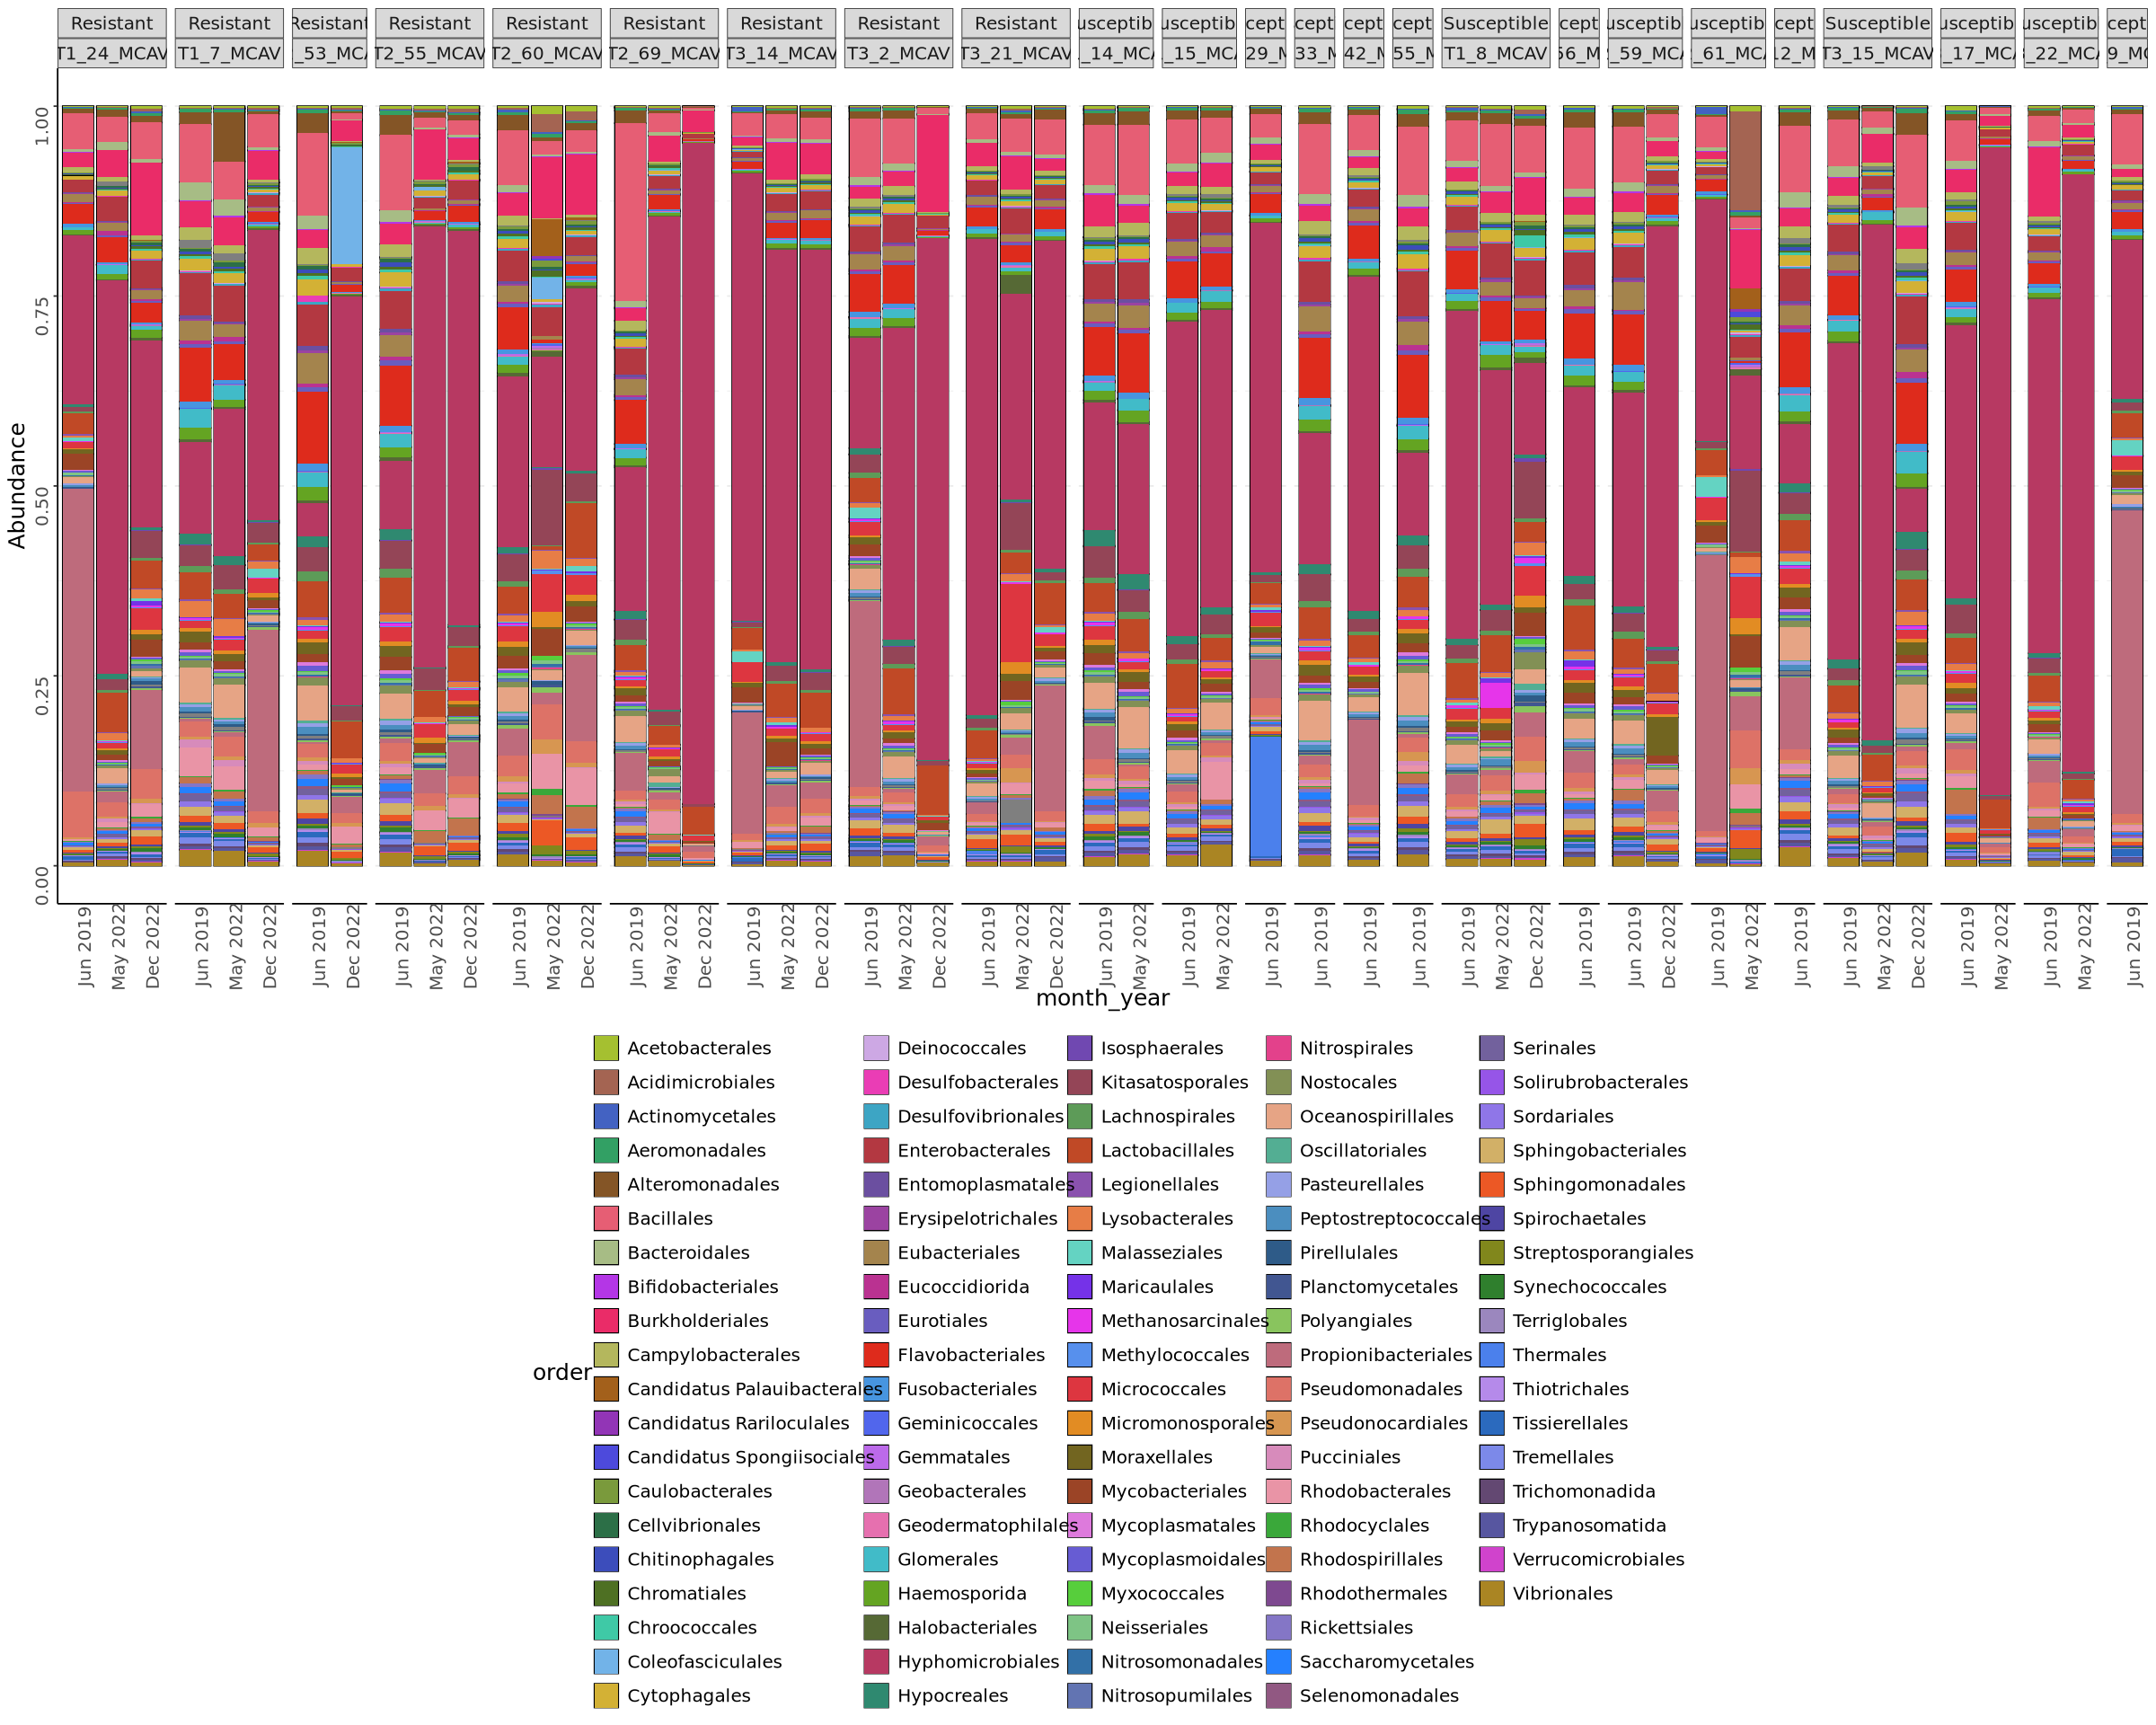

In [85]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (order)

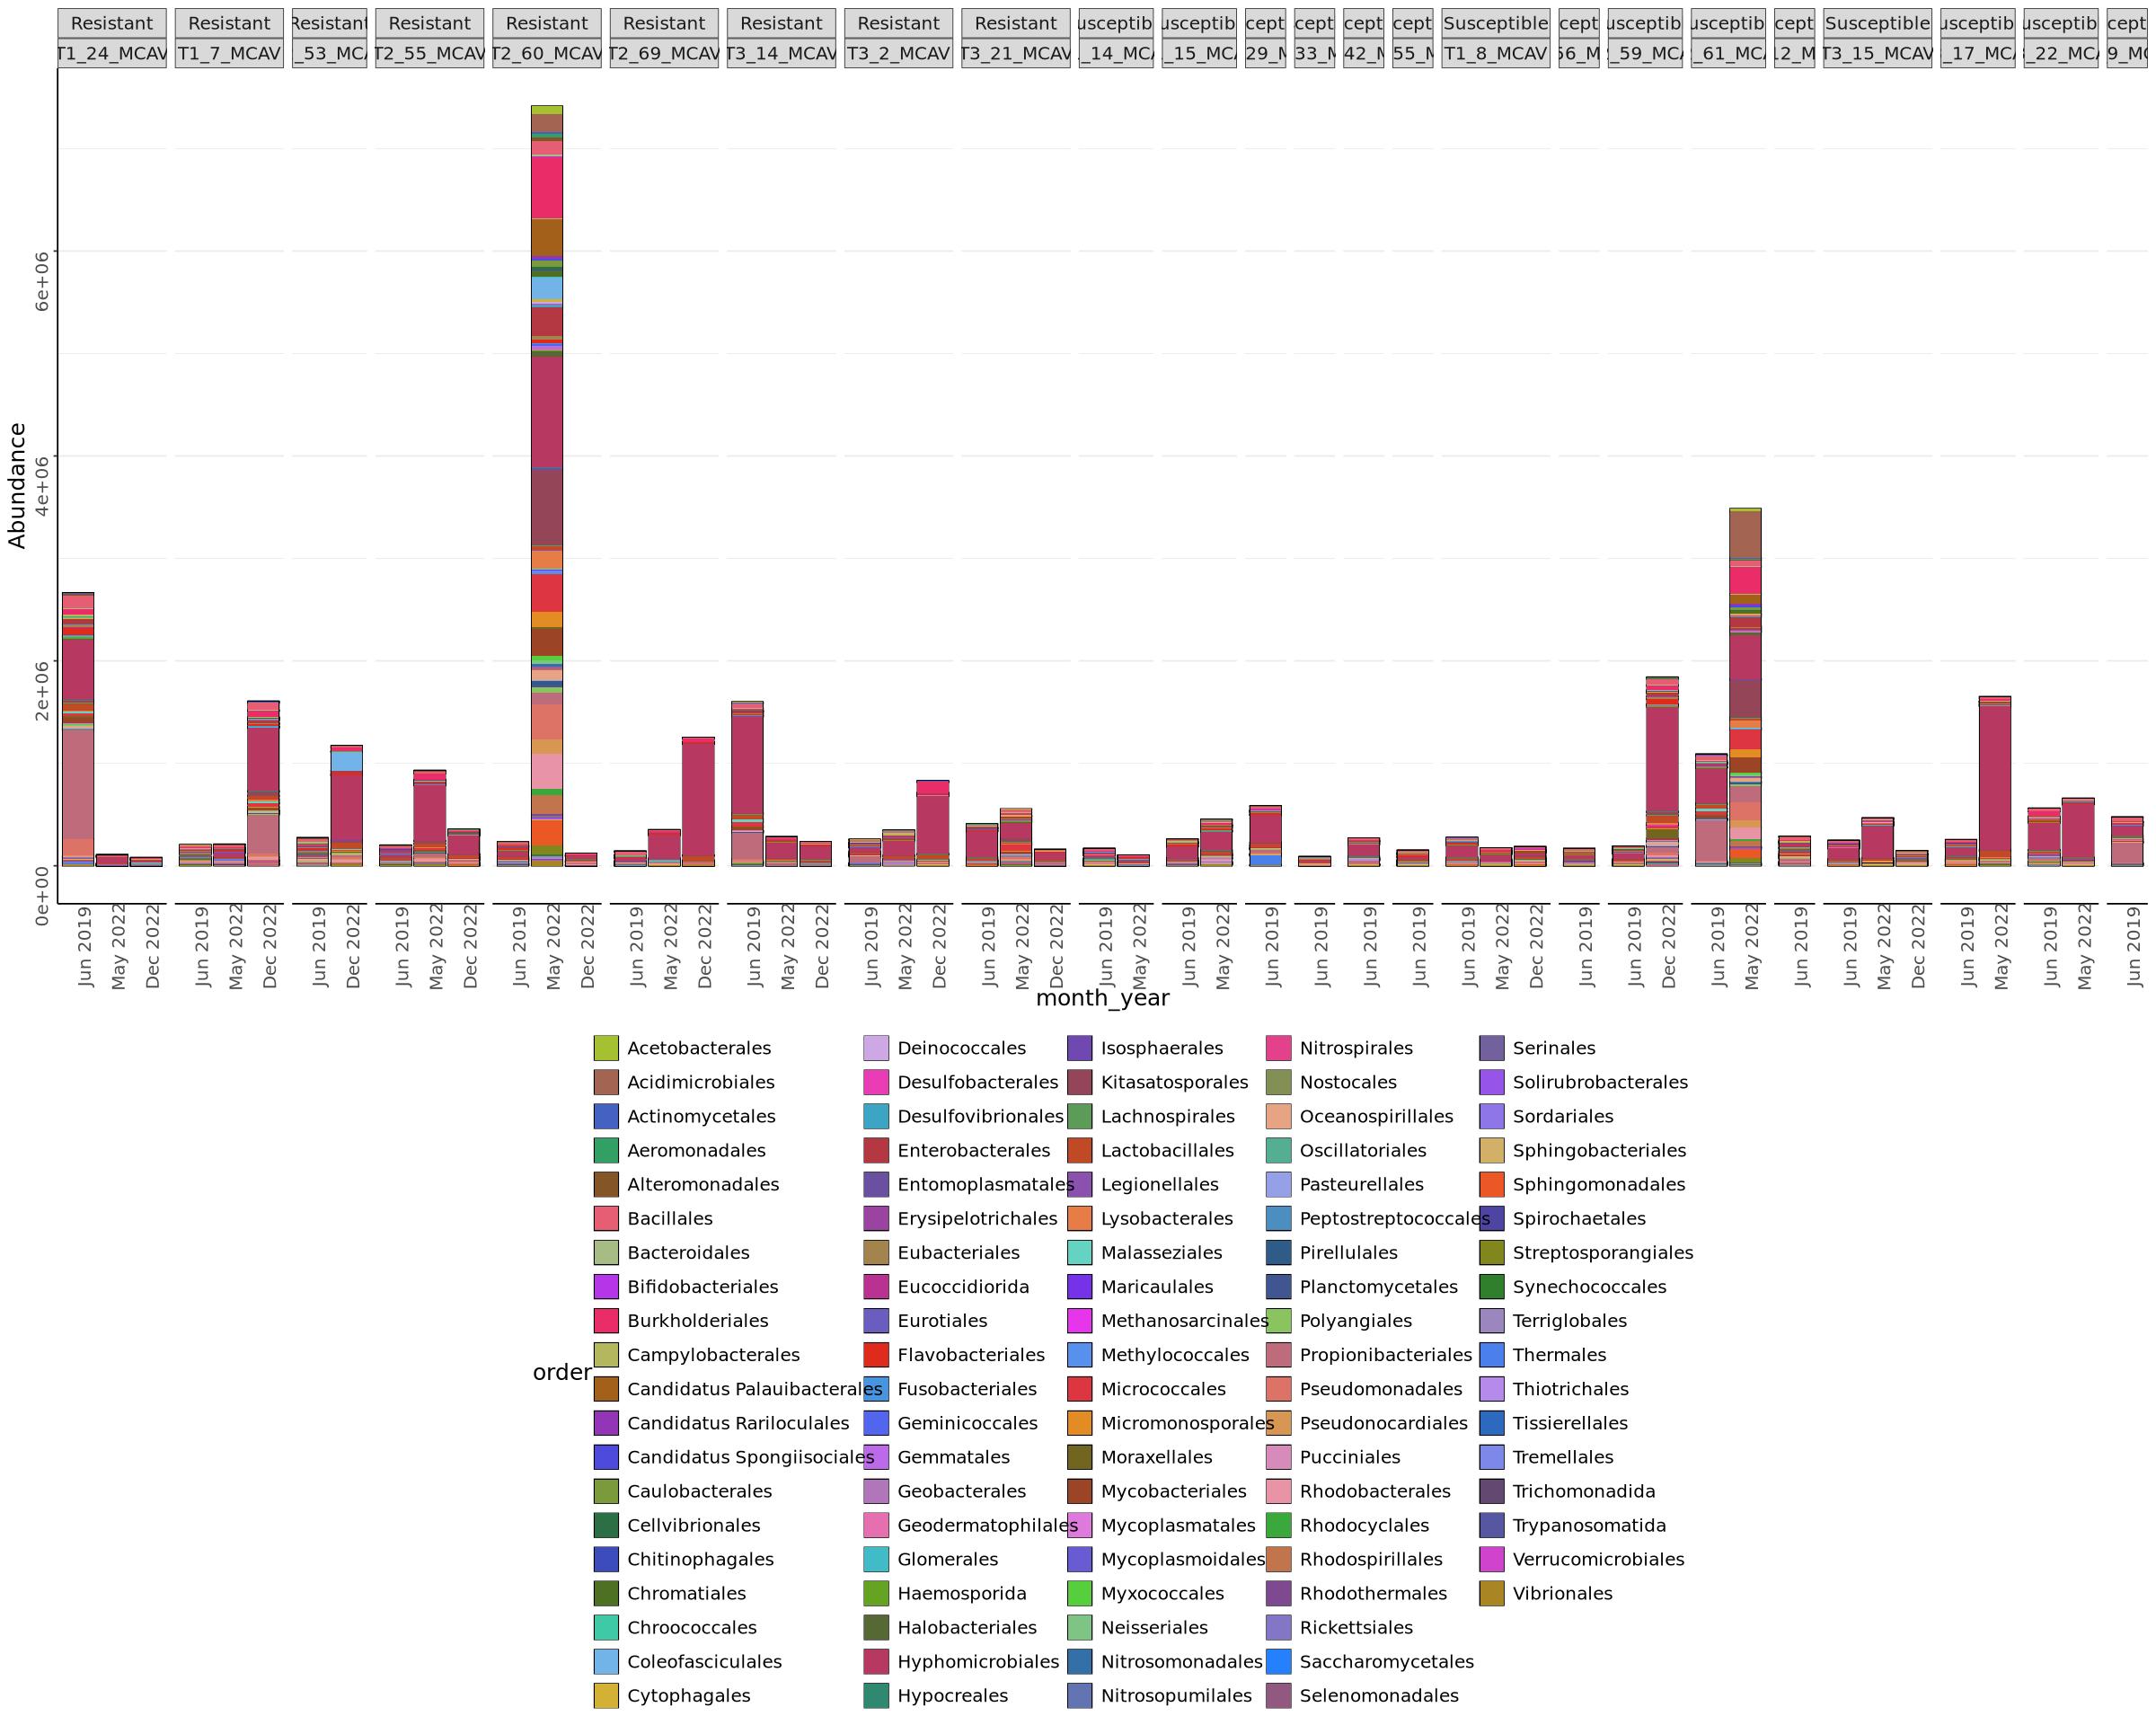

In [86]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 100 order

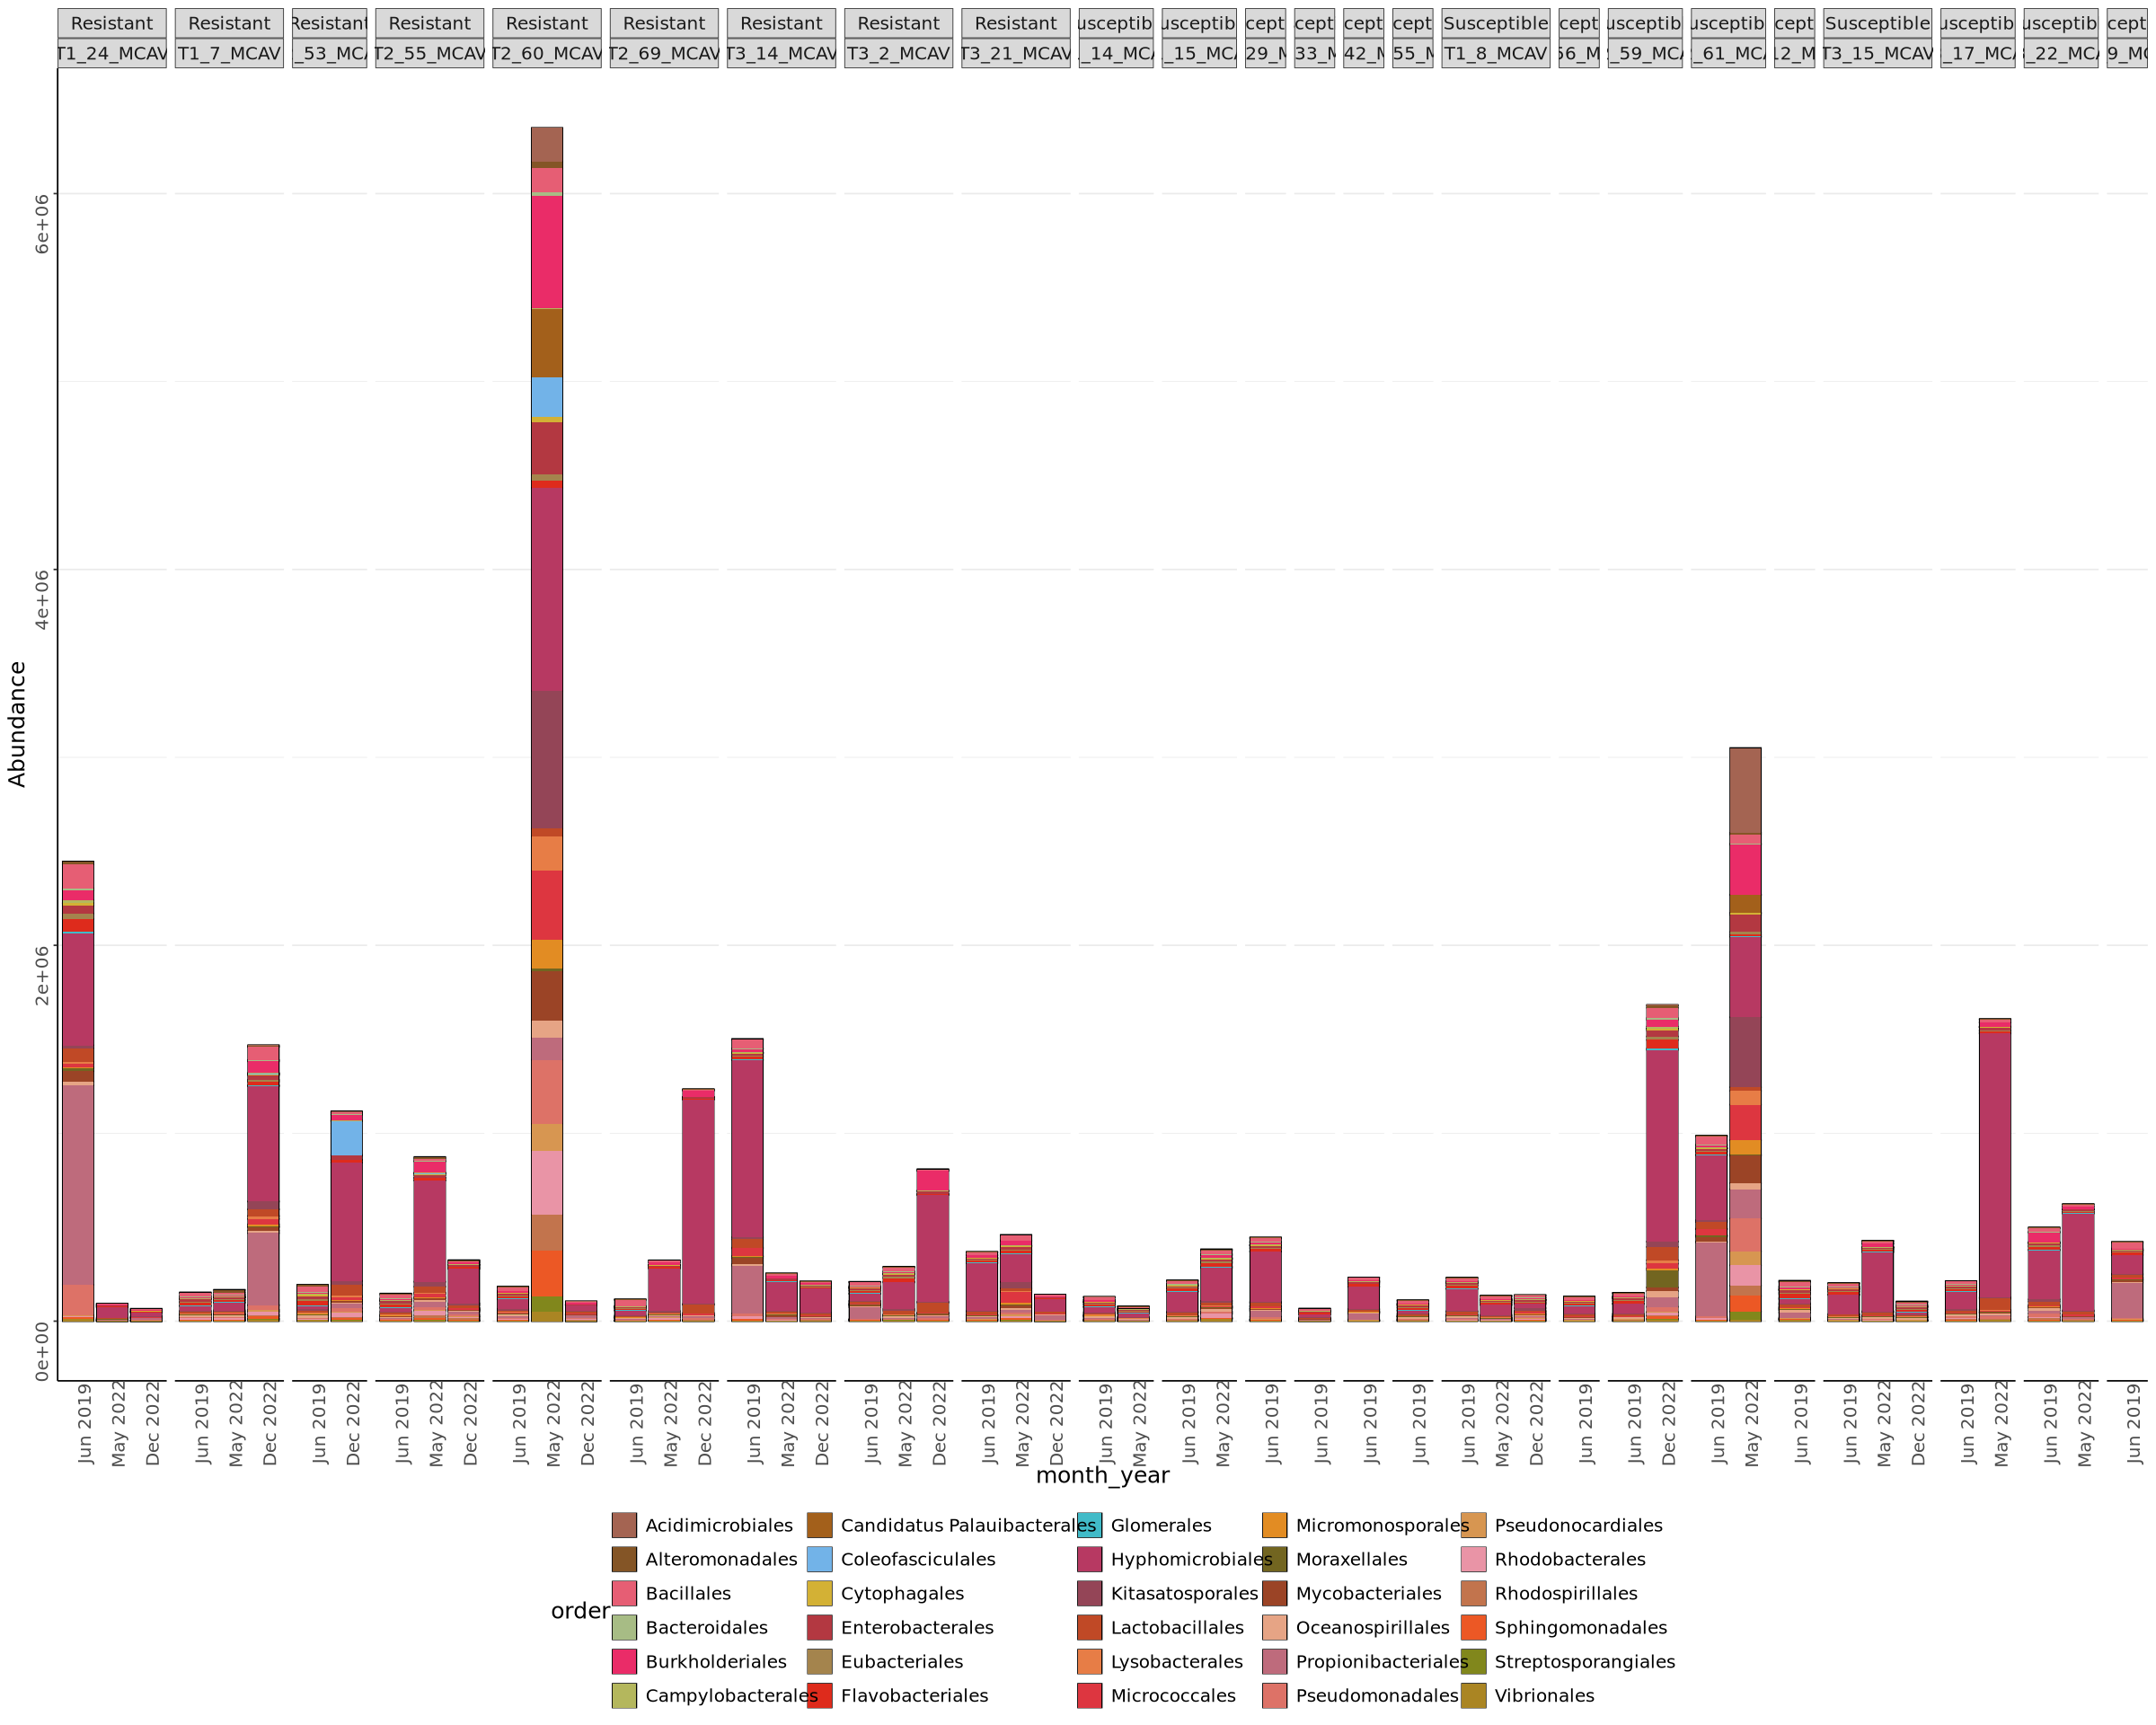

In [87]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_30,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 30 order

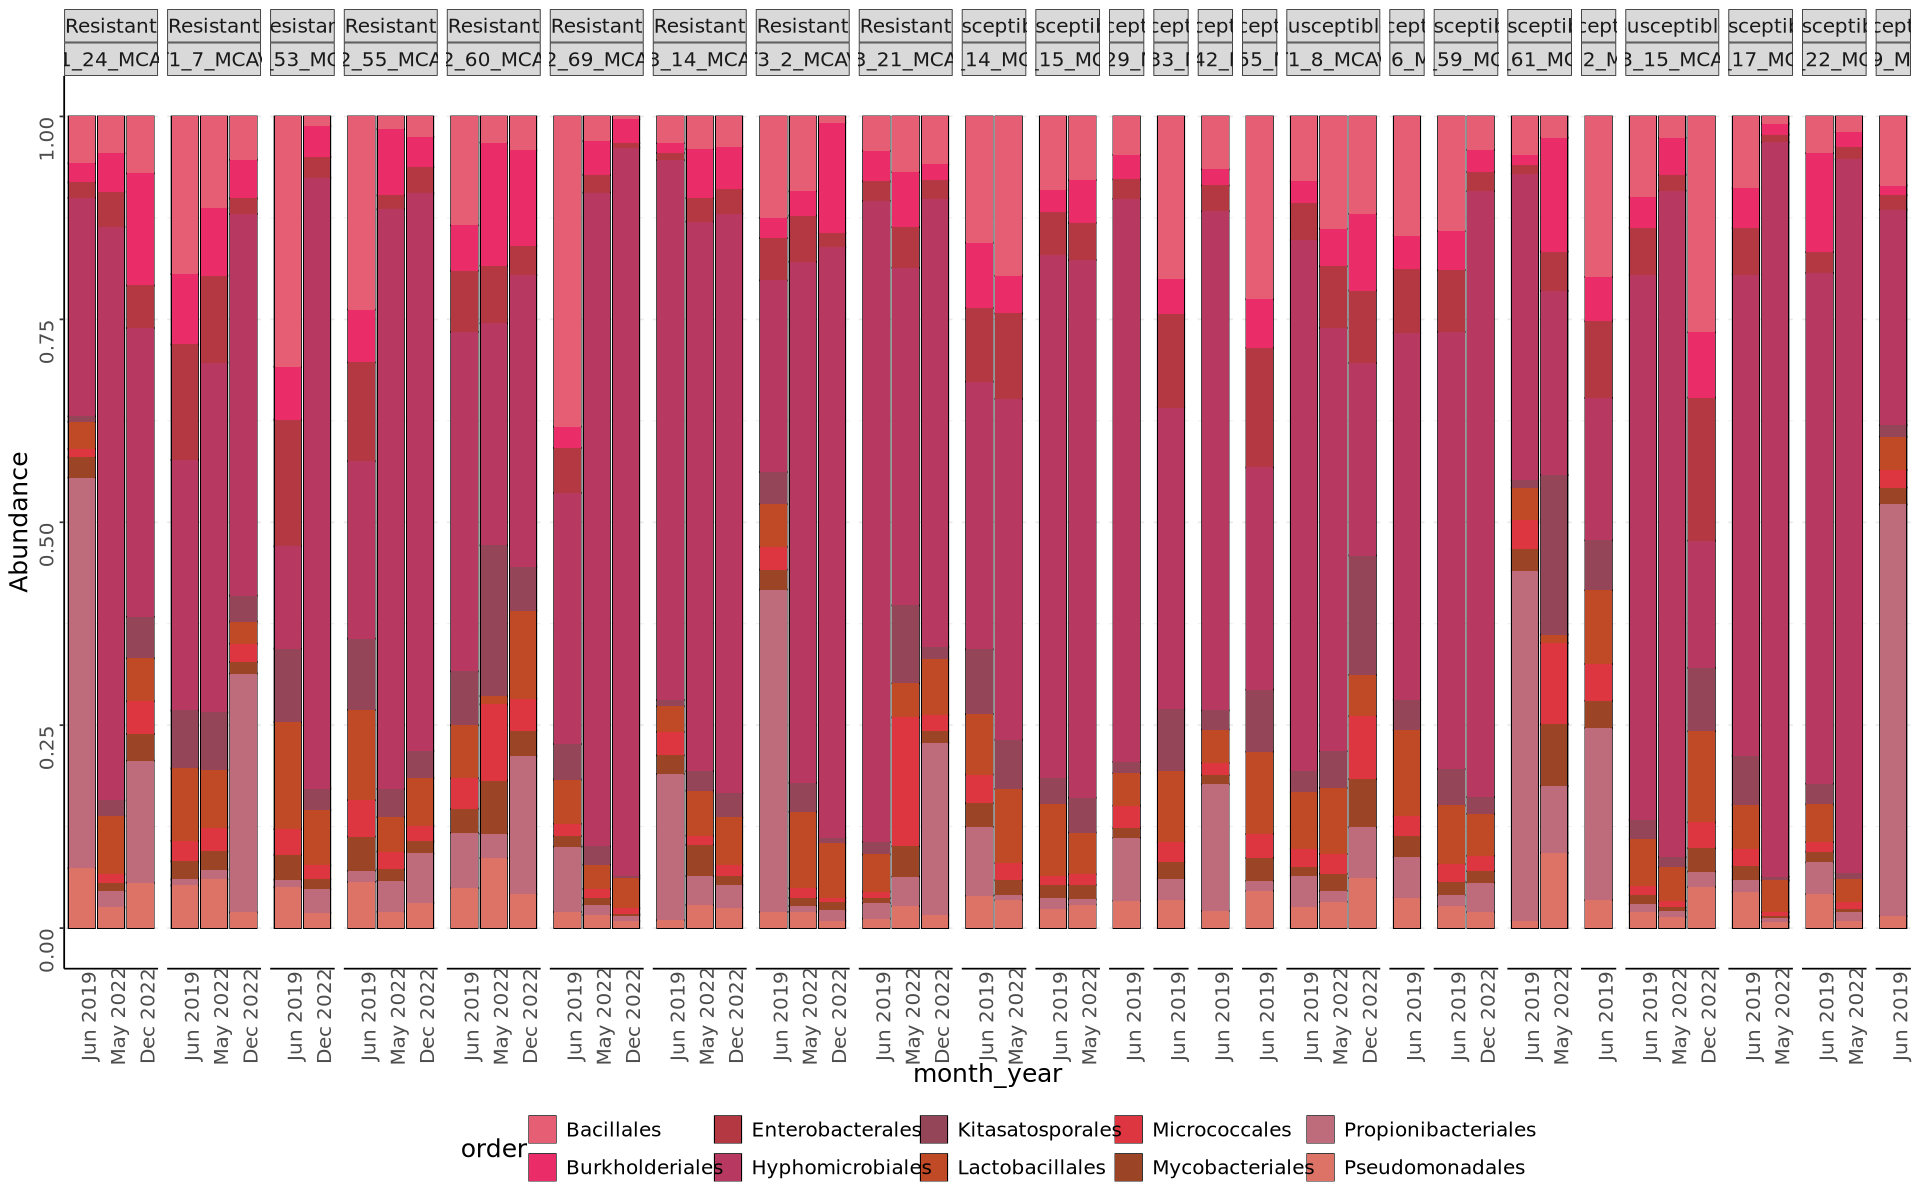

In [88]:
# top 10 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_10_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (order)

In [89]:
# repeat other spp 

#### PSTR --------------------------------------------------------------------------------

In [90]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [91]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(sctld_raw, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

# top 100 order
PSTR_100 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:100]), subset_PSTR)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))
# top 30 order
PSTR_30 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:30]), subset_PSTR)
PSTR_30_norm <- transform_sample_counts(PSTR_30, function(x) x / sum(x))
# top 10 order
PSTR_10 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:10]), subset_PSTR)
PSTR_10_norm <- transform_sample_counts(PSTR_10, function(x) x / sum(x))

In [92]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [93]:
# reorder colonies
PSTR_g_S<-subset_samples(subset_PSTR, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

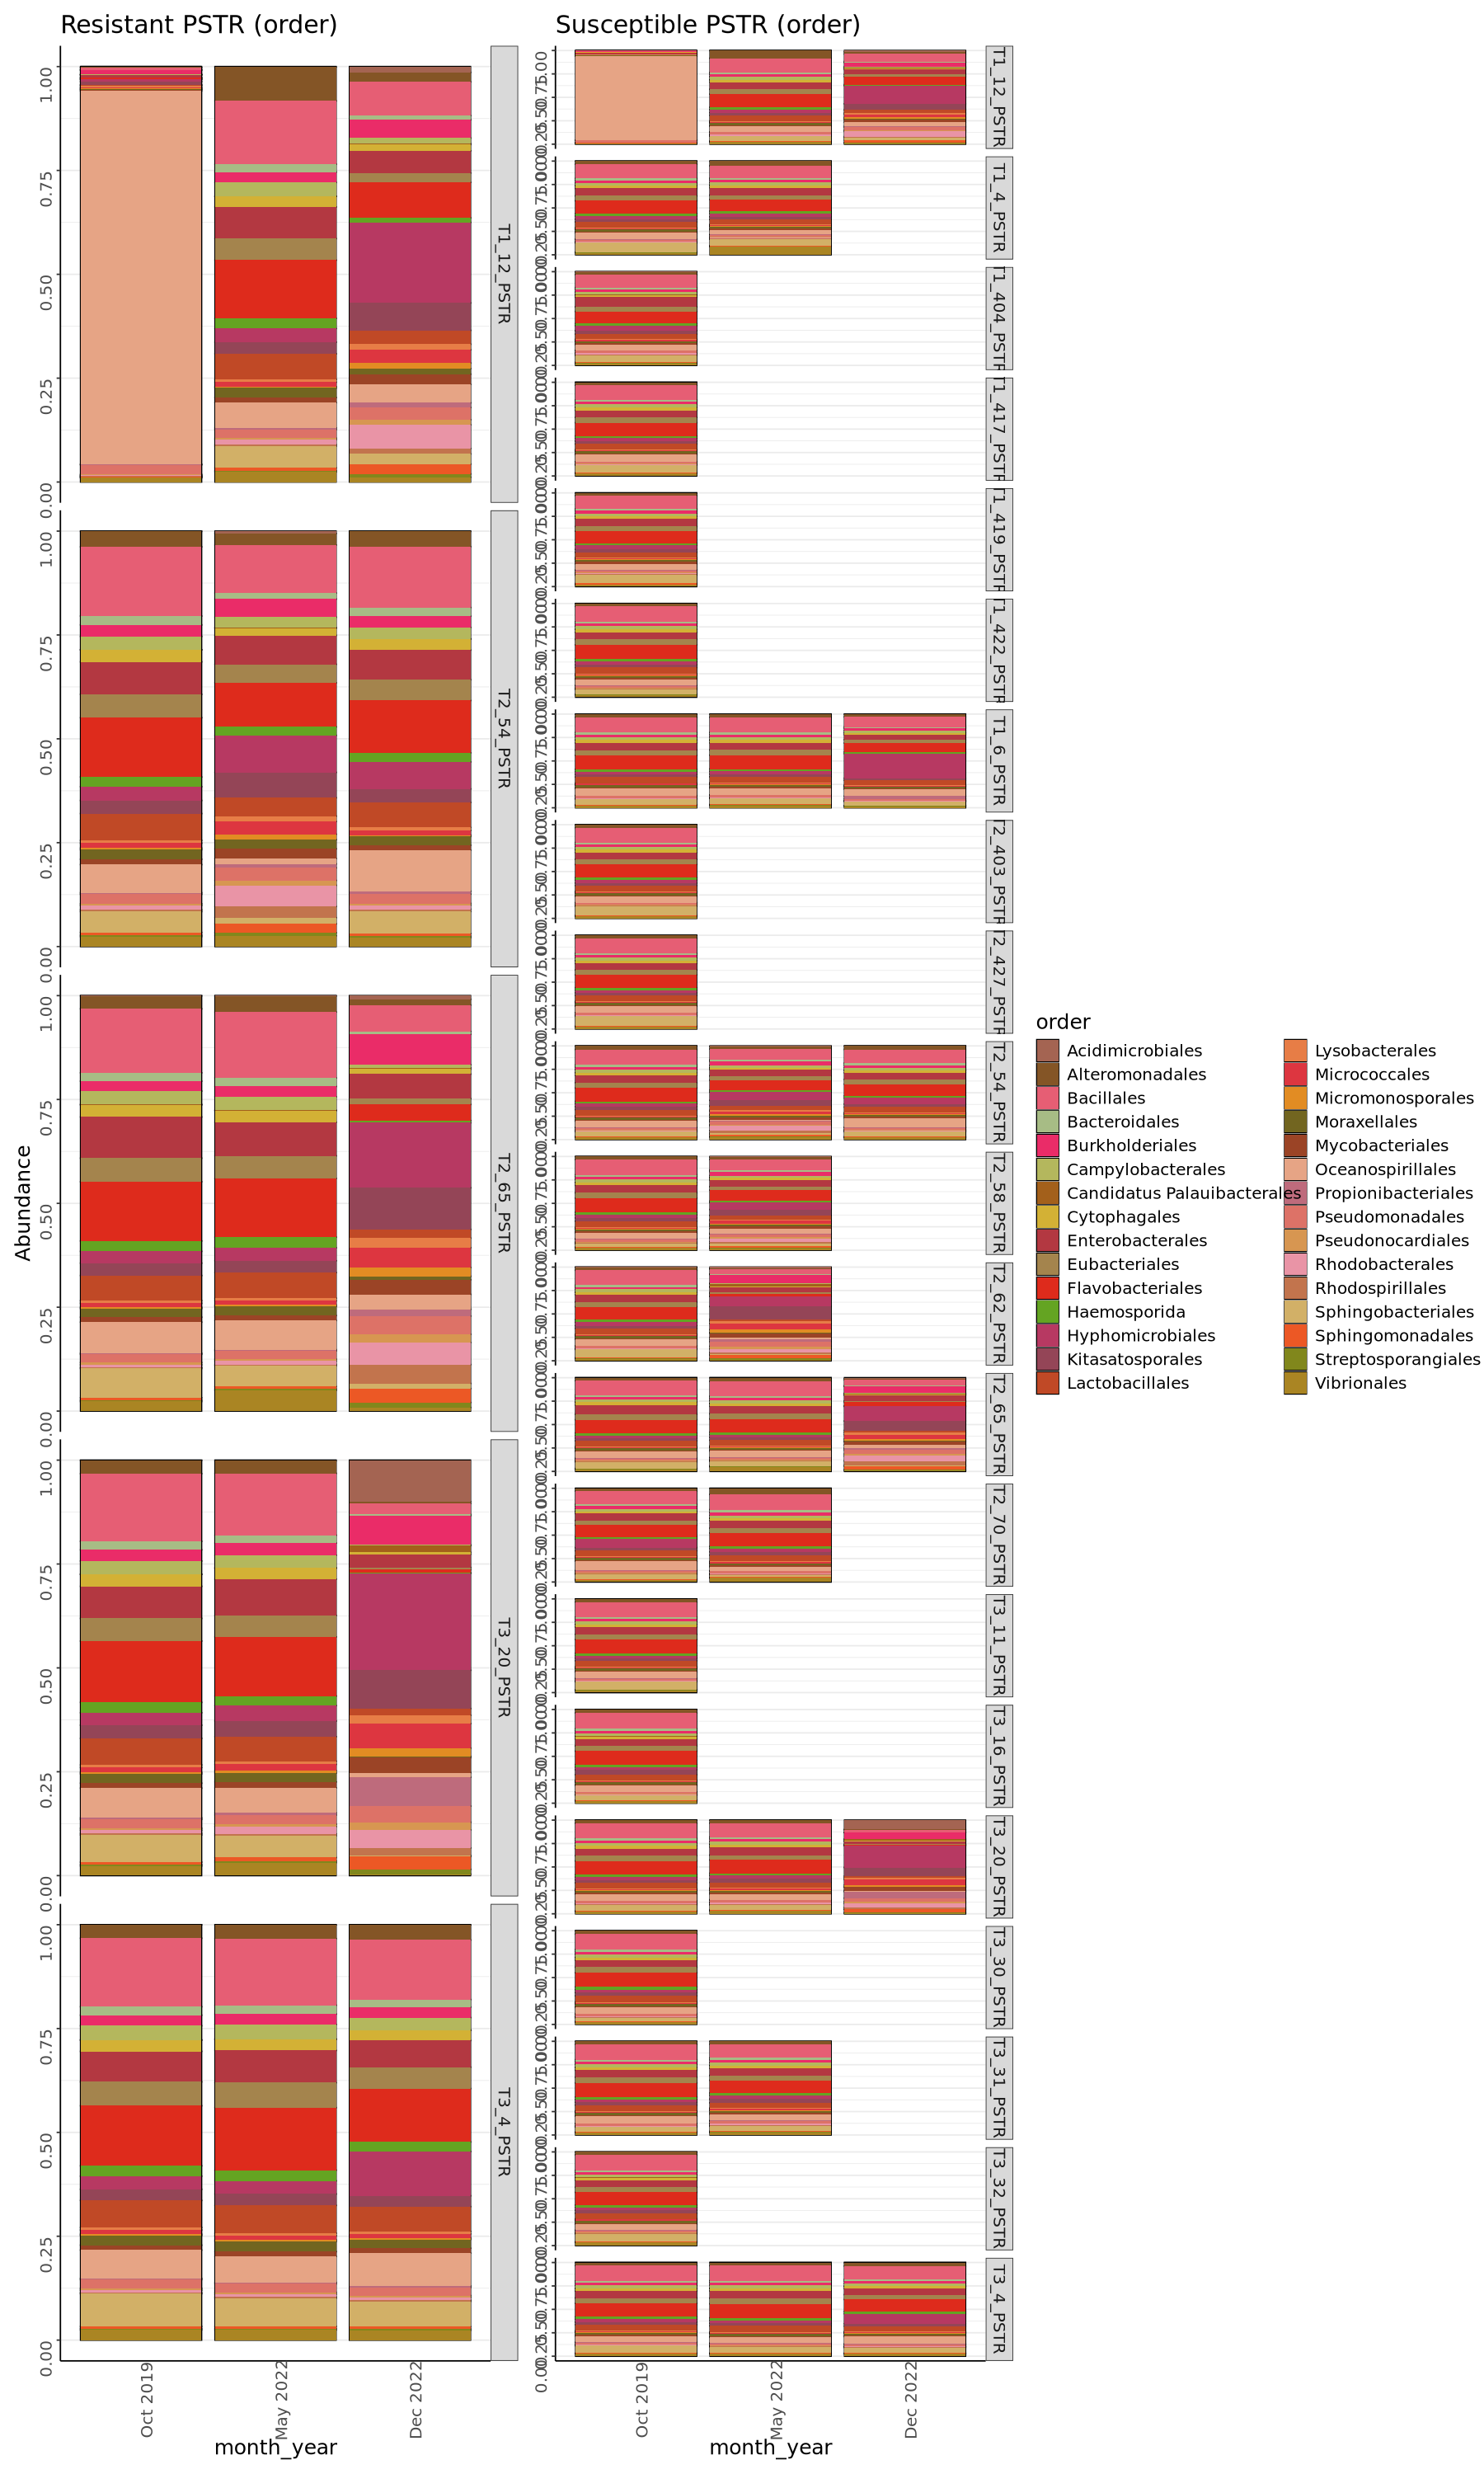

In [94]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_30_norm, RS == "Resistant"),x = "month_year", fill = "order")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (order)")
p_S <- plot_bar(PSTR_30_norm,x = "month_year", fill = "order") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (order)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PSTR colonies") &
  theme(legend.position = "right")
# top 30 order

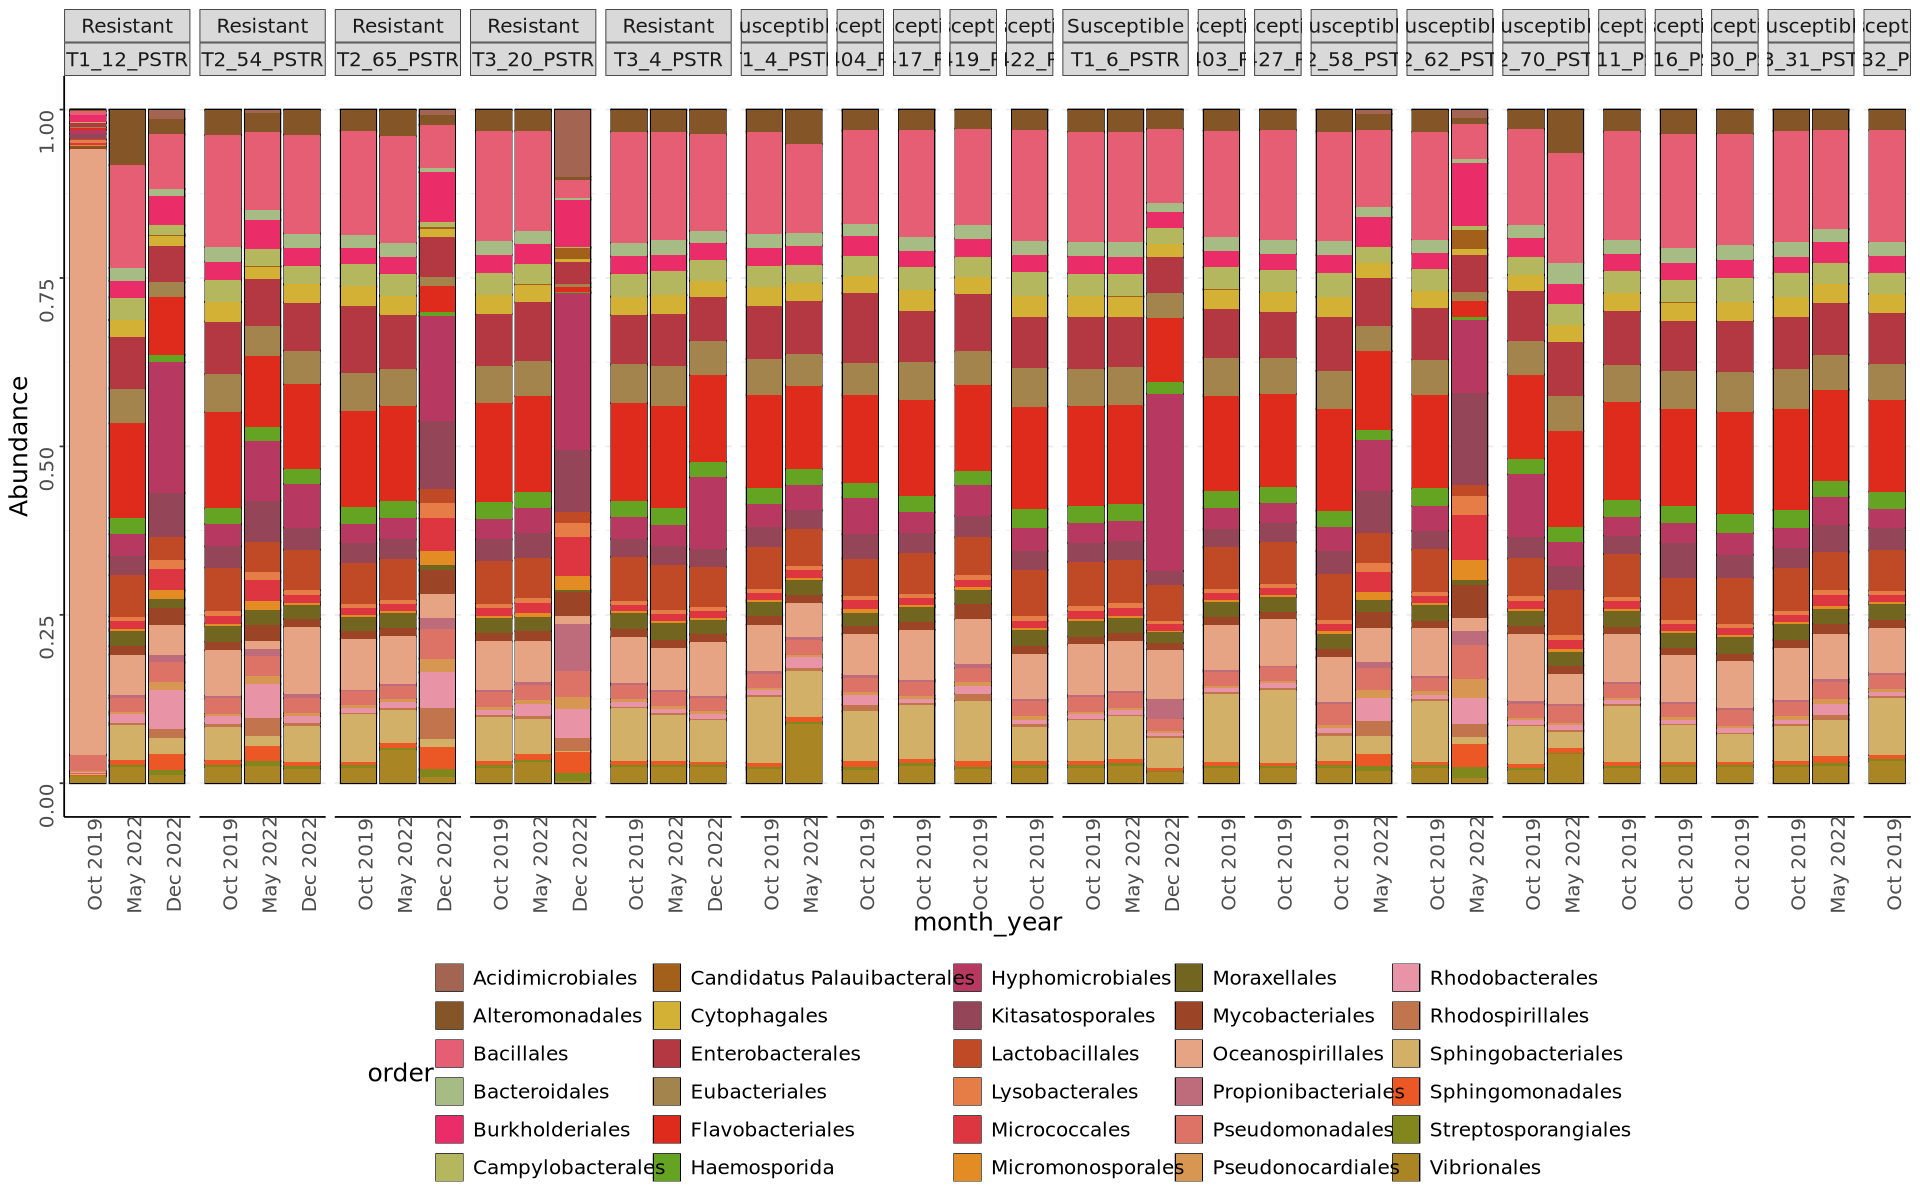

In [95]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 order - R vs S. individuals over time 

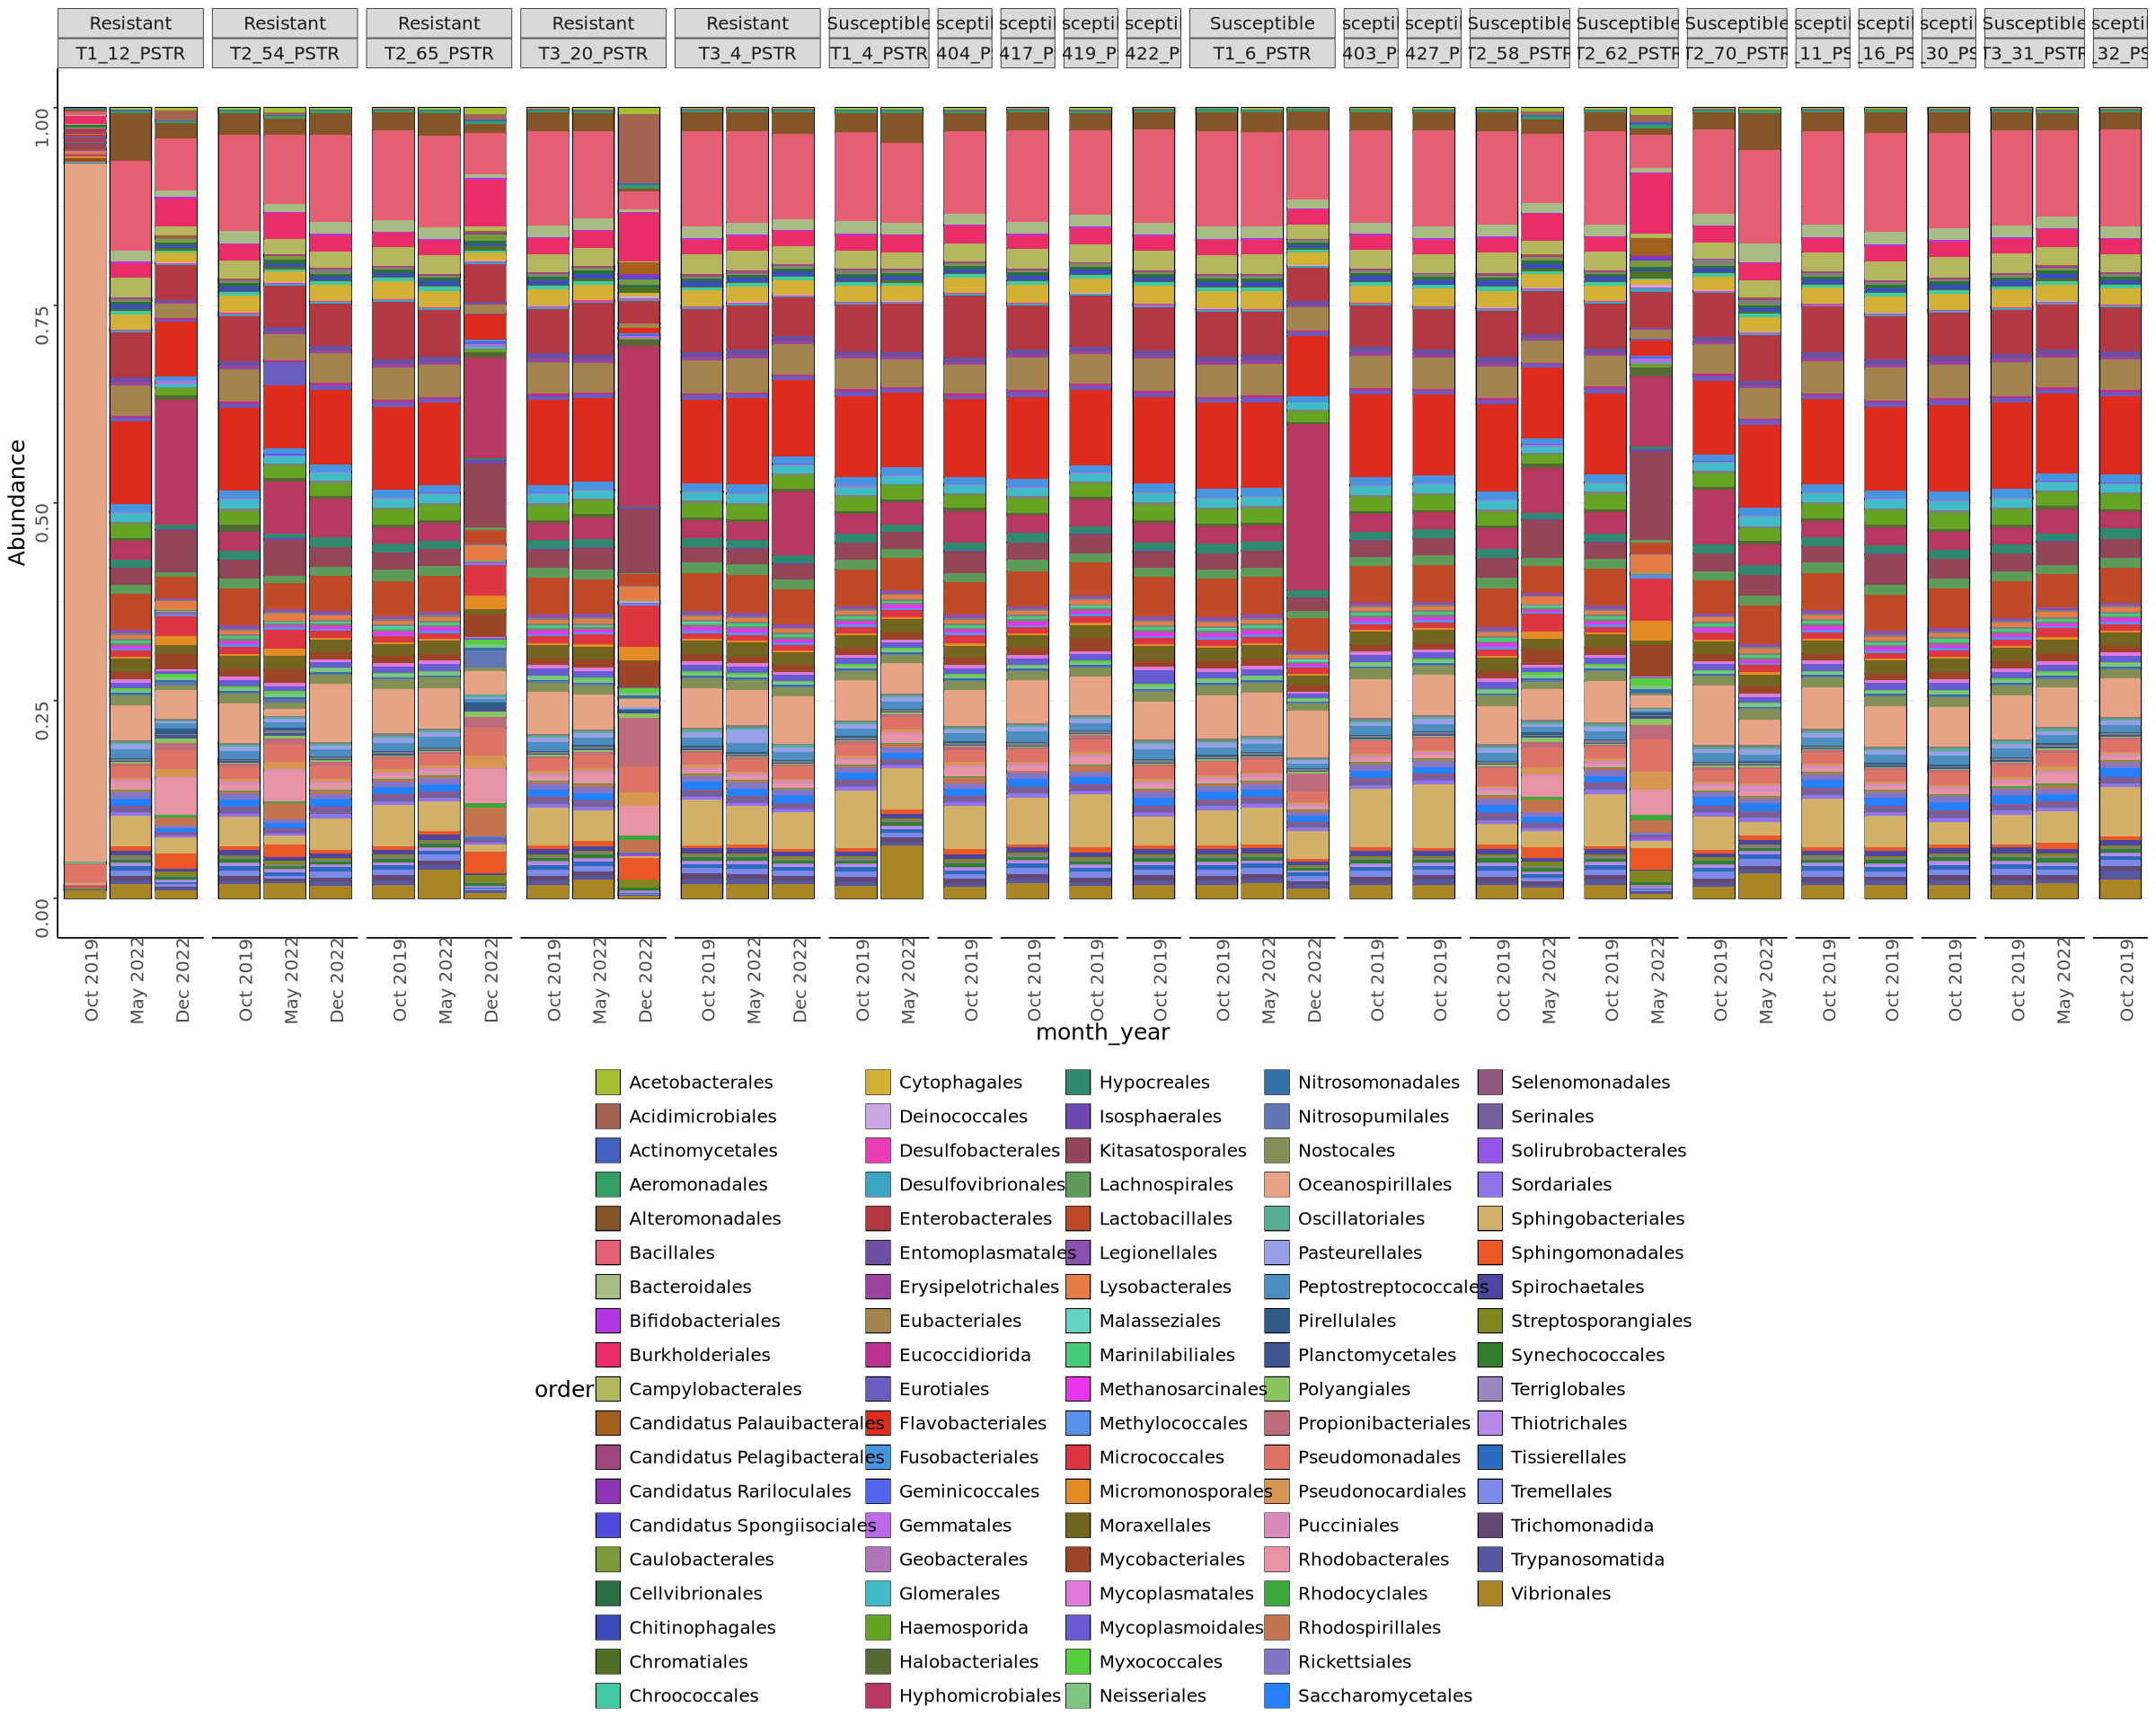

In [96]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (order)

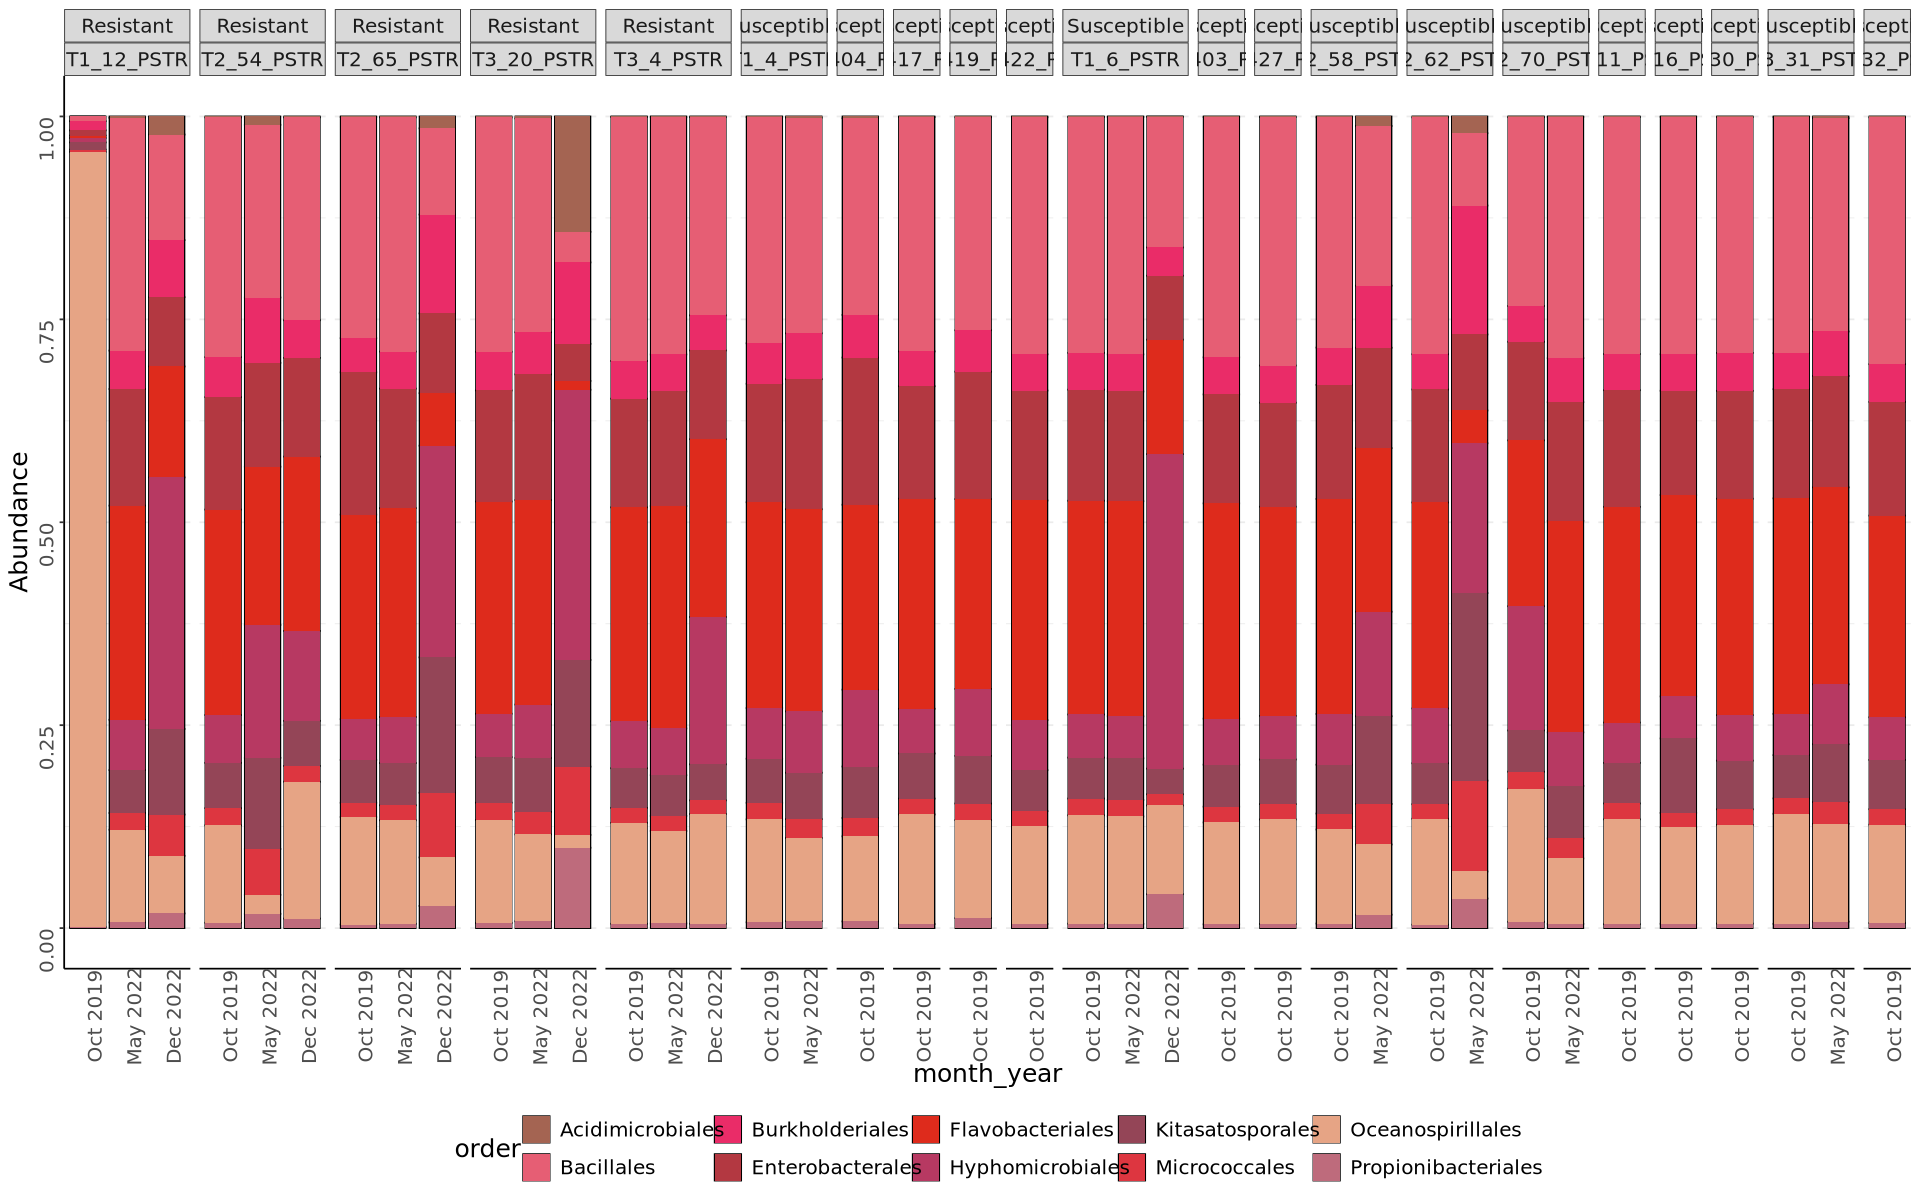

In [97]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_10_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (order)

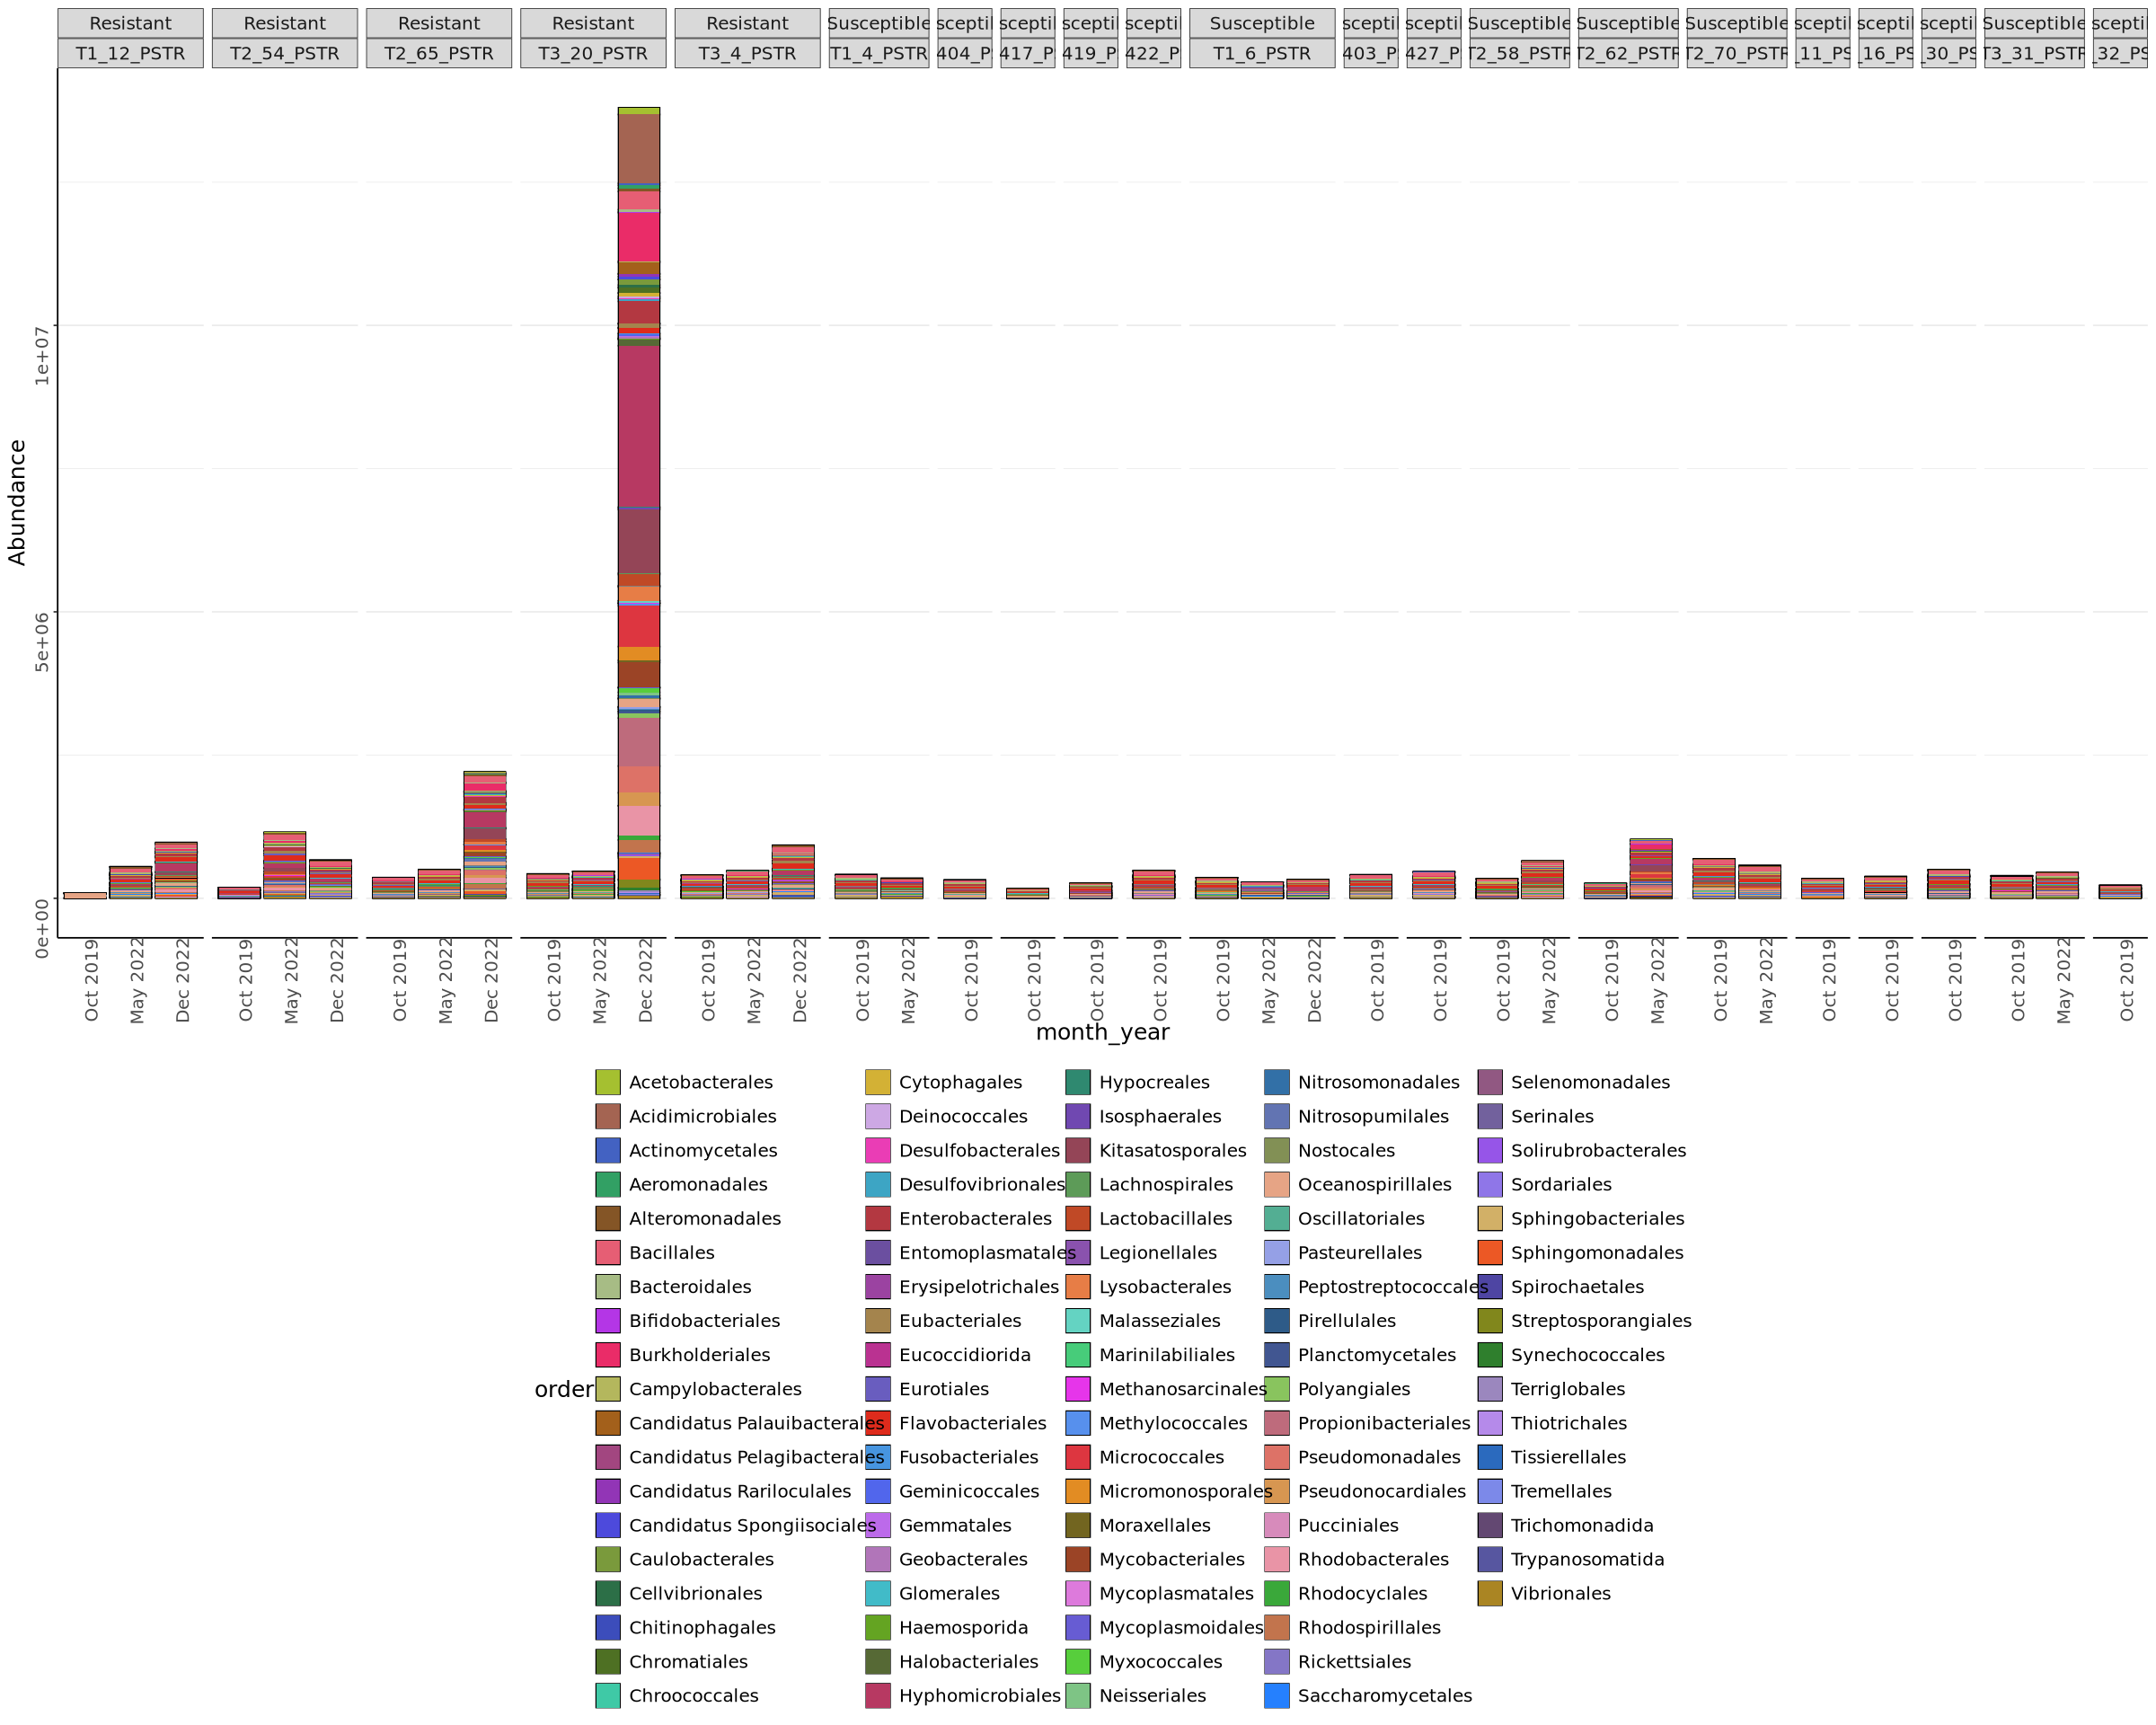

In [98]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (order)

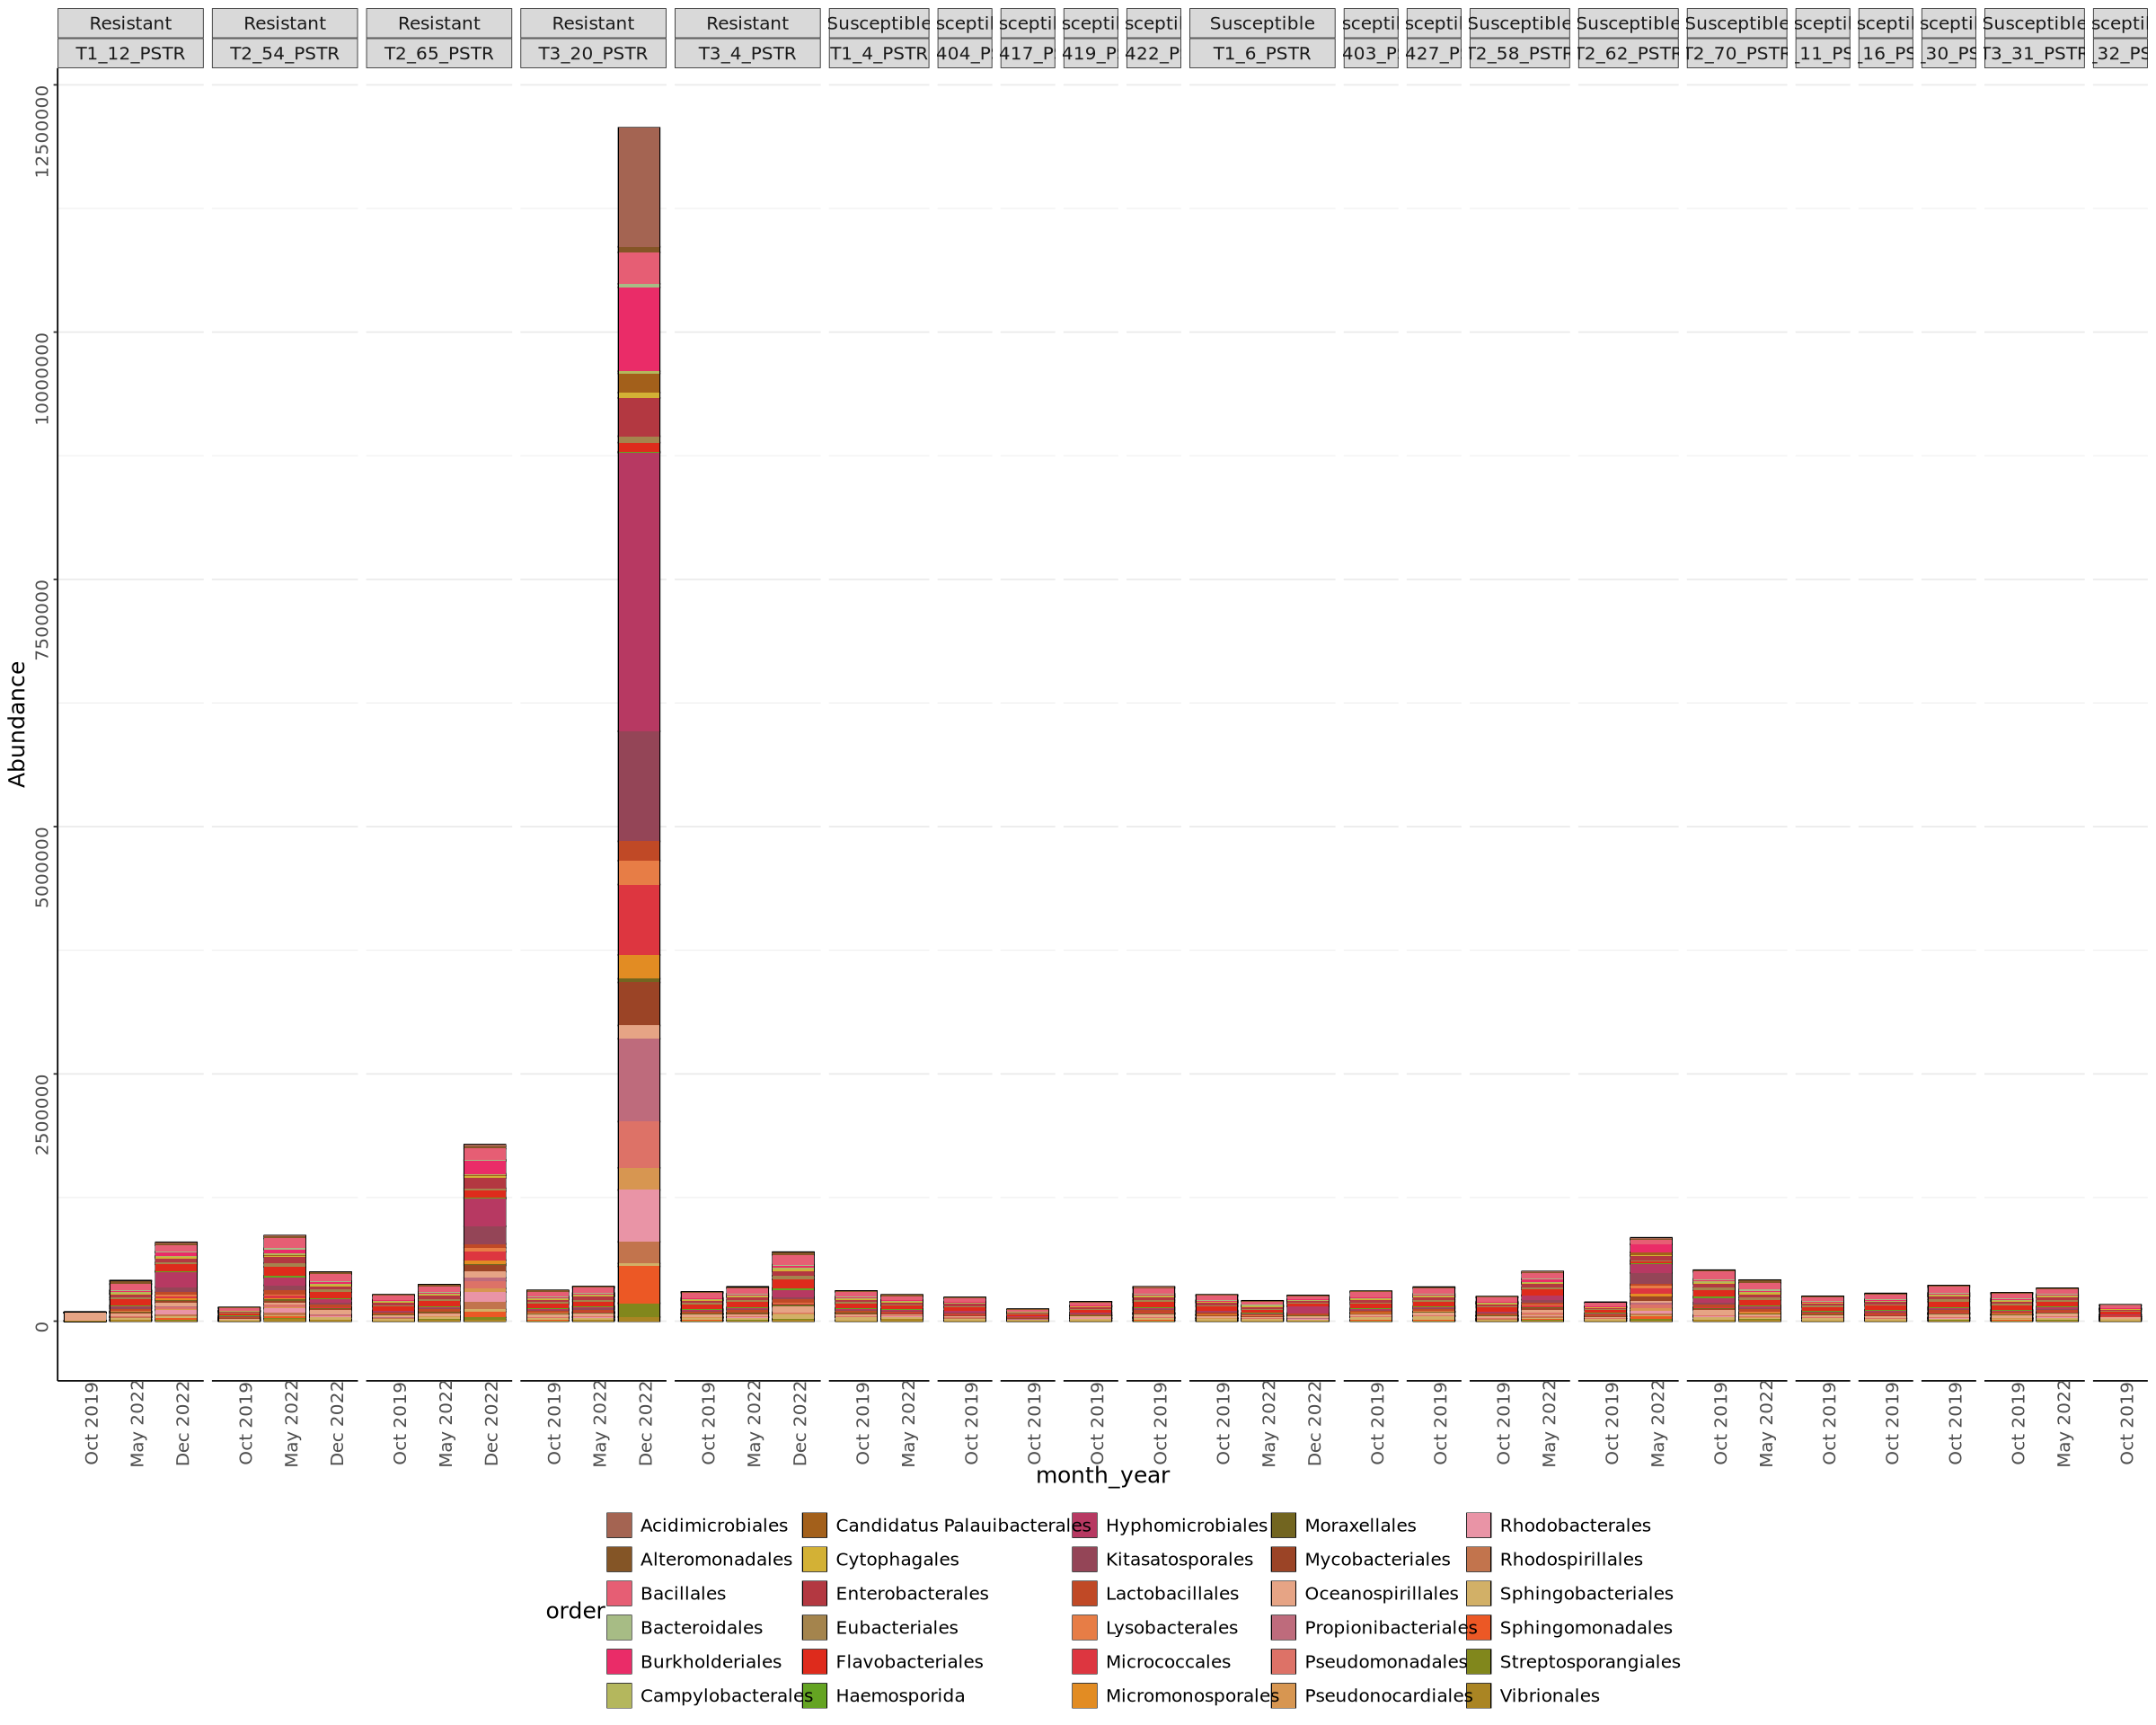

In [99]:

p<-plot_bar(PSTR_30,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (order)

#### MMEA --------------------------------------------------------------------------------

In [100]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [101]:
# mmea

subset_MMEA<- subset_samples(sctld_raw, (Species == "MMEA"))

# top 100 species
MMEA_100 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:100]), subset_MMEA)
MMEA_100_norm <- transform_sample_counts(MMEA_100, function(x) x / sum(x))

MMEA_30 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:30]), subset_MMEA)
MMEA_30_norm <- transform_sample_counts(MMEA_30, function(x) x / sum(x))

# top 10 order
MMEA_10 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:10]), subset_MMEA)
MMEA_10_norm <- transform_sample_counts(MMEA_10, function(x) x / sum(x))

In [102]:
df_meta <- data.frame(sample_data(subset_MMEA))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_MMEA) <- sample_data(df_meta)

In [103]:
# reorder colonies
MMEA_g_S<-subset_samples(subset_MMEA, RS == "Susceptible")
df_meta<-data.frame(sample_data(MMEA_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(subset_MMEA)$colony_id <-
  factor(sample_data(subset_MMEA)$colony_id, levels = col_order)

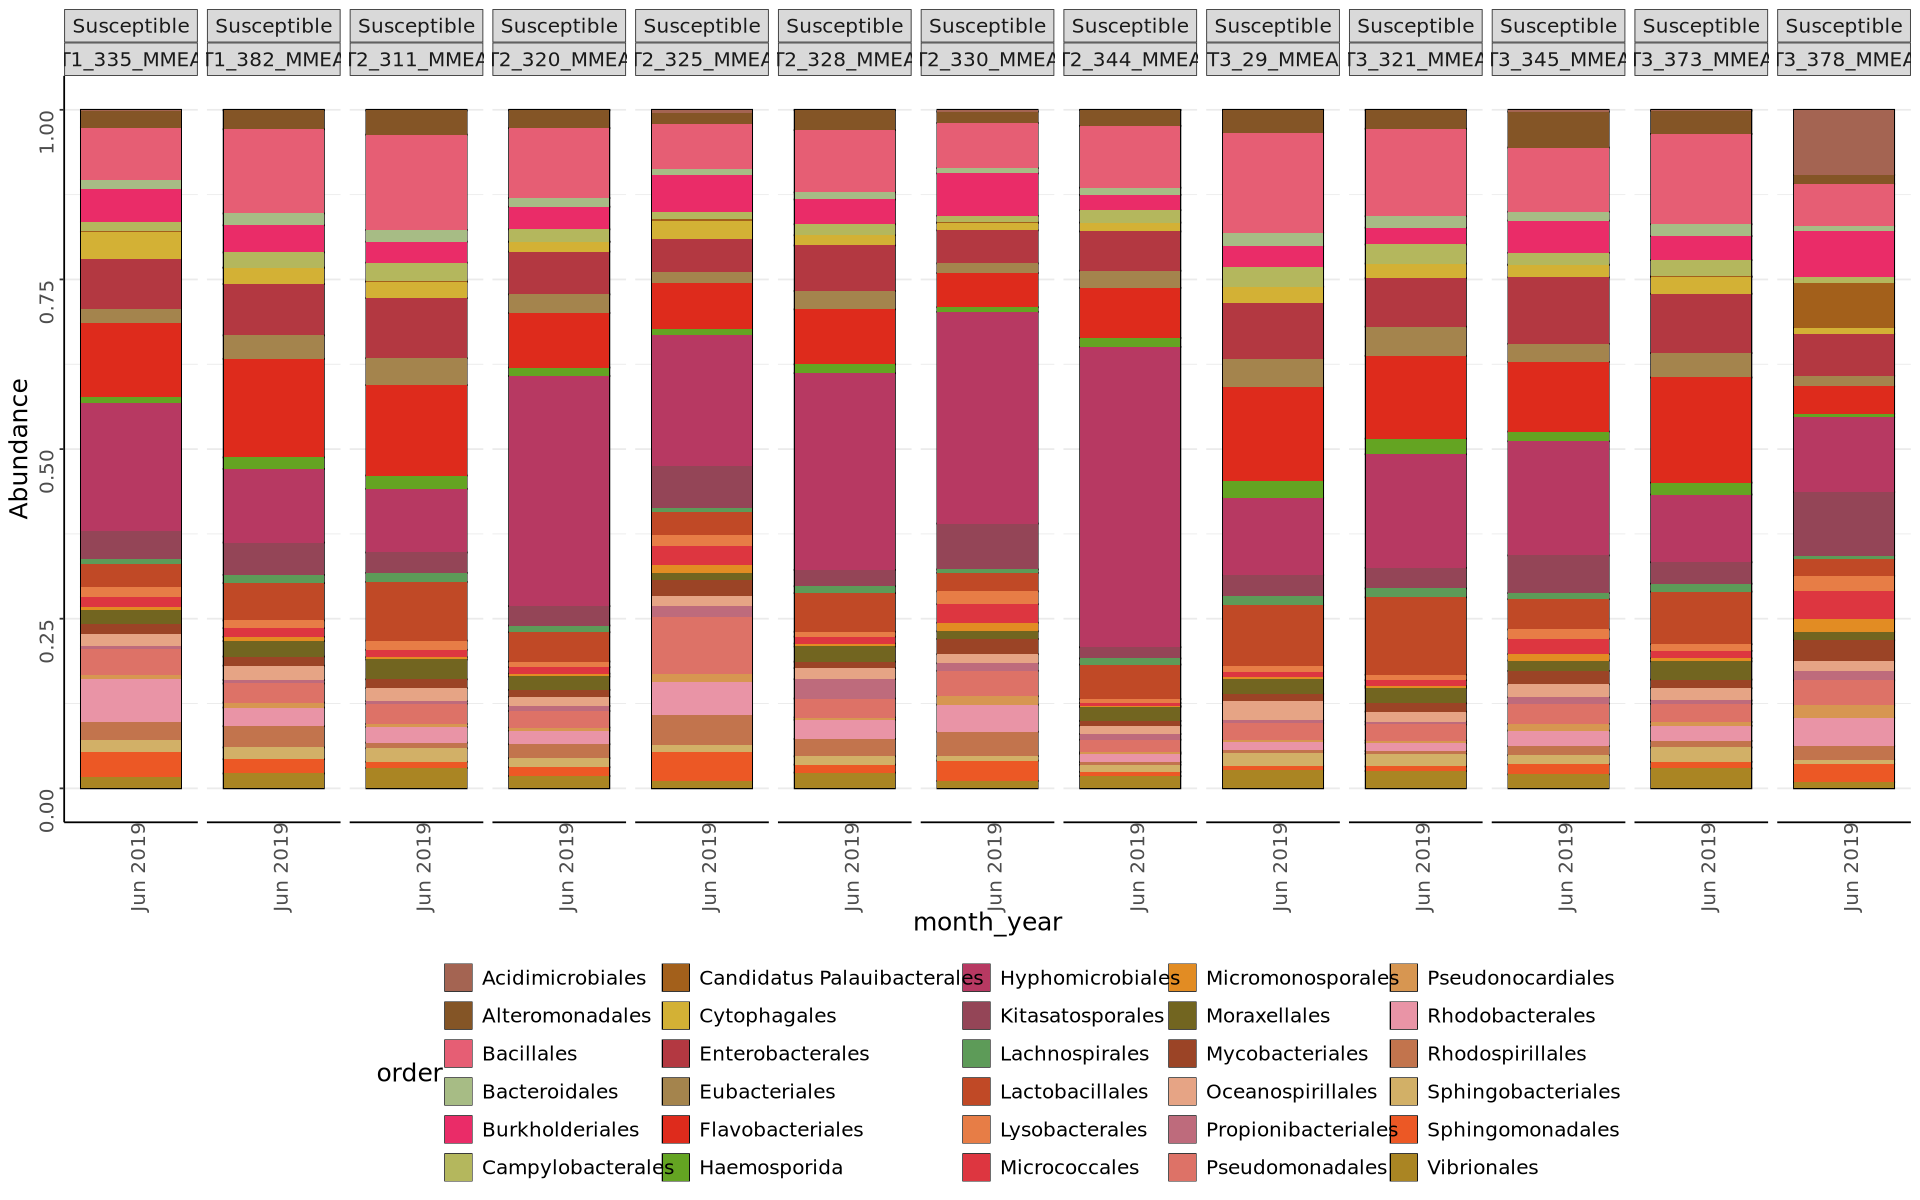

In [104]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_30_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 order - R vs S. individuals over time 

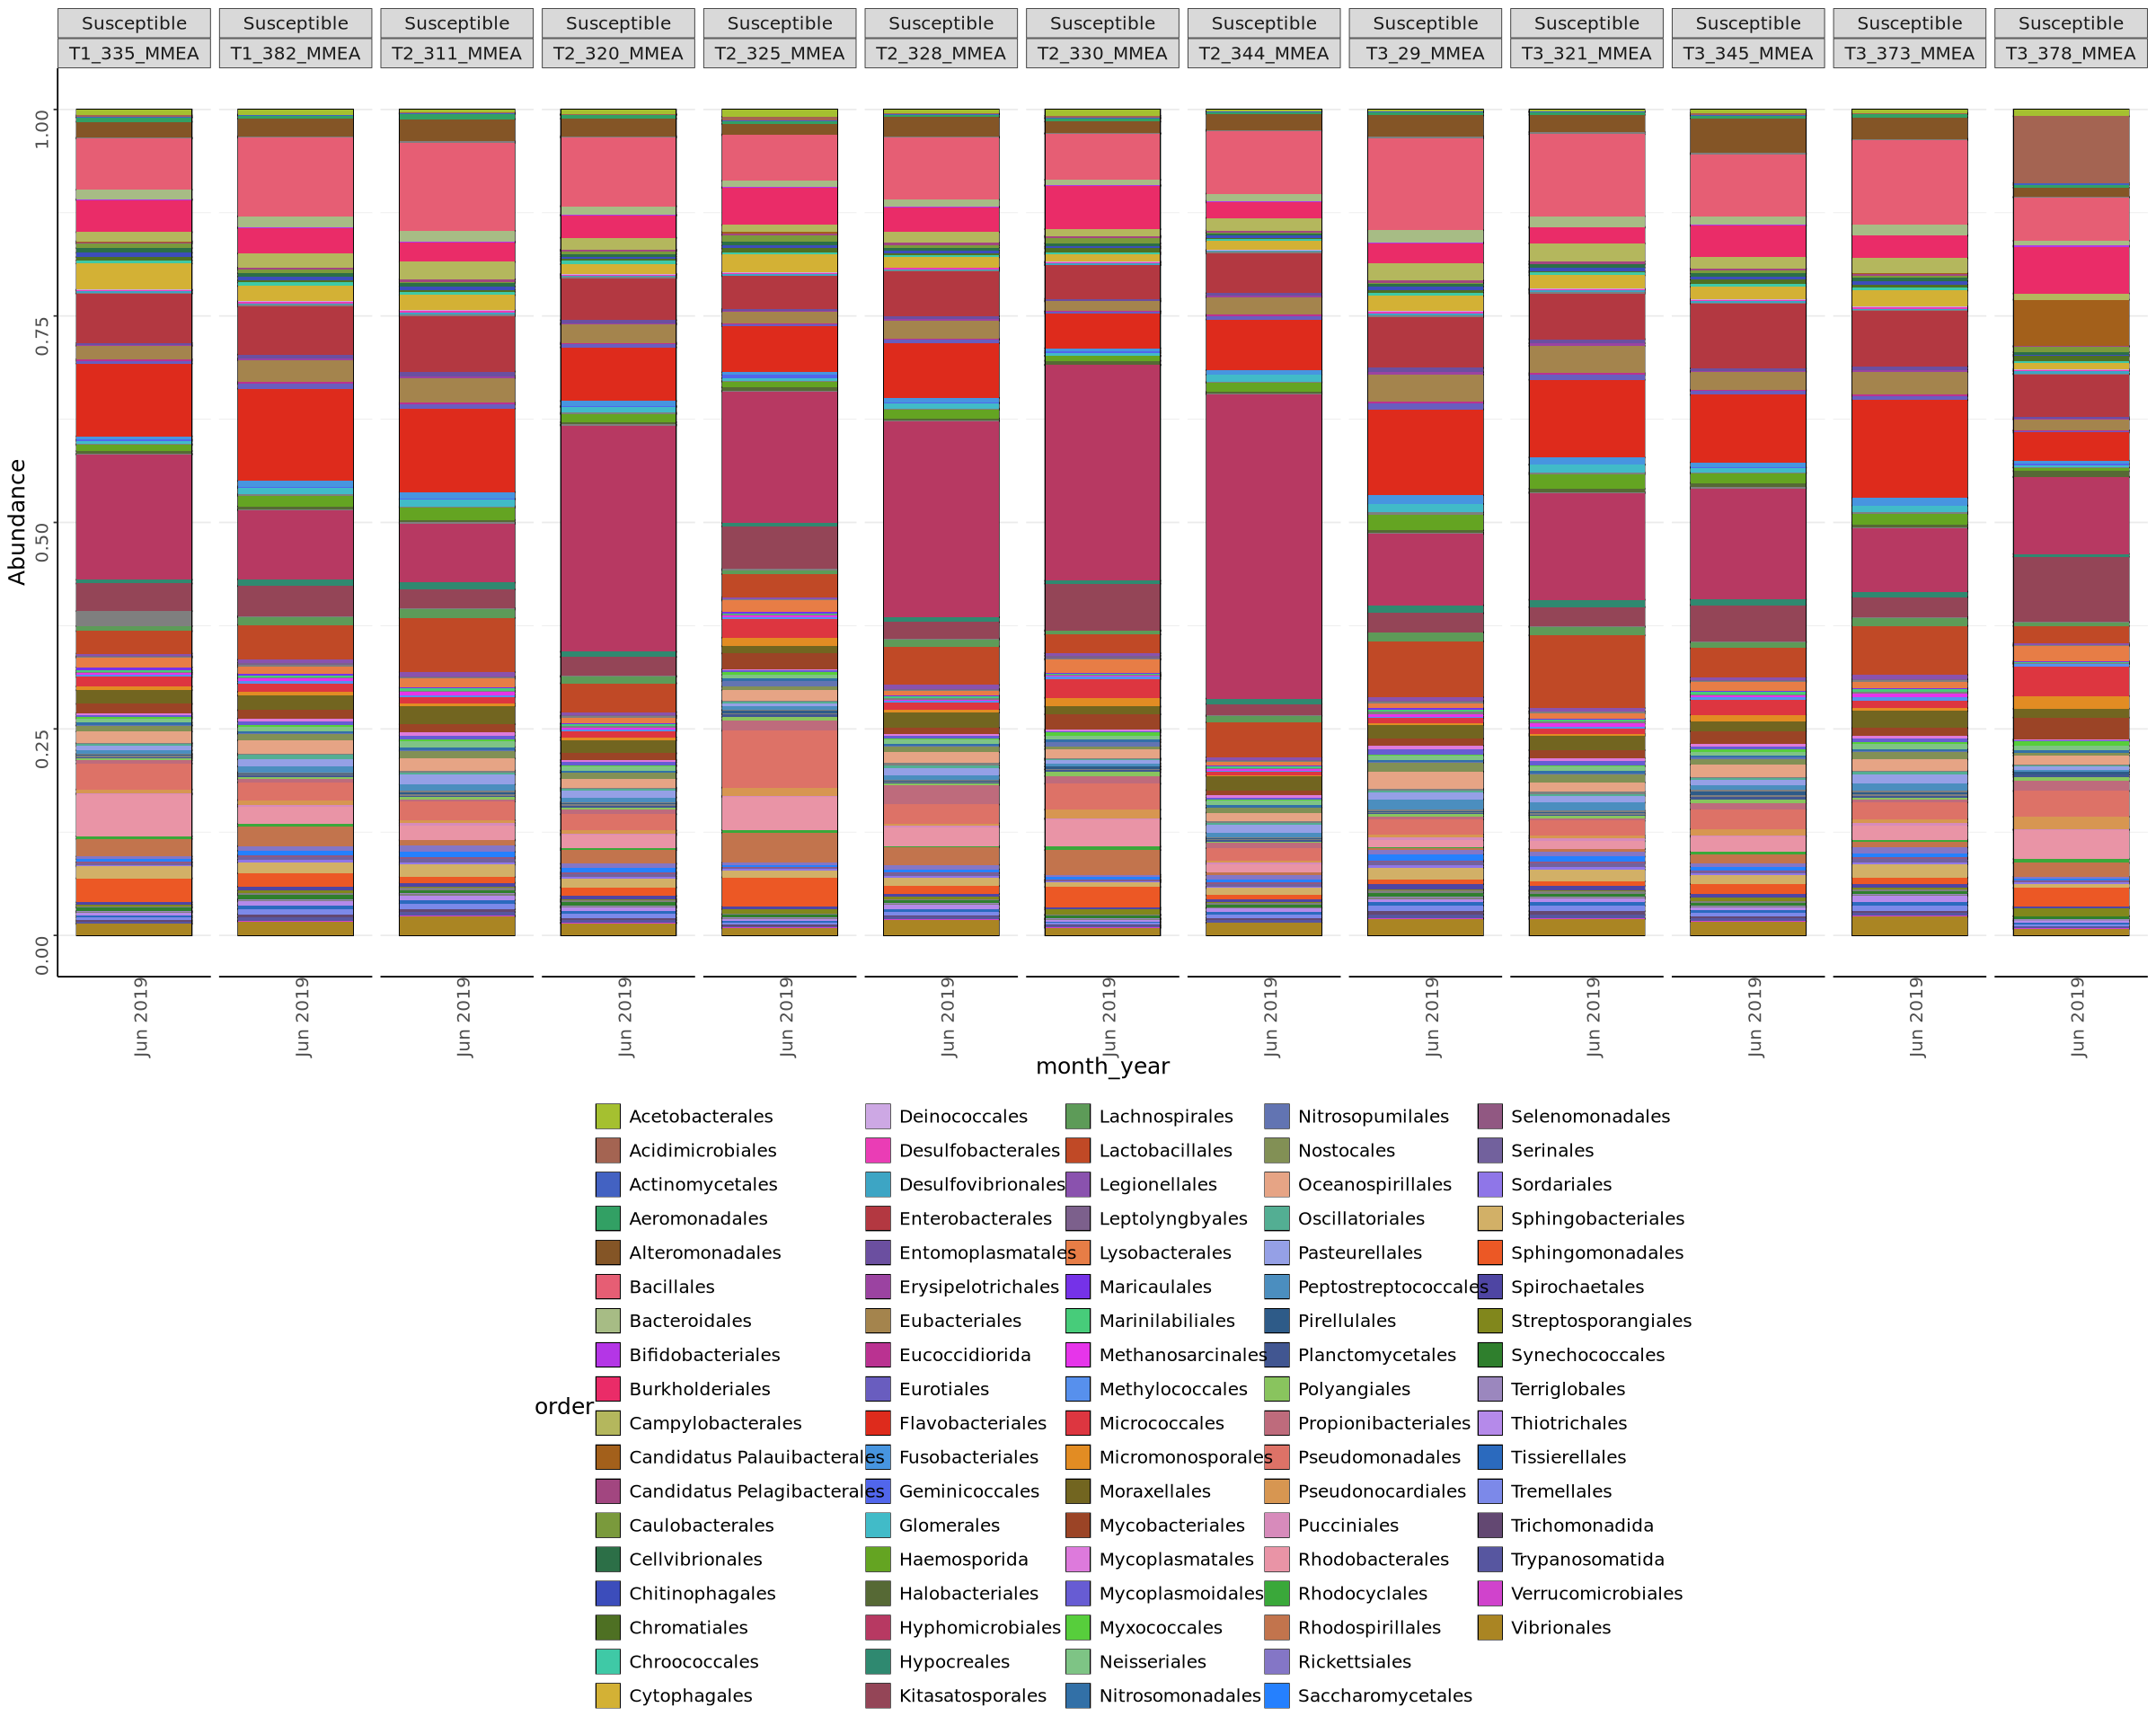

In [105]:
options(repr.plot.height = 16, repr.plot.width = 20)

p<-plot_bar(MMEA_100_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (order)

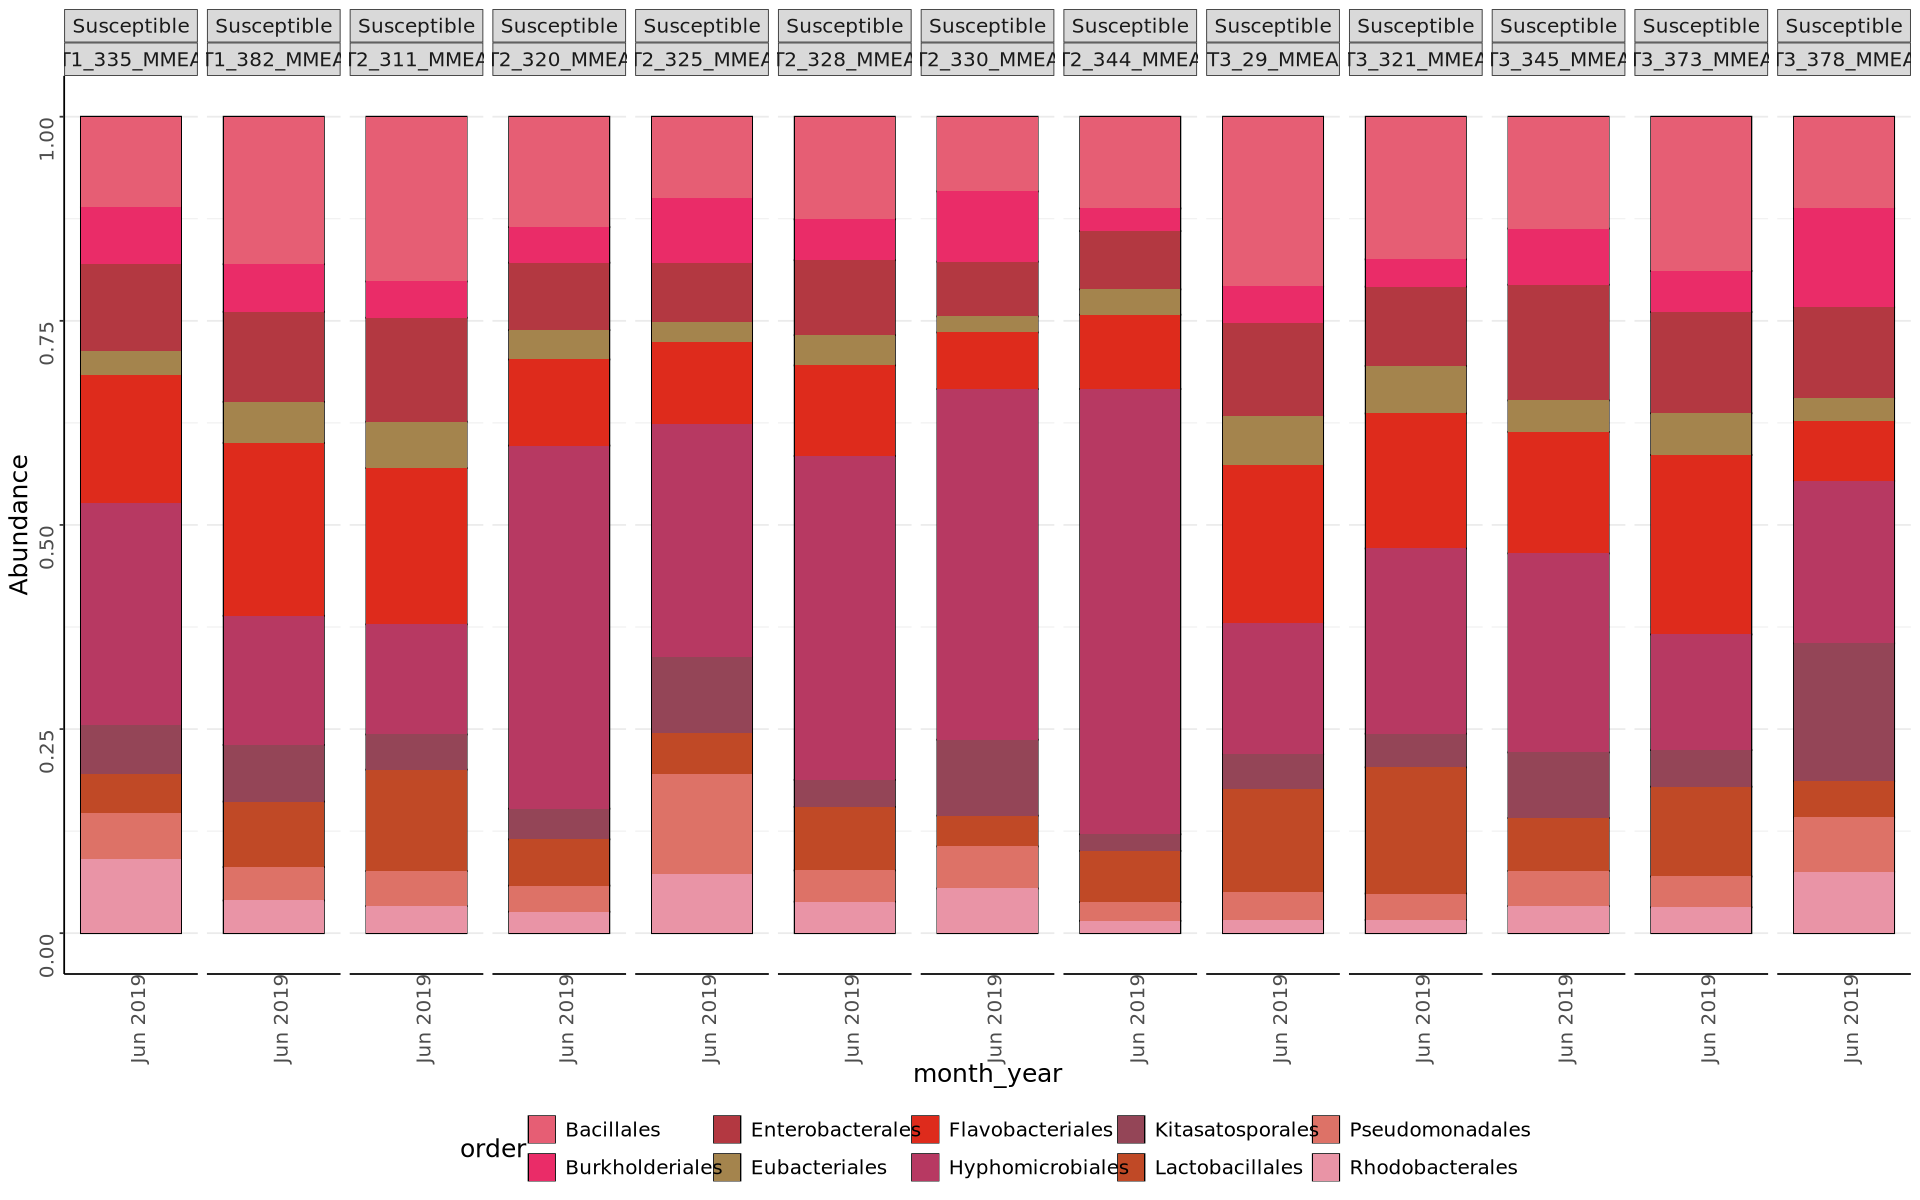

In [106]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_10_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (order)

#### PAST --------------------------------------------------------------------------------

In [107]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [108]:
# looking just at PAST, remove disease margin

subset_PAST<- subset_samples(sctld_raw, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PAST_100 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:100]), subset_PAST)
PAST_100_norm <- transform_sample_counts(PAST_100, function(x) x / sum(x))

PAST_30 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:30]), subset_PAST)
PAST_30_norm <- transform_sample_counts(PAST_30, function(x) x / sum(x))

PAST_10 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:10]), subset_PAST)
PAST_10_norm <- transform_sample_counts(PAST_10, function(x) x / sum(x))

In [109]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [110]:
# "resistant" colonies that don't have 2022 data 
colony %>%
    filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
    select(colony_id, X122022_Condition, X092023_Condition, X012024_Condition, X042024_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

colony_id,X122022_Condition,X092023_Condition,X012024_Condition,X042024_Condition
<chr>,<chr>,<chr>,<chr>,<chr>
T2_47_PAST,Not_Visited,Not_Visited,Not_Visited,Not_Visited
T3_13_PAST,Healthy,Not_Visited,CLB,Healthy


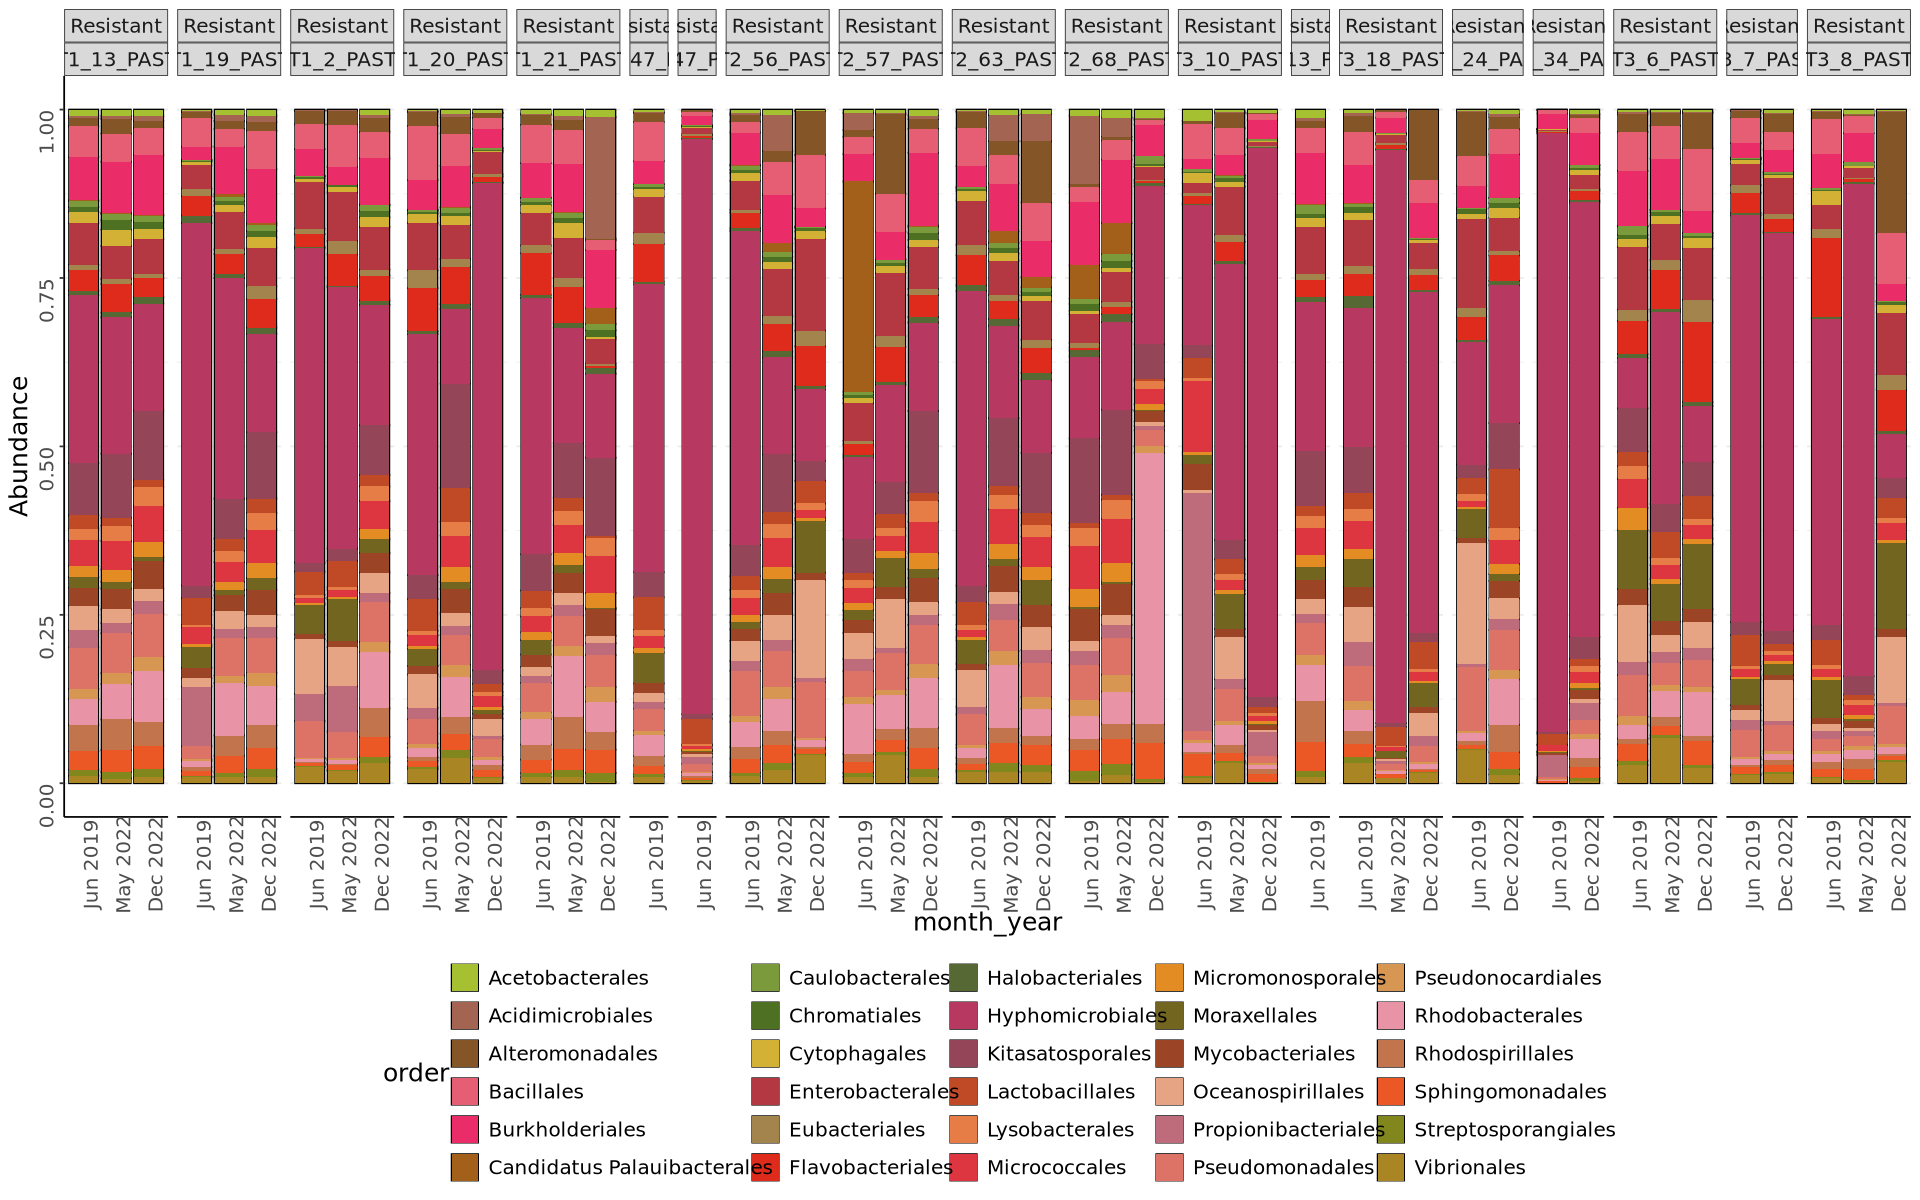

In [111]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_30_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 order - R vs S. individuals over time 

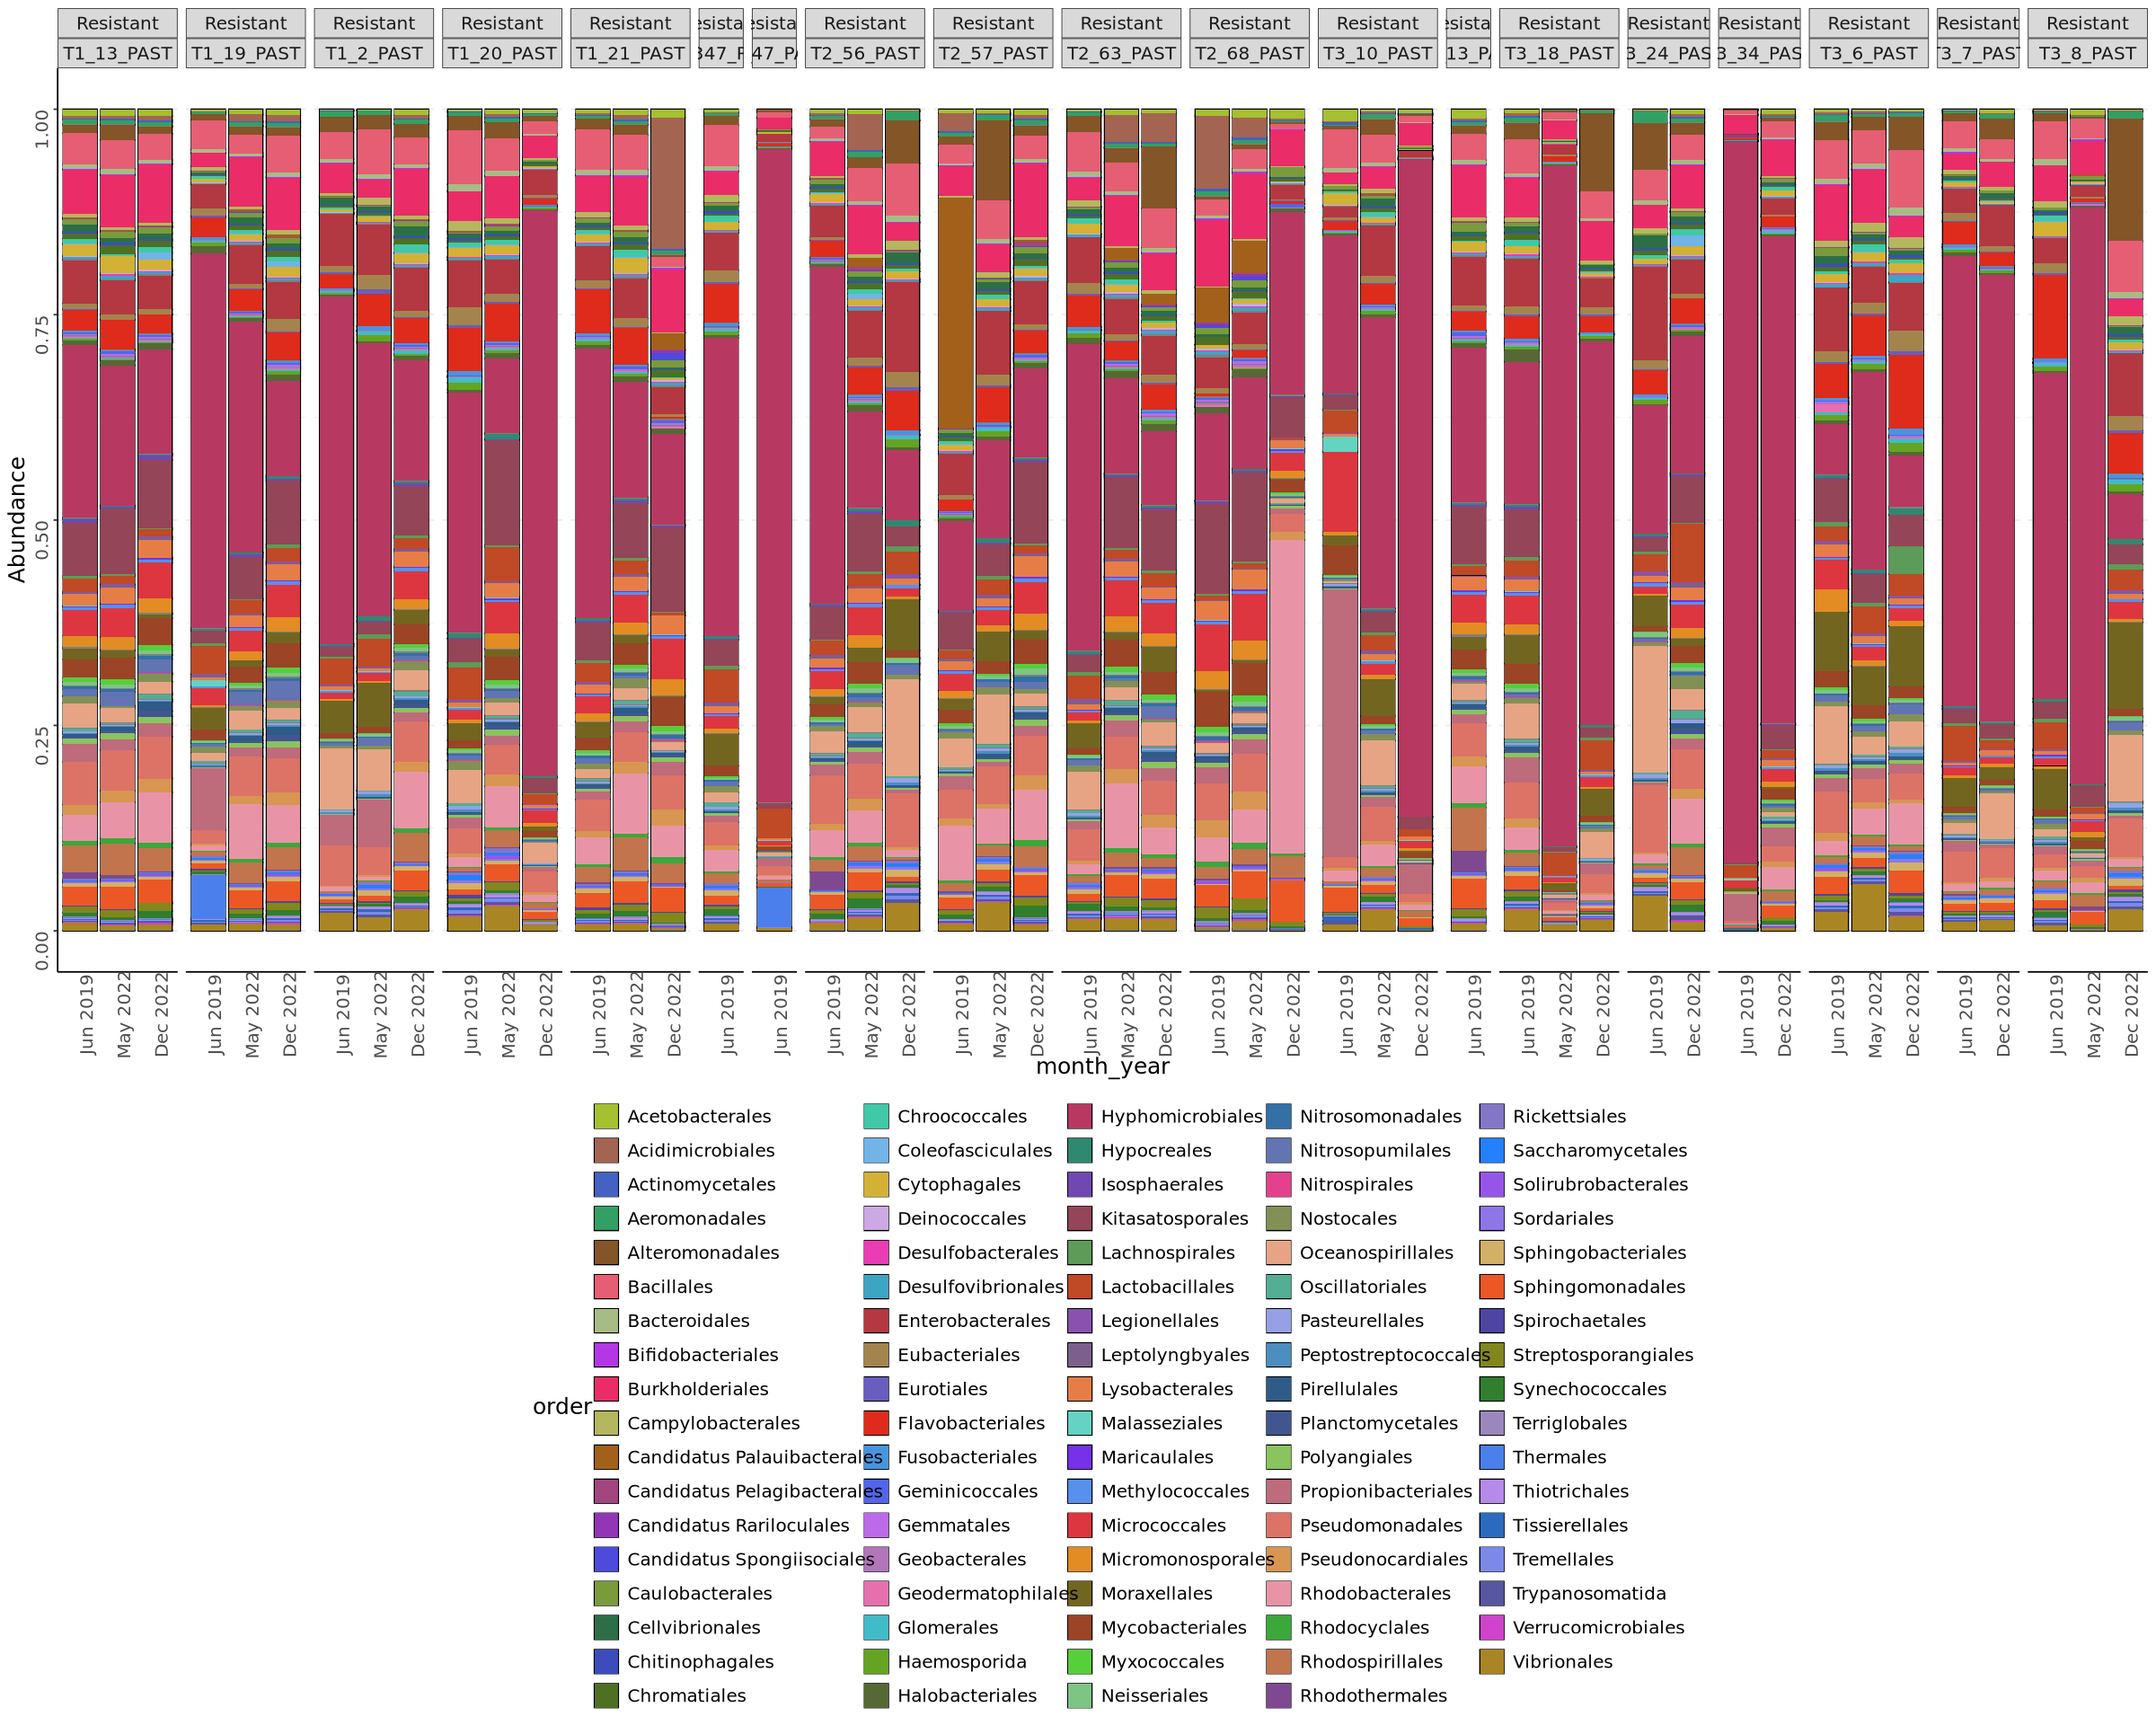

In [112]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (order)

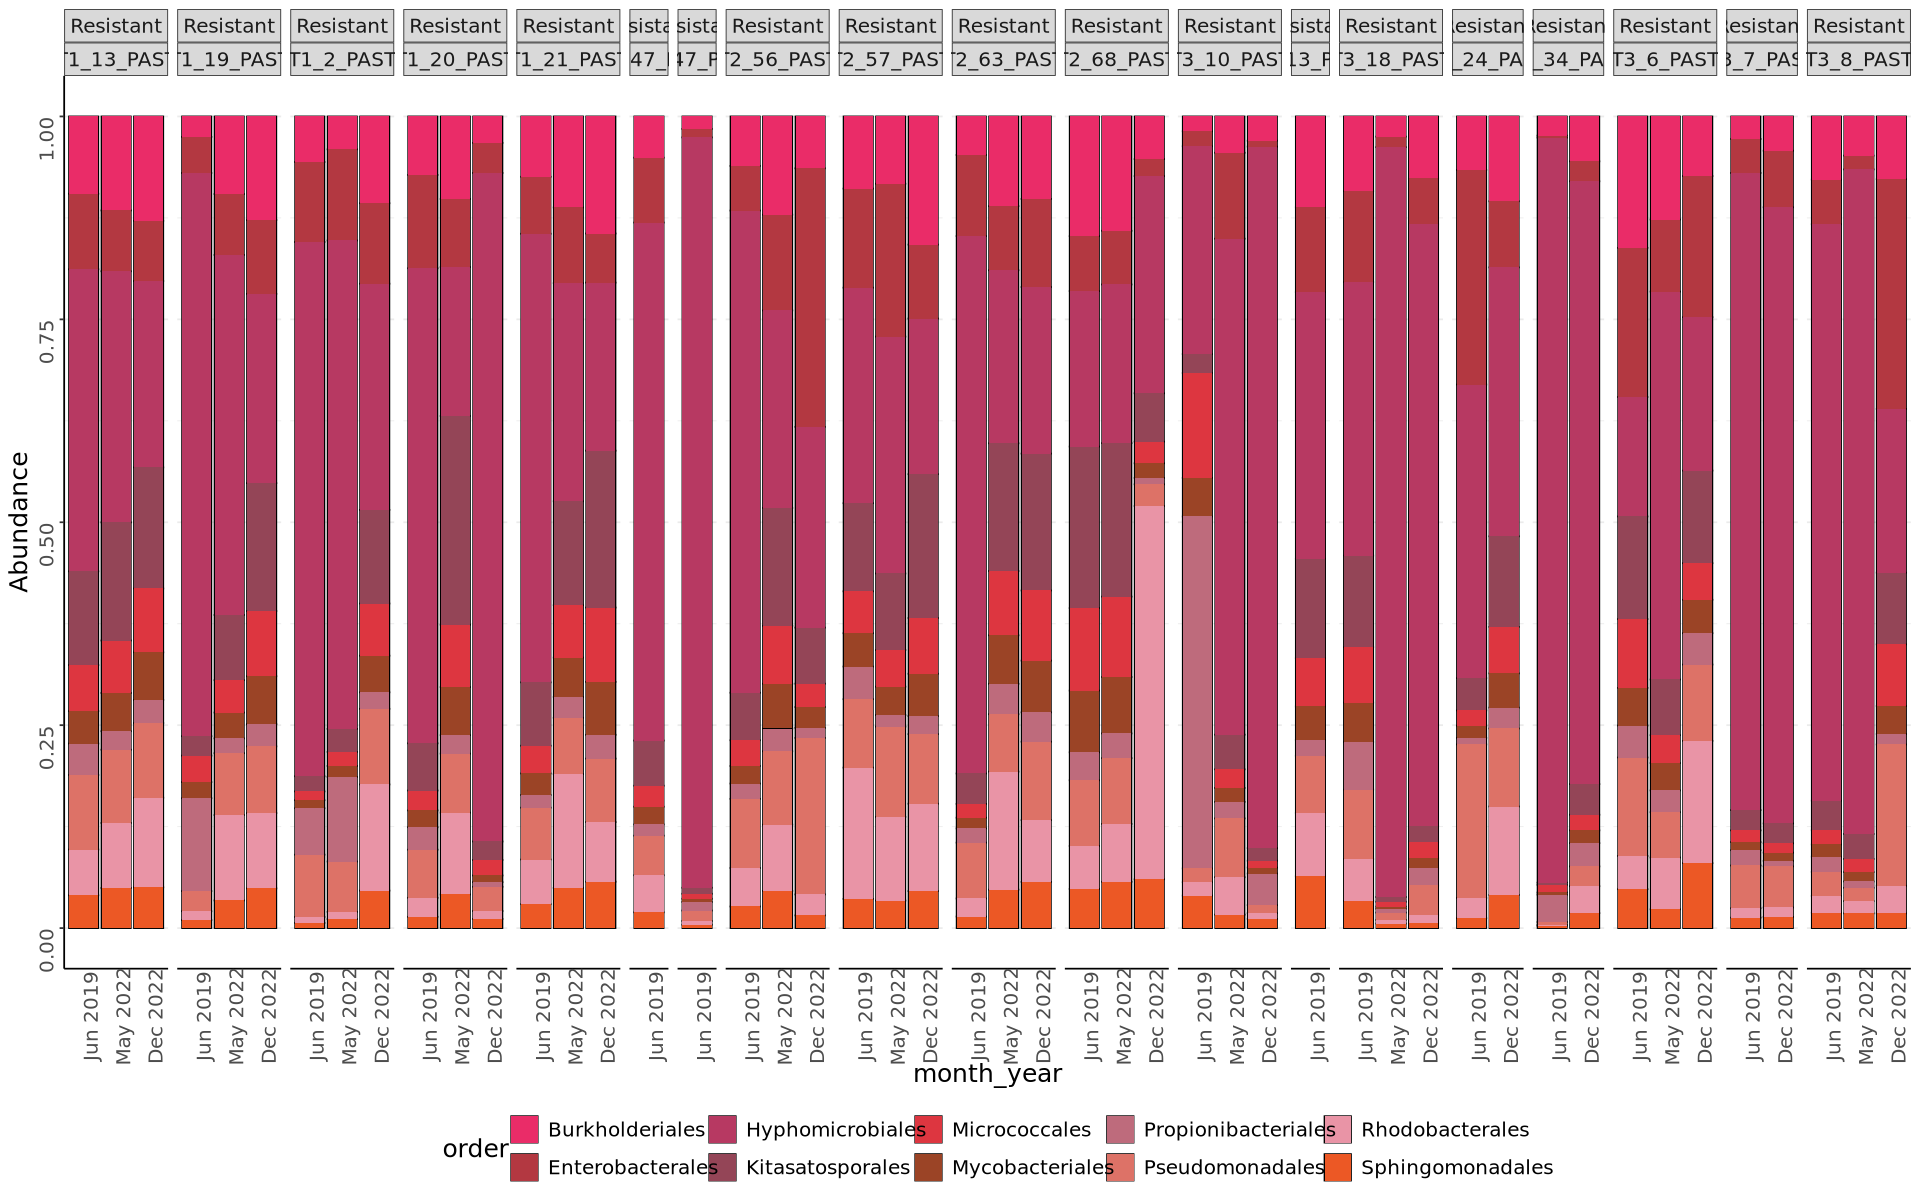

In [113]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_10_norm,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (species)

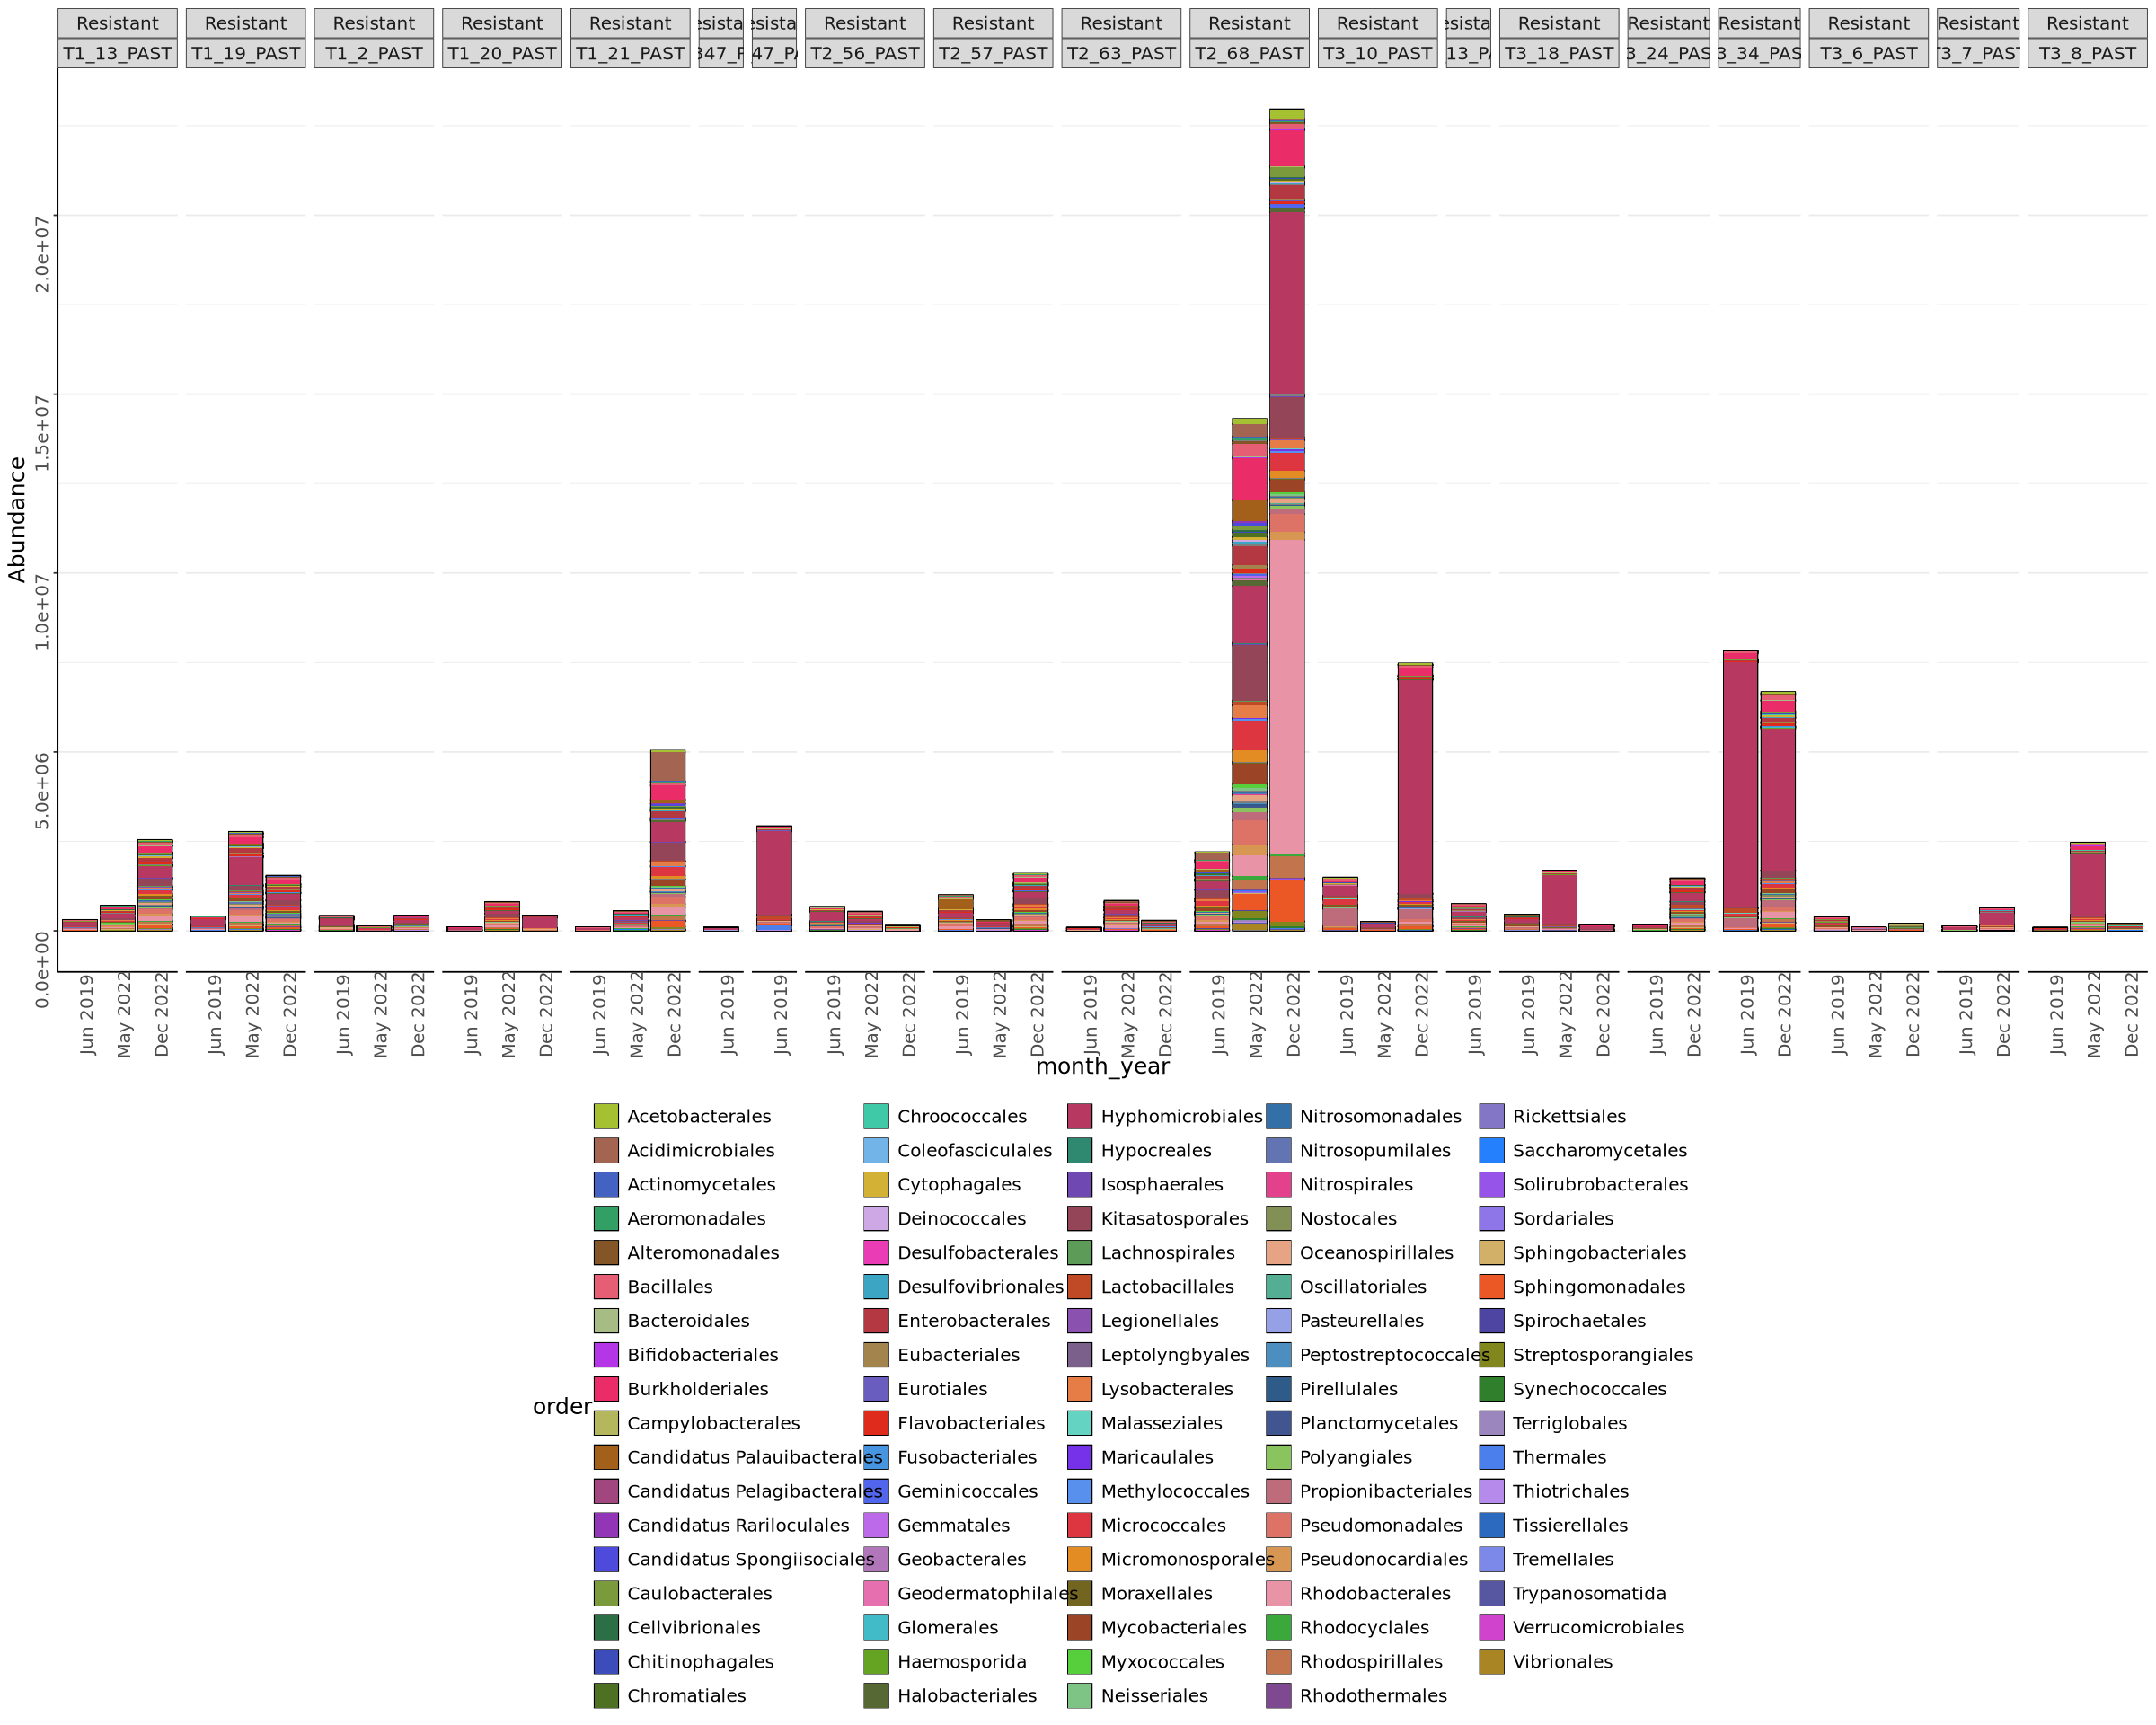

In [114]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (order)

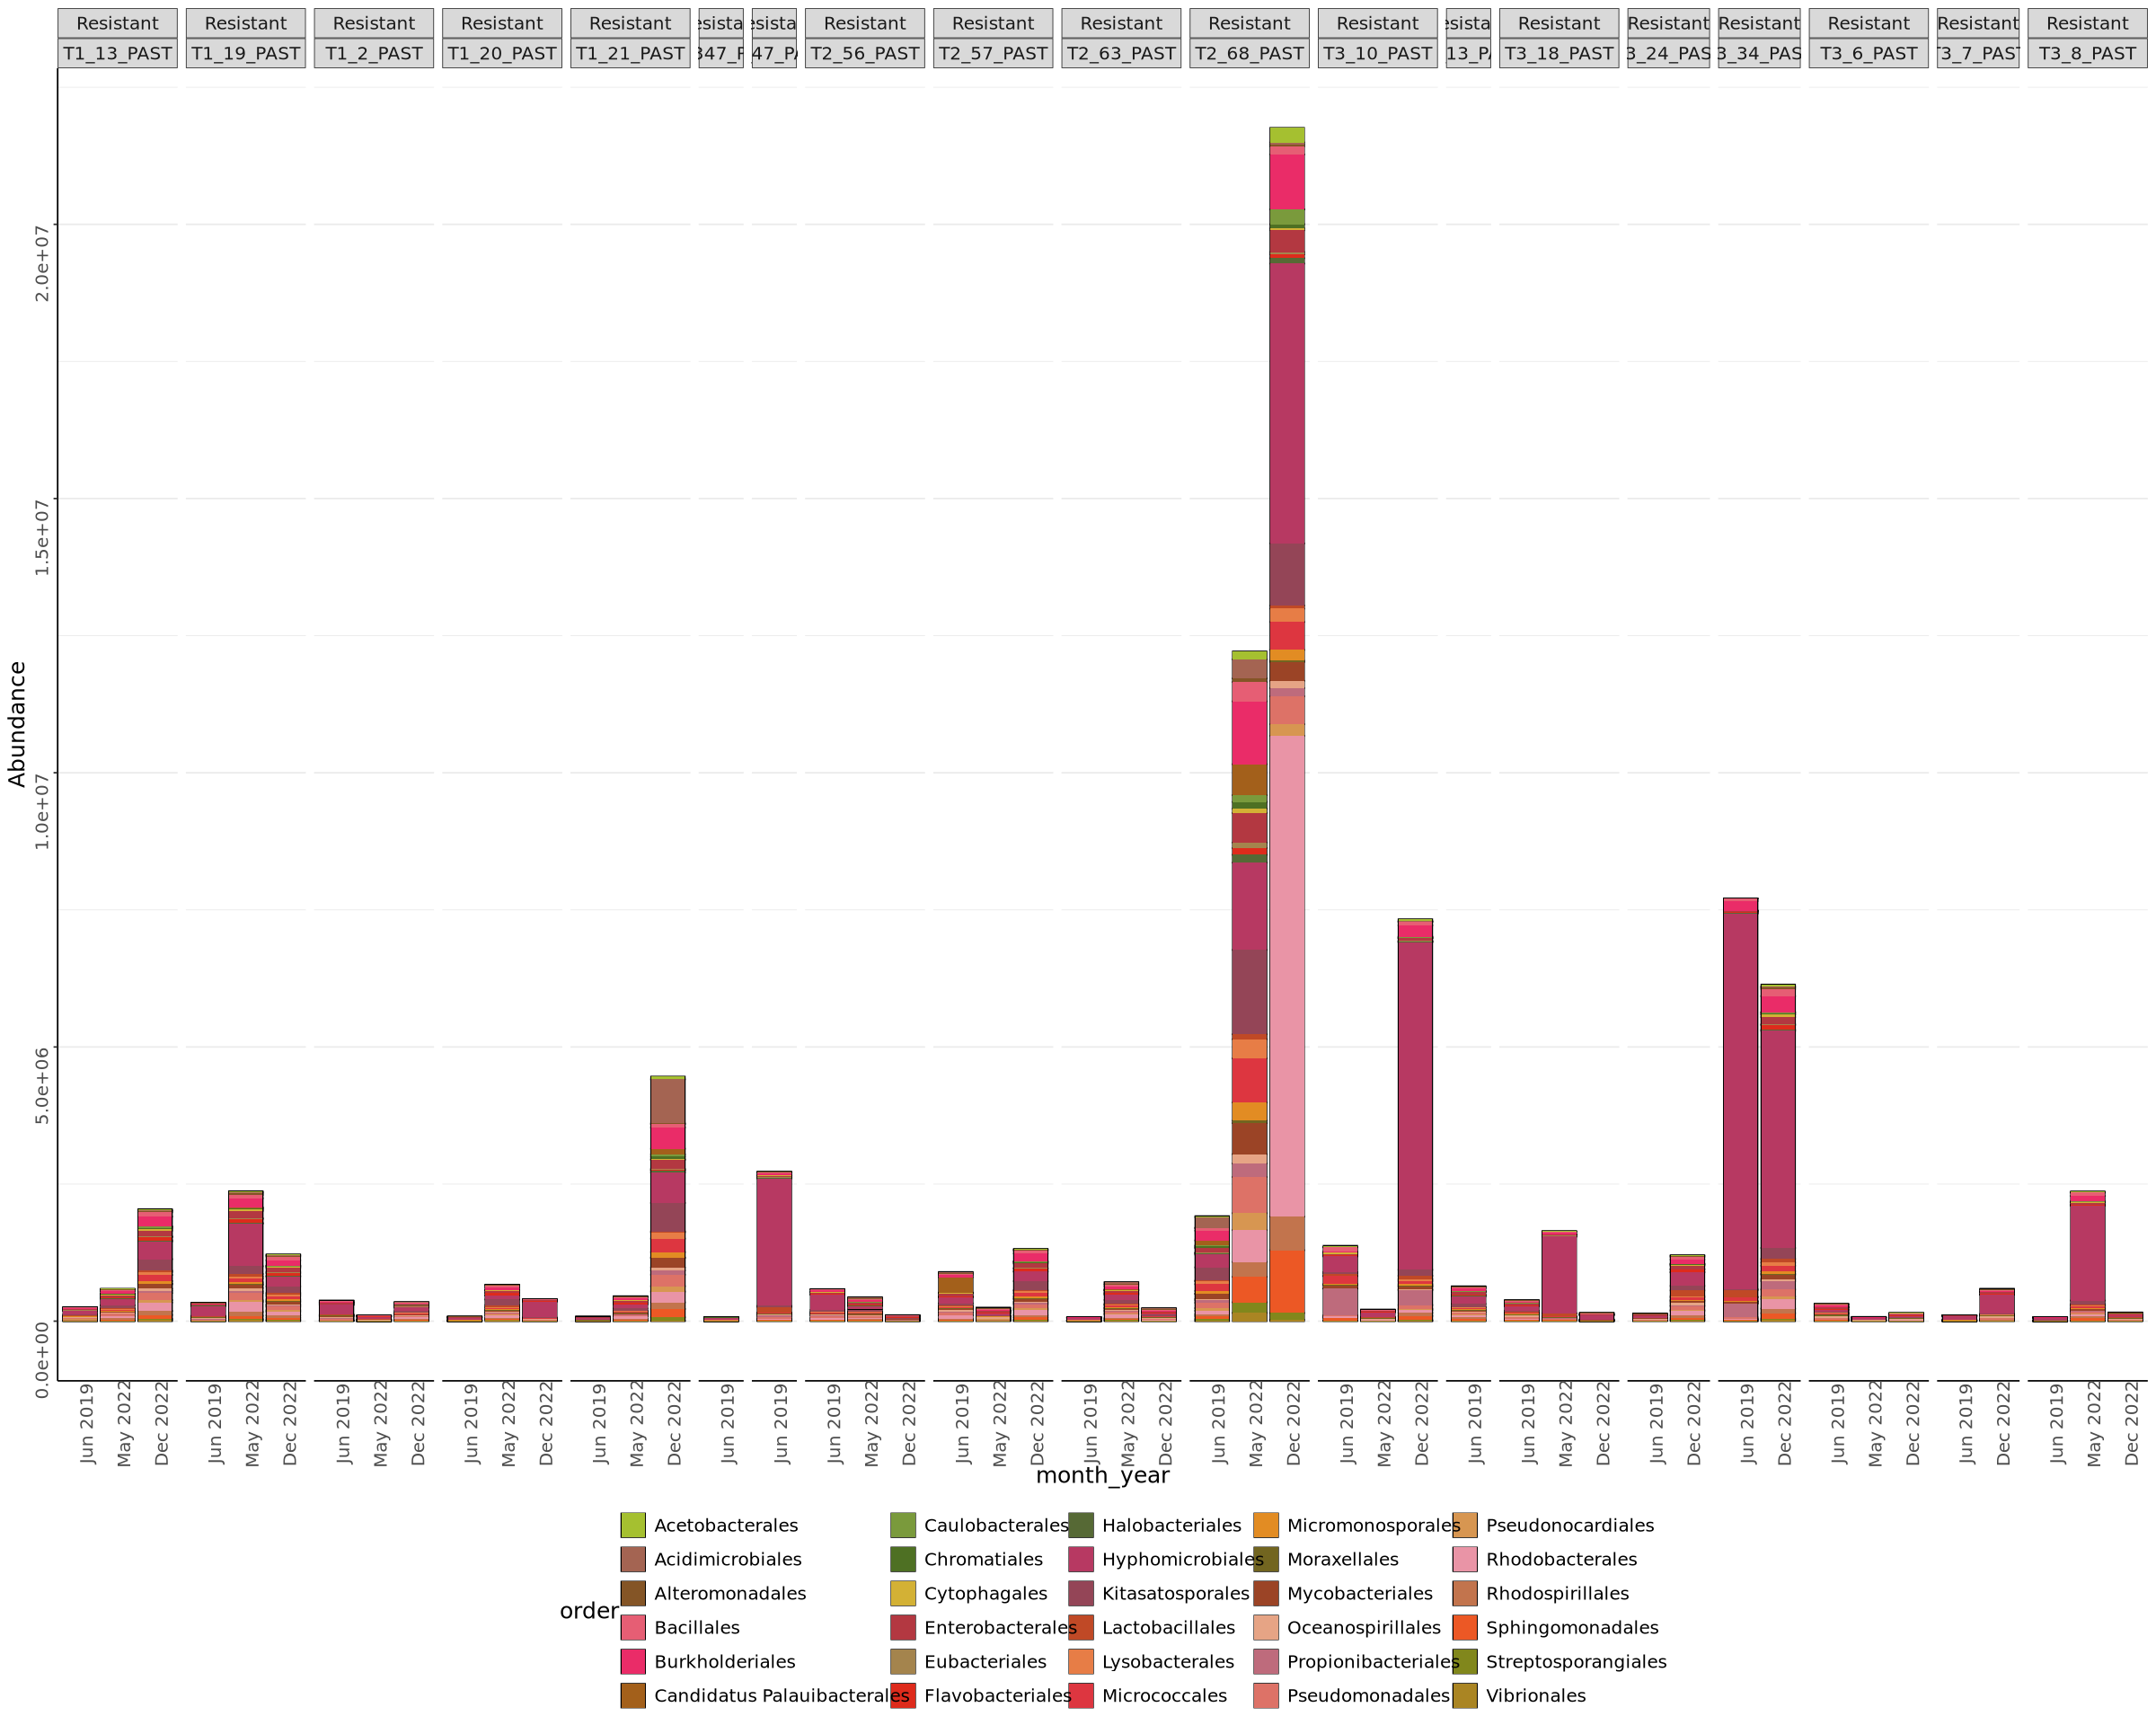

In [115]:
p<-plot_bar(PAST_30,x = "month_year",fill='order')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=order), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (order)